<a href="https://colab.research.google.com/github/balaravi2002/NBA_FVC/blob/main/Max_Savin_NBA_Fair_Value_Calculator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> **Overview of NBA Fair Value Calculator (FVC)**



*   Proportion of salary cap contraints occuppied by new contracts' avg. annual value (AAV) vs. "Production" (before & after signing)



# Sourcing & Pre-Processing Data

## League Salary Cap Info

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = 'https://basketball.realgm.com/nba/info/salary_cap'

# Fetch the page content
response = requests.get(url)
html_content = response.content

# Parse the HTML with BeautifulSoup
soup = BeautifulSoup(html_content, 'html.parser')

# Initialize lists to store the data
seasons = []
salary_caps = []
luxury_taxes = []
first_aprons = []
second_aprons = []

# Select all rows in the table body
rows = soup.find_all('tr')

for row in rows:
    cols = row.find_all('td')
    # Ensure the row contains at least the number of columns we are interested in
    if len(cols) >= 7:
        season = cols[2].text.strip()       # The 3rd <td> element corresponds to 'Season'
        salary_cap = cols[3].text.strip()   # The 4th <td> element corresponds to 'Salary Cap'
        luxury_tax = cols[4].text.strip()   # The 5th <td> element corresponds to 'Luxury Tax'
        first_apron = cols[5].text.strip()  # The 6th <td> element corresponds to '1st Apron'
        second_apron = cols[6].text.strip() # The 7th <td> element corresponds to '2nd Apron'

        # Filter out rows where 'Season' is formatted differently or data is misaligned
        if season and season != '-' and '$' in salary_cap:
            # Append the extracted data to the lists
            seasons.append(season)
            salary_caps.append(salary_cap)
            luxury_taxes.append(luxury_tax)
            first_aprons.append(first_apron)
            second_aprons.append(second_apron)

# Create a DataFrame from the lists
NBA_salary_cap = pd.DataFrame({
    'Season': seasons,
    'Salary Cap': salary_caps,
    'Luxury Tax': luxury_taxes,
    '1st Apron': first_aprons,
    '2nd Apron': second_aprons
})

# Display the DataFrame
NBA_salary_cap

,Season,Salary Cap,Luxury Tax,1st Apron,2nd Apron
0,2034-2035,"$364,650,000","$443,050,000","$461,955,000","$489,965,000"
1,2033-2034,"$331,500,000","$402,773,000","$419,960,000","$445,423,000"
2,2032-2033,"$301,364,000","$366,157,000","$381,781,000","$404,929,000"
3,2031-2032,"$273,967,000","$332,870,000","$347,074,000","$368,118,000"
4,2030-2031,"$249,061,000","$302,609,000","$315,522,000","$334,652,000"
5,2029-2030,"$226,419,000","$275,099,000","$286,838,000","$304,229,000"
6,2028-2029,"$205,835,000","$250,090,000","$260,762,000","$276,572,000"
7,2027-2028,"$187,123,000","$227,354,000","$237,055,000","$251,429,000"
8,2026-2027,"$170,112,000","$206,686,000","$215,505,000","$228,572,000"
9,2025-2026,"$154,647,000","$187,895,000","$195,945,000","$207,824,000"


In [ ]:
# Save DataFrame to a CSV file (for further data cleaning & feature engineering in excel)
NBA_salary_cap.to_csv('NBA_salary_cap.csv', index=False, mode='w')

### Visual

In [ ]:
import plotly.express as px
import requests
from bs4 import BeautifulSoup
import pandas as pd

# Convert necessary columns to numeric (remove $, commas)
NBA_salary_cap['Salary Cap'] = NBA_salary_cap['Salary Cap'].replace('[\$,]', '', regex=True).astype(int)
NBA_salary_cap['Luxury Tax'] = NBA_salary_cap['Luxury Tax'].replace('[\$,]', '', regex=True).replace('N/A', '0').astype(int)
NBA_salary_cap['1st Apron'] = NBA_salary_cap['1st Apron'].replace('[\$,]', '', regex=True).replace('N/A', '0').astype(int)

# Set the order of the DataFrame to have the oldest season first
NBA_salary_cap_increasing = NBA_salary_cap.iloc[::-1]

# Create the line plot
fig = px.line(NBA_salary_cap_increasing, x='Season', y=['Salary Cap', 'Luxury Tax', '1st Apron'],
              title='NBA Salary Cap, Luxury Tax, and 1st Apron Increase Per Season',
              labels={'Season': 'Season', 'value': 'Amount ($)', 'variable': 'Category'})

# Customize layout
fig.update_layout(
    xaxis_title='Season',
    yaxis_title='Amount ($)',
    xaxis_tickangle=-45,
    xaxis=dict(
        tickmode='array',
        tickvals=[NBA_salary_cap_increasing['Season'][i] for i in range(0, len(NBA_salary_cap_increasing), 4)]
    ),
    margin=dict(l=40, r=40, t=40, b=80)
)

fig.show()

## Player Contracts

### Web-Scrapping

In [ ]:
# # Contracts signed in 2020
# import requests
# from bs4 import BeautifulSoup
# import pandas as pd

# url = 'https://www.spotrac.com/nba/contracts/_/year/2020/sort/value'

# # Fetch page content
# response = requests.get(url)
# html_content = response.content

# # Parse HTML with BeautifulSoup
# soup = BeautifulSoup(html_content, 'html.parser')

# # Initialize lists to hold data
# players = []
# positions = []
# ages = []
# starts = []
# ends = []
# years = []
# values = []
# aavs = []

# # Find all rows in the table
# rows = soup.find_all('tr')

# # Iterate over each row to extract data
# for row in rows:
#     cols = row.find_all('td')
#     if len(cols) > 1:  # To ensure we skip any non-relevant rows
#         player = cols[1].text.strip()
#         position = cols[2].text.strip()
#         age = cols[4].text.strip()
#         start = cols[5].text.strip()
#         end = cols[6].text.strip()
#         year_length = cols[7].text.strip()
#         value = cols[8].text.strip()
#         aav = cols[9].text.strip()

#         # Append data to lists
#         players.append(player)
#         positions.append(position)
#         ages.append(age)
#         starts.append(start)
#         ends.append(end)
#         years.append(year_length)
#         values.append(value)
#         aavs.append(aav)

# # Create a DataFrame from the lists
# NBA_contracts_2020 = pd.DataFrame({
#     'Player': players,
#     'POS': positions,
#     'Age at Signing': ages,
#     'Start': starts,
#     'End': ends,
#     'YRS': years,
#     'Value': values,
#     'AAV': aavs
# })

# # Display the DataFrame
# NBA_contracts_2020.head()

In [ ]:
# # Contracts signed in 2021
# import requests
# from bs4 import BeautifulSoup
# import pandas as pd

# url = 'https://www.spotrac.com/nba/contracts/_/year/2021/sort/value'

# # Fetch page content
# response = requests.get(url)
# html_content = response.content

# # Parse HTML with BeautifulSoup
# soup = BeautifulSoup(html_content, 'html.parser')

# # Initialize lists to hold data
# players = []
# positions = []
# ages = []
# starts = []
# ends = []
# years = []
# values = []
# aavs = []

# # Find all rows in the table
# rows = soup.find_all('tr')

# # Iterate over each row to extract data
# for row in rows:
#     cols = row.find_all('td')
#     if len(cols) > 1:  # To ensure we skip any non-relevant rows
#         player = cols[1].text.strip()
#         position = cols[2].text.strip()
#         age = cols[4].text.strip()
#         start = cols[5].text.strip()
#         end = cols[6].text.strip()
#         year_length = cols[7].text.strip()
#         value = cols[8].text.strip()
#         aav = cols[9].text.strip()

#         # Append data to lists
#         players.append(player)
#         positions.append(position)
#         ages.append(age)
#         starts.append(start)
#         ends.append(end)
#         years.append(year_length)
#         values.append(value)
#         aavs.append(aav)

# # Create a DataFrame from the lists
# NBA_contracts_2021 = pd.DataFrame({
#     'Player': players,
#     'POS': positions,
#     'Age at Signing': ages,
#     'Start': starts,
#     'End': ends,
#     'YRS': years,
#     'Value': values,
#     'AAV': aavs
# })

# # Display the DataFrame
# NBA_contracts_2021.tail()

In [ ]:
# # Contracts signed in 2022
# import requests
# from bs4 import BeautifulSoup
# import pandas as pd

# url = 'https://www.spotrac.com/nba/contracts/_/year/2022/sort/value'

# # Fetch page content
# response = requests.get(url)
# html_content = response.content

# # Parse HTML with BeautifulSoup
# soup = BeautifulSoup(html_content, 'html.parser')

# # Initialize lists to hold data
# players = []
# positions = []
# ages = []
# starts = []
# ends = []
# years = []
# values = []
# aavs = []

# # Find all rows in the table
# rows = soup.find_all('tr')

# # Iterate over each row to extract data
# for row in rows:
#     cols = row.find_all('td')
#     if len(cols) > 1:  # To ensure we skip any non-relevant rows
#         player = cols[1].text.strip()
#         position = cols[2].text.strip()
#         age = cols[4].text.strip()
#         start = cols[5].text.strip()
#         end = cols[6].text.strip()
#         year_length = cols[7].text.strip()
#         value = cols[8].text.strip()
#         aav = cols[9].text.strip()

#         # Append data to lists
#         players.append(player)
#         positions.append(position)
#         ages.append(age)
#         starts.append(start)
#         ends.append(end)
#         years.append(year_length)
#         values.append(value)
#         aavs.append(aav)

# # Create a DataFrame from the lists
# NBA_contracts_2022 = pd.DataFrame({
#     'Player': players,
#     'POS': positions,
#     'Age at Signing': ages,
#     'Start': starts,
#     'End': ends,
#     'YRS': years,
#     'Value': values,
#     'AAV': aavs
# })

# # Display the DataFrame
# NBA_contracts_2022.tail()

In [ ]:
# # Contracts signed in 2023
# import requests
# from bs4 import BeautifulSoup
# import pandas as pd

# url = 'https://www.spotrac.com/nba/contracts/_/year/2023/sort/value'

# # Fetch page content
# response = requests.get(url)
# html_content = response.content

# # Parse HTML with BeautifulSoup
# soup = BeautifulSoup(html_content, 'html.parser')

# # Initialize lists to hold data
# players = []
# positions = []
# ages = []
# starts = []
# ends = []
# years = []
# values = []
# aavs = []

# # Find all rows in the table
# rows = soup.find_all('tr')

# # Iterate over each row to extract data
# for row in rows:
#     cols = row.find_all('td')
#     if len(cols) > 1:  # To ensure we skip any non-relevant rows
#         player = cols[1].text.strip()
#         position = cols[2].text.strip()
#         age = cols[4].text.strip()
#         start = cols[5].text.strip()
#         end = cols[6].text.strip()
#         year_length = cols[7].text.strip()
#         value = cols[8].text.strip()
#         aav = cols[9].text.strip()

#         # Append data to lists
#         players.append(player)
#         positions.append(position)
#         ages.append(age)
#         starts.append(start)
#         ends.append(end)
#         years.append(year_length)
#         values.append(value)
#         aavs.append(aav)

# # Create a DataFrame from the lists
# NBA_contracts_2023 = pd.DataFrame({
#     'Player': players,
#     'POS': positions,
#     'Age at Signing': ages,
#     'Start': starts,
#     'End': ends,
#     'YRS': years,
#     'Value': values,
#     'AAV': aavs
# })

# # Display the DataFrame
# NBA_contracts_2023.tail()

In [ ]:
# # Contracts signed in 2024
# import requests
# from bs4 import BeautifulSoup
# import pandas as pd

# url = 'https://www.spotrac.com/nba/contracts/_/year/2024/sort/value'

# # Fetch page content
# response = requests.get(url)
# html_content = response.content

# # Parse HTML with BeautifulSoup
# soup = BeautifulSoup(html_content, 'html.parser')

# # Initialize lists to hold data
# players = []
# positions = []
# ages = []
# starts = []
# ends = []
# years = []
# values = []
# aavs = []

# # Find all rows in the table
# rows = soup.find_all('tr')

# # Iterate over each row to extract data
# for row in rows:
#     cols = row.find_all('td')
#     if len(cols) > 1:  # To ensure we skip any non-relevant rows
#         player = cols[1].text.strip()
#         position = cols[2].text.strip()
#         age = cols[4].text.strip()
#         start = cols[5].text.strip()
#         end = cols[6].text.strip()
#         year_length = cols[7].text.strip()
#         value = cols[8].text.strip()
#         aav = cols[9].text.strip()

#         # Append data to lists
#         players.append(player)
#         positions.append(position)
#         ages.append(age)
#         starts.append(start)
#         ends.append(end)
#         years.append(year_length)
#         values.append(value)
#         aavs.append(aav)

# # Create a DataFrame from the lists
# NBA_contracts_2024 = pd.DataFrame({
#     'Player': players,
#     'POS': positions,
#     'Age at Signing': ages,
#     'Start': starts,
#     'End': ends,
#     'YRS': years,
#     'Value': values,
#     'AAV': aavs
# })

# # Display the DataFrame
# NBA_contracts_2024.tail()

### Importing Spotrac 2014-2024 Signings

In [ ]:
from google.colab import files

uploaded = files.upload()

# Specify file name
NBA_2014_contracts = "NBA 2014 Contracts.csv"

# Read CSV file into Pandas DataFrame
NBA_contracts_2014 = pd.read_csv(NBA_2014_contracts)

# Rename columns ("wtf Spotrac")
NBA_contracts_2014 = NBA_contracts_2014.rename(columns={
    'Team\n                        Signed With': 'Team Signed With',
    'Age\n                        At Signing': 'Age At Signing'
})

# Fix duplicate team names (another "wtf Spotrac")
NBA_contracts_2014['Team Signed With'] = NBA_contracts_2014['Team Signed With'].apply(lambda x: x.split()[0])

NBA_contracts_2014.head()

KeyboardInterrupt: 

In [ ]:
uploaded = files.upload()

# Specify file name
NBA_2015_contracts = "NBA 2015 Contracts.csv"

# Read CSV file into Pandas DataFrame
NBA_contracts_2015 = pd.read_csv(NBA_2015_contracts)

# Rename columns ("wtf Spotrac")
NBA_contracts_2015 = NBA_contracts_2015.rename(columns={
    'Team\n                        Signed With': 'Team Signed With',
    'Age\n                        At Signing': 'Age At Signing'
})

# Fix duplicate team names (another "wtf Spotrac")
NBA_contracts_2015['Team Signed With'] = NBA_contracts_2015['Team Signed With'].apply(lambda x: x.split()[0])

NBA_contracts_2015.head()

In [ ]:
uploaded = files.upload()

# Specify file name
NBA_2016_contracts = "NBA 2016 Contracts.csv"

# Read CSV file into Pandas DataFrame
NBA_contracts_2016 = pd.read_csv(NBA_2016_contracts)

# Rename columns ("wtf Spotrac")
NBA_contracts_2016 = NBA_contracts_2016.rename(columns={
    'Team\n                        Signed With': 'Team Signed With',
    'Age\n                        At Signing': 'Age At Signing'
})

# Fix duplicate team names (another "wtf Spotrac")
NBA_contracts_2016['Team Signed With'] = NBA_contracts_2016['Team Signed With'].apply(lambda x: x.split()[0])

NBA_contracts_2016.head()

In [ ]:
uploaded = files.upload()

# Specify file name
NBA_2017_contracts = "NBA 2017 Contracts.csv"

# Read CSV file into Pandas DataFrame
NBA_contracts_2017 = pd.read_csv(NBA_2017_contracts)

# Rename columns ("wtf Spotrac")
NBA_contracts_2017 = NBA_contracts_2017.rename(columns={
    'Team\n                        Signed With': 'Team Signed With',
    'Age\n                        At Signing': 'Age At Signing'
})

# Fix duplicate team names (another "wtf Spotrac")
NBA_contracts_2017['Team Signed With'] = NBA_contracts_2017['Team Signed With'].apply(lambda x: x.split()[0])

NBA_contracts_2017.head()

In [ ]:
uploaded = files.upload()

# Specify file name
NBA_2018_contracts = "NBA 2018 Contracts.csv"

# Read CSV file into Pandas DataFrame
NBA_contracts_2018 = pd.read_csv(NBA_2018_contracts)

# Rename columns ("wtf Spotrac")
NBA_contracts_2018 = NBA_contracts_2018.rename(columns={
    'Team\n                        Signed With': 'Team Signed With',
    'Age\n                        At Signing': 'Age At Signing'
})

# Fix duplicate team names (another "wtf Spotrac")
NBA_contracts_2018['Team Signed With'] = NBA_contracts_2018['Team Signed With'].apply(lambda x: x.split()[0])

NBA_contracts_2018.head()

In [ ]:
uploaded = files.upload()

# Specify file name
NBA_2019_contracts = "NBA 2019 Contracts.csv"

# Read CSV file into Pandas DataFrame
NBA_contracts_2019 = pd.read_csv(NBA_2019_contracts)

# Rename columns ("wtf Spotrac")
NBA_contracts_2019 = NBA_contracts_2019.rename(columns={
    'Team\n                        Signed With': 'Team Signed With',
    'Age\n                        At Signing': 'Age At Signing'
})

# Fix duplicate team names (another "wtf Spotrac")
NBA_contracts_2019['Team Signed With'] = NBA_contracts_2019['Team Signed With'].apply(lambda x: x.split()[0])

NBA_contracts_2019.head()

In [ ]:
uploaded = files.upload()

# Specify file name
NBA_2020_contracts = "NBA 2020 Contracts.csv"

# Read CSV file into Pandas DataFrame
NBA_contracts_2020 = pd.read_csv(NBA_2020_contracts)

# Rename columns ("wtf Spotrac")
NBA_contracts_2020 = NBA_contracts_2020.rename(columns={
    'Team\n                        Signed With': 'Team Signed With',
    'Age\n                        At Signing': 'Age At Signing'
})

# Fix duplicate team names (another "wtf Spotrac")
NBA_contracts_2020['Team Signed With'] = NBA_contracts_2020['Team Signed With'].apply(lambda x: x.split()[0])

NBA_contracts_2020.head()

In [ ]:
uploaded = files.upload()

# Specify file name
NBA_2021_contracts = "NBA 2021 Contracts.csv"

# Read CSV file into Pandas DataFrame
NBA_contracts_2021 = pd.read_csv(NBA_2021_contracts)

# Rename columns ("wtf Spotrac")
NBA_contracts_2021 = NBA_contracts_2021.rename(columns={
    'Team\n                        Signed With': 'Team Signed With',
    'Age\n                        At Signing': 'Age At Signing'
})

# Fix duplicate team names (another "wtf Spotrac")
NBA_contracts_2021['Team Signed With'] = NBA_contracts_2021['Team Signed With'].apply(lambda x: x.split()[0])

NBA_contracts_2021.head()

In [ ]:
uploaded = files.upload()

# Specify file name
NBA_2022_contracts = "NBA 2022 Contracts.csv"

# Read CSV file into Pandas DataFrame
NBA_contracts_2022 = pd.read_csv(NBA_2022_contracts)

# Rename columns ("wtf Spotrac")
NBA_contracts_2022 = NBA_contracts_2022.rename(columns={
    'Team\n                        Signed With': 'Team Signed With',
    'Age\n                        At Signing': 'Age At Signing'
})

# Fix duplicate team names (another "wtf Spotrac")
NBA_contracts_2022['Team Signed With'] = NBA_contracts_2022['Team Signed With'].apply(lambda x: x.split()[0])

NBA_contracts_2022.head()

In [ ]:
uploaded = files.upload()

# Specify file name
NBA_2023_contracts = "NBA 2023 Contracts.csv"

# Read CSV file into Pandas DataFrame
NBA_contracts_2023 = pd.read_csv(NBA_2023_contracts)

# Rename columns ("wtf Spotrac")
NBA_contracts_2023 = NBA_contracts_2023.rename(columns={
    'Team\n                        Signed With': 'Team Signed With',
    'Age\n                        At Signing': 'Age At Signing'
})

# Fix duplicate team names (another "wtf Spotrac")
NBA_contracts_2023['Team Signed With'] = NBA_contracts_2023['Team Signed With'].apply(lambda x: x.split()[0])

NBA_contracts_2023.head()

In [ ]:
uploaded = files.upload()

# Specify file name
NBA_2024_contracts = "NBA 2024 Contracts.csv"

# Read CSV file into Pandas DataFrame
NBA_contracts_2024 = pd.read_csv(NBA_2024_contracts)

# Rename columns ("wtf Spotrac")
NBA_contracts_2024 = NBA_contracts_2024.rename(columns={
    'Team\n                        Signed With': 'Team Signed With',
    'Age\n                        At Signing': 'Age At Signing'
})

# Fix duplicate team names (another "wtf Spotrac")
NBA_contracts_2024['Team Signed With'] = NBA_contracts_2024['Team Signed With'].apply(lambda x: x.split()[0])

NBA_contracts_2024.head()

### Consolidated DataFrame

In [ ]:
# Contracts signed 2014-2024

NBA_contracts_2014_to_2024 = pd.concat([
    NBA_contracts_2014,
    NBA_contracts_2015,
    NBA_contracts_2016,
    NBA_contracts_2017,
    NBA_contracts_2018,
    NBA_contracts_2019,
    NBA_contracts_2020,
    NBA_contracts_2021,
    NBA_contracts_2022,
    NBA_contracts_2023,
    NBA_contracts_2024
], ignore_index=True)

# Convert the 'Value' & 'AAV' columns to numeric
NBA_contracts_2014_to_2024['Value'] = NBA_contracts_2014_to_2024['Value'].replace('[\$,]', '', regex=True).astype(float)
NBA_contracts_2014_to_2024['AAV'] = NBA_contracts_2014_to_2024['AAV'].replace('[\$,]', '', regex=True).astype(float)

# Convert the 'Start' column to int
NBA_contracts_2014_to_2024['Start'] = NBA_contracts_2014_to_2024['Start'].astype(int)

# Display the combined DataFrame
NBA_contracts_2014_to_2024

In [ ]:
# Contract types to exclude
exclude_types = ['Camp Invite', 'Rookie', 'amnesty', 'ten-day', 'two-way', 'exhibit-10', 'exhibit-9', 'rest-of-season']

# Filter NBA_contracts_2014_to_2024
NBA_contracts_2014_to_2024 = NBA_contracts_2014_to_2024[~NBA_contracts_2014_to_2024['Type'].isin(exclude_types)]

NBA_contracts_2014_to_2024.info()

In [ ]:
# Display all unique values in the 'Type' column after filtering
remaining_types = NBA_contracts_2014_to_2024['Type'].unique()
remaining_types

## EPM Data

In [ ]:
# Import CSV's (Max) & match ratings with player contracts (EPM and/or EW before & after signing)... two seasons before, separate years & average, and one after

uploaded = files.upload()

# Specify file name
EPM_2014_data = "2014 EPM data.csv"

# Read CSV file into Pandas DataFrame
EPM_2014 = pd.read_csv(EPM_2014_data)

EPM_2014.head()

In [ ]:
uploaded = files.upload()

# Specify file name
EPM_2015_data = "2015 EPM data.csv"

# Read CSV file into Pandas DataFrame
EPM_2015 = pd.read_csv(EPM_2015_data)

EPM_2015.head()

In [ ]:
uploaded = files.upload()

# Specify file name
EPM_2016_data = "2016 EPM data.csv"

# Read CSV file into Pandas DataFrame
EPM_2016 = pd.read_csv(EPM_2016_data)

EPM_2016.head()

In [ ]:
uploaded = files.upload()

# Specify file name
EPM_2017_data = "2017 EPM data.csv"

# Read CSV file into Pandas DataFrame
EPM_2017 = pd.read_csv(EPM_2017_data)

EPM_2017.head()

In [ ]:
uploaded = files.upload()

# Specify file name
EPM_2018_data = "2018 EPM data.csv"

# Read CSV file into Pandas DataFrame
EPM_2018 = pd.read_csv(EPM_2018_data)

EPM_2018.head()

In [ ]:
uploaded = files.upload()

# Specify file name
EPM_2019_data = "2019 EPM data.csv"

# Read CSV file into Pandas DataFrame
EPM_2019 = pd.read_csv(EPM_2019_data)

EPM_2019.head()

In [ ]:
uploaded = files.upload()

# Specify file name
EPM_2020_data = "2020 EPM data.csv"

# Read CSV file into Pandas DataFrame
EPM_2020 = pd.read_csv(EPM_2020_data)

EPM_2020.head()

In [ ]:
uploaded = files.upload()

# Specify file name
EPM_2021_data = "2021 EPM data.csv"

# Read CSV file into Pandas DataFrame
EPM_2021 = pd.read_csv(EPM_2021_data)

EPM_2021.head()

In [ ]:
uploaded = files.upload()

# Specify file name
EPM_2022_data = "2022 EPM data.csv"

# Read CSV file into Pandas DataFrame
EPM_2022 = pd.read_csv(EPM_2022_data)

EPM_2022.head()

In [ ]:
uploaded = files.upload()

# Specify file name
EPM_2023_data = "2023 EPM data.csv"

# Read CSV file into Pandas DataFrame
EPM_2023 = pd.read_csv(EPM_2023_data)

EPM_2023.head()

In [ ]:
uploaded = files.upload()

# Specify file name
EPM_2024_data = "2024 EPM data.csv"

# Read CSV file into Pandas DataFrame
EPM_2024 = pd.read_csv(EPM_2024_data)

EPM_2024.head()

## Aggregate Tables into Comprehensive DataFrame

In [ ]:
# League Salary Cap Data Pre-Processing

# Convert monetary columns to numeric (remove $, commas)
NBA_salary_cap['Salary Cap'] = pd.to_numeric(NBA_salary_cap['Salary Cap'].replace('[\$,]', '', regex=True), errors='coerce')
NBA_salary_cap['Luxury Tax'] = pd.to_numeric(NBA_salary_cap['Luxury Tax'].replace('[\$,]', '', regex=True), errors='coerce')
NBA_salary_cap['1st Apron'] = pd.to_numeric(NBA_salary_cap['1st Apron'].replace('[\$,]', '', regex=True), errors='coerce')
NBA_salary_cap['2nd Apron'] = pd.to_numeric(NBA_salary_cap['2nd Apron'].replace('[\$,]', '', regex=True), errors='coerce')

# Simplify 'Season' column by keeping only the first year (consistent with NBA_contracts data)
NBA_salary_cap['Season'] = NBA_salary_cap['Season'].str.split('-').str[0].astype(int)

# Display updated DataFrame
NBA_salary_cap.tail()

In [ ]:
# Join Player Contracts Data with League Salary Cap Data


# OLD WAY FOR JUST SALARY CAP DATA IN YEAR OF CONTRACT START
# NBA_FVC = NBA_contracts_2014_to_2024.merge(
#     NBA_salary_cap,
#     left_on='Start',   # Use the 'Start' column in NBA_contracts_2014_to_2024
#     right_on='Season', # Use the 'Season' column in NBA_salary_cap
#     how='left'         # Perform a left join to keep all records from NBA_contracts_2014_to_2024
# )

# FUNCTION TO CALCULATE AVERAGE SALARY CAP DATA ACROSS ALL YEARS OF A PLAYER'S CONTRACT
def calculate_contract_average(row, salary_cap_df):
    start_year = row['Start']
    end_year = row['End']

    # Filter the salary cap data for the contract duration
    relevant_years = salary_cap_df[(salary_cap_df['Season'] >= start_year) & (salary_cap_df['Season'] <= end_year)]

    # Calculate the averages, considering NaNs
    avg_salary_cap = relevant_years['Salary Cap'].mean()
    avg_luxury_tax = relevant_years['Luxury Tax'].mean()
    avg_first_apron = relevant_years['1st Apron'].mean()

    # Calculate the average for '2nd Apron' only if there are valid (non-NaN) entries
    if relevant_years['2nd Apron'].notna().sum() > 0:
        avg_second_apron = relevant_years['2nd Apron'].mean()
    else:
        avg_second_apron = float('nan')  # Keep it as NaN if all values are NaN

    return pd.Series({
        'Contract Period': f'{start_year}-{end_year}',
        'Avg Salary Cap': avg_salary_cap,
        'Avg Luxury Tax': avg_luxury_tax,
        'Avg 1st Apron': avg_first_apron,
        'Avg 2nd Apron': avg_second_apron
    })

# Apply the function to each row
averages = NBA_contracts_2014_to_2024.apply(calculate_contract_average, axis=1, salary_cap_df=NBA_salary_cap)

# Merge the averages back to the contracts DataFrame
NBA_FVC = pd.concat([NBA_contracts_2014_to_2024, averages], axis=1)

NBA_FVC.head()

In [ ]:
# Address Naming Inconsistencies Across Spotrac + Dunks & Threes
name_corrections = {
    'A.J. Griffin': 'AJ Griffin',
    'Cameron Thomas': 'Cam Thomas',
    "Nah'Shon Hyland": 'Bones Hyland',
    'R.J. Barrett': 'RJ Barrett',
    'RJ Hampton': 'R.J. Hampton',
    'Herb Jones': 'Herbert Jones',
    'PJ Washington': 'P.J. Washington',
    'Bruce Brown Jr.': 'Bruce Brown',
    'Dennis Schröder': 'Dennis Schroder',
    'Vincent Williams Jr.': 'Vince Williams Jr.',
    'Nicolas Claxton': 'Nic Claxton',
    'C.J. McCollum': 'CJ McCollum',
    'Sviatoslav Mykhailiuk': 'Svi Mykhailiuk',
    'C.J. Miles': 'CJ Miles',
    'Jose Barea': 'J.J. Barea',
    'J.J. Redick': 'JJ Redick',
    'J.R. Smith': 'JR Smith',
    'Ishmael Smith': 'Ish Smith',
    'Ishmail Wainright': 'Ish Wainright',
    'Enes Freedom': 'Enes Kanter',
    'Louis Williams': 'Lou Williams',
    'Louis Amundson': 'Lou Amundson',
    'B.J. Johnson': 'BJ Johnson',
    'P.J. Dozier': 'PJ Dozier',
    'K.J. McDaniels': 'KJ McDaniels',
    'DJ Wilson': 'D.J. Wilson',
    "Jae’Sean Tate": "Jae'Sean Tate",
    'Mohamed Bamba': 'Mo Bamba',
    'Kevin Knox': 'Kevin Knox II',
    'G.G. Jackson': 'GG Jackson II',
    'Harry Giles': 'Harry Giles III',
    'Nene Hilario': 'Nene'
}

# Apply corrections to 'Player' column in NBA_FVC
NBA_FVC['Player'] = NBA_FVC['Player'].replace(name_corrections)

In [ ]:
# Join Financial Data with Player Production Data

import numpy as np

def fill_epm_ew_data(row, epm_dataframes):
    start_year = row['Start']
    end_year = row['End']
    name = row['Player']

    # Ensure start_year and end_year are integers and not NaN
    if pd.isna(start_year) or pd.isna(end_year):
        return row  # Return the row unchanged if start_year or end_year is NaN

    start_year = int(start_year)
    end_year = int(end_year)

    # Define the columns to be filled for before signing
    columns_years_before = {
        'EPM_2Y_Before': start_year - 1,  # Two years before = 1 season before start year
        'EPM_1Y_Before': start_year,      # One year before = start year
        'EW_2Y_Before': start_year - 1,
        'EW_1Y_Before': start_year
    }

    # Fill the columns before signing
    for column, year in columns_years_before.items():
        epm_year = f'EPM_{year}'
        if epm_year in epm_dataframes:
            epm_df = epm_dataframes[epm_year]
            player_data = epm_df[epm_df['name'] == name]

            if not player_data.empty:
                if 'EPM' in column:
                    row[column] = player_data['epm'].values[0]
                elif 'EW' in column:
                    row[column] = player_data['ewins'].values[0]
            else:
                row[column] = np.nan
        else:
            row[column] = np.nan

    # Fill the columns after signing based on the length of the contract
    for year_offset in range(1, end_year - start_year + 2):
        epm_year = f'EPM_{start_year + year_offset}'
        if epm_year in epm_dataframes:
            epm_df = epm_dataframes[epm_year]
            player_data = epm_df[epm_df['name'] == name]
            epm_column = f'EPM_{year_offset}Y_After'
            ew_column = f'EW_{year_offset}Y_After'

            if not player_data.empty:
                row[epm_column] = player_data['epm'].values[0]
                row[ew_column] = player_data['ewins'].values[0]
            else:
                row[epm_column] = np.nan
                row[ew_column] = np.nan
        else:
            row[f'EPM_{year_offset}Y_After'] = np.nan
            row[f'EW_{year_offset}Y_After'] = np.nan

    return row

# Store EPM dataframes in single dictionary
epm_dataframes = {
    'EPM_2014': EPM_2014,
    'EPM_2015': EPM_2015,
    'EPM_2016': EPM_2016,
    'EPM_2017': EPM_2017,
    'EPM_2018': EPM_2018,
    'EPM_2019': EPM_2019,
    'EPM_2020': EPM_2020,
    'EPM_2021': EPM_2021,
    'EPM_2022': EPM_2022,
    'EPM_2023': EPM_2023,
    'EPM_2024': EPM_2024
}

# Apply function to each row in NBA_FVC
NBA_FVC = NBA_FVC.apply(fill_epm_ew_data, axis=1, epm_dataframes=epm_dataframes)
NBA_FVC.head()

In [ ]:
def fill_additional_stats_before(row, epm_dataframes):
    start_year = row['Start']
    name = row['Player']

    # Ensure start_year is an integer and not NaN
    if pd.isna(start_year):
        return row  # Return the row unchanged if start_year is NaN

    start_year = int(start_year)

    # Define the columns to be filled for the stats (gp, usg, mpg) for two years before signing
    stats_columns_before = {
        'GP_2Y_Before': start_year - 1,
        'USG_2Y_Before': start_year - 1,
        'MPG_2Y_Before': start_year - 1,
        'GP_1Y_Before': start_year,
        'USG_1Y_Before': start_year,
        'MPG_1Y_Before': start_year
    }

    # Fill the columns with data from two years before signing
    for column, year in stats_columns_before.items():
        epm_year = f'EPM_{year}'
        if epm_year in epm_dataframes:
            epm_df = epm_dataframes[epm_year]
            player_data = epm_df[epm_df['name'] == name]

            if not player_data.empty:
                if 'GP' in column:
                    row[column] = player_data['gp'].values[0]
                elif 'USG' in column:
                    row[column] = player_data['usg'].values[0]
                elif 'MPG' in column:
                    row[column] = player_data['mpg'].values[0]
            else:
                row[column] = np.nan
        else:
            row[column] = np.nan

    return row

# Apply function to each row in NBA_FVC
NBA_FVC = NBA_FVC.apply(fill_additional_stats_before, axis=1, epm_dataframes=epm_dataframes)

# Display the relevant columns to check the changes
NBA_FVC[['Player', 'GP_2Y_Before', 'USG_2Y_Before', 'MPG_2Y_Before', 'GP_1Y_Before', 'USG_1Y_Before', 'MPG_1Y_Before']].head()

In [ ]:
# Define desired column order
desired_order = [
    'Player', 'Pos', 'Team Signed With', 'Age At Signing', 'Start', 'End', 'Yrs', 'Value', 'AAV',
    'Type', 'Signed Date', 'Contract Period', 'Avg Salary Cap', 'Avg Luxury Tax',
    'Avg 1st Apron', 'Avg 2nd Apron', 'GP_2Y_Before', 'GP_1Y_Before', 'MPG_2Y_Before', 'MPG_1Y_Before',
    'USG_2Y_Before', 'USG_1Y_Before', 'EPM_2Y_Before', 'EPM_1Y_Before',
    'EPM_1Y_After', 'EPM_2Y_After', 'EPM_3Y_After', 'EPM_4Y_After', 'EPM_5Y_After', 'EW_2Y_Before',
    'EW_1Y_Before', 'EW_1Y_After', 'EW_2Y_After', 'EW_3Y_After', 'EW_4Y_After', 'EW_5Y_After'
]

# Reorder columns
NBA_FVC = NBA_FVC[desired_order]

NBA_FVC.head()

## Export DataFrame to CSV

In [ ]:
# Save DataFrame to a CSV file (for further data cleaning & feature engineering in excel)
NBA_FVC.to_csv('NBA_FVC_New_Features.csv', index=False, mode='w')

## Min & Max Contract Indicators

### Maximum Contracts 2023-2031



In [ ]:
#Minimum Contract
#Maximum Contract
#Indicators
#Look into Darko --> high tier draft prospects

import requests
import pandas as pd
from bs4 import BeautifulSoup

url = "https://www.spotrac.com/nba/cba/maximum"

response = requests.get(url)


html_content = response.content

soup = BeautifulSoup(html_content, 'html.parser')

tables = soup.find_all('table', {'id': 'table'})

table2023_2030 = tables[0]

#2023-2030 CBA rules
percent_cap = []
year2023_24 = []
year2024_25 = []
year2025_26 = []
year2026_27 = []
year2027_28 = []
year2028_29 = []
year2029_30 = []
year2030_31 = []

#print("Table found:\n", table.prettify())

rows = table2023_2030.find_all('tr')

for row in rows[1:]:
    cols = row.find_all('td')
    if len(cols) == 9:
        percentofcap = cols[0].text.strip()
        year202324 = cols[1].text.strip()
        year202425 = cols[2].text.strip()
        year202526 = cols[3].text.strip()
        year202627 = cols[4].text.strip()
        year202728 = cols[5].text.strip()
        year202829 = cols[6].text.strip()
        year202930 = cols[7].text.strip()
        year203031 = cols[8].text.strip()

        percent_cap.append(percentofcap)
        year2023_24.append(year202324)
        year2024_25.append(year202425)
        year2025_26.append(year202526)
        year2026_27.append(year202627)
        year2027_28.append(year202728)
        year2028_29.append(year202829)
        year2029_30.append(year202930)
        year2030_31.append(year203031)

Maximum_contracts2023_2031 = pd.DataFrame({
            'Percent of Cap Space': percent_cap,
            '2023-24': year2023_24,
            '2024-25': year2024_25,
            '2025-26': year2025_26,
            '2026-27': year2026_27,
            '2027-28': year2027_28,
            '2028-29': year2028_29,
            '2029-30': year2029_30,
            '2030-31': year2030_31
        })

Maximum_contracts2023_2031

### Maximum Contracts 2017 - 2022

In [ ]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot
import seaborn as sns


url = "https://www.spotrac.com/nba/cba/maximum"

response = requests.get(url)


html_content = response.content

soup = BeautifulSoup(html_content, 'html.parser')

tables = soup.find_all('table', {'id': 'table'})

table2017_2022 = tables[1]

#2017-2022 CBA rules
percent_cap = []
year2017_18 = []
year2018_19 = []
year2019_20 = []
year2020_21 = []
year2021_22 = []
year2022_23 = []


#print("Table found:\n", table.prettify())

rows = table2017_2022.find_all('tr')

for row in rows[1:]:
    cols = row.find_all('td')
    if len(cols) == 7:
        percentofcap = cols[0].text.strip()
        year201718 = cols[1].text.strip()
        year201819 = cols[2].text.strip()
        year201920 = cols[3].text.strip()
        year202021 = cols[4].text.strip()
        year202122 = cols[5].text.strip()
        year202223 = cols[6].text.strip()

        percent_cap.append(percentofcap)
        year2017_18.append(year201718)
        year2018_19.append(year201819)
        year2019_20.append(year201920)
        year2020_21.append(year202021)
        year2021_22.append(year202122)
        year2022_23.append(year202223)

Maximum_contracts2017_2022 = pd.DataFrame({
            'Percent of Cap Space': percent_cap,
            '2017-18': year2017_18,
            '2018-19': year2018_19,
            '2019-20': year2019_20,
            '2020-21': year2020_21,
            '2021-22': year2021_22,
            '2022-23': year2022_23,
        })

Maximum_contracts2017_2022

### Maximum Contracts 2011 - 2016


In [ ]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot
import seaborn as sns


url = "https://www.spotrac.com/nba/cba/maximum"

response = requests.get(url)


html_content = response.content

soup = BeautifulSoup(html_content, 'html.parser')

tables = soup.find_all('table', {'id': 'table'})

table2011_2016 = tables[2]

#2011-2016 CBA rules
percent_cap = []
year2011_12 = []
year2012_13 = []
year2013_14 = []
year2014_15 = []
year2015_16 = []
year2016_17 = []


#print("Table found:\n", table.prettify())

rows = table2011_2016.find_all('tr')

for row in rows[1:]:
    cols = row.find_all('td')
    if len(cols) == 7:
        percentofcap = cols[0].text.strip()
        year201112 = cols[1].text.strip()
        year201213 = cols[2].text.strip()
        year201314 = cols[3].text.strip()
        year201415 = cols[4].text.strip()
        year201516 = cols[5].text.strip()
        year201617 = cols[6].text.strip()

        percent_cap.append(percentofcap)
        year2011_12.append(year201112)
        year2012_13.append(year201213)
        year2013_14.append(year201314)
        year2014_15.append(year201415)
        year2015_16.append(year201516)
        year2016_17.append(year201617)

Maximum_contracts2011_2016 = pd.DataFrame({
            'Percent of Cap Space': percent_cap,
            '2011-12': year2011_12,
            '2012-13': year2012_13,
            '2013-14': year2013_14,
            '2014-15': year2014_15,
            '2015-16': year2015_16,
            '2016-17': year2016_17,
        })

Maximum_contracts2011_2016

### Minimum Contracts 2022 - 2028

In [ ]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

url = "https://www.spotrac.com/nba/cba/minimum"

response = requests.get(url)

html_content = response.content

soup = BeautifulSoup(html_content, 'html.parser')

tables = soup.find_all('table', {'id': 'table'})

table2022_2028 = tables[0]

#2022-2030 CBA rules
yearsservice = []
year2022 = []
year2023 = []
year2024 = []
year2025 = []
year2026 = []
year2027 = []
year2028 = []

#print("Table found:\n", table.prettify())

rows = table2022_2028.find_all('tr')

for row in rows[1:]:
    cols = row.find_all('td')
    if len(cols) == 8:
        service = cols[0].text.strip()
        years2022 = cols[1].text.strip()
        years2023 = cols[2].text.strip()
        years2024 = cols[3].text.strip()
        years2025 = cols[4].text.strip()
        years2026 = cols[5].text.strip()
        years2027 = cols[6].text.strip()
        years2028 = cols[7].text.strip()

        yearsservice.append(service)
        year2022.append(years2022)
        year2023.append(years2023)
        year2024.append(years2024)
        year2025.append(years2025)
        year2026.append(years2026)
        year2027.append(years2027)
        year2028.append(years2028)

Minimum_contracts2022_2028 = pd.DataFrame({
            'Years of Service': yearsservice,
            '2022': year2022,
            '2023': year2023,
            '2024': year2024,
            '2025': year2025,
            '2026': year2026,
            '2027': year2027,
            '2028': year2028,
        })

Minimum_contracts2022_2028

### Minimum Contracts 2017 - 2021

In [ ]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

url = "https://www.spotrac.com/nba/cba/minimum"

response = requests.get(url)

html_content = response.content

soup = BeautifulSoup(html_content, 'html.parser')

tables = soup.find_all('table', {'id': 'table'})

table2017_2021 = tables[1]

#2017-2021 CBA rules
yearsservice = []
year2017 = []
year2018 = []
year2019 = []
year2020 = []
year2021 = []

#print("Table found:\n", table.prettify())

rows = table2017_2021.find_all('tr')

for row in rows[1:]:
    cols = row.find_all('td')
    if len(cols) == 6:
        service = cols[0].text.strip()
        years2017 = cols[1].text.strip()
        years2018 = cols[2].text.strip()
        years2019 = cols[3].text.strip()
        years2020 = cols[4].text.strip()
        years2021 = cols[5].text.strip()


        yearsservice.append(service)
        year2017.append(years2017)
        year2018.append(years2018)
        year2019.append(years2019)
        year2020.append(years2020)
        year2021.append(years2021)


Minimum_contracts2017_2021 = pd.DataFrame({
            'Years of Service': yearsservice,
            '2017': year2017,
            '2018': year2018,
            '2019': year2019,
            '2020': year2020,
            '2021': year2021,

        })

Minimum_contracts2017_2021

### Minimum Contracts 2011 - 2016

In [ ]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

url = "https://www.spotrac.com/nba/cba/minimum"

response = requests.get(url)

html_content = response.content

soup = BeautifulSoup(html_content, 'html.parser')

tables = soup.find_all('table', {'id': 'table'})

table2011_2016 = tables[2]

#2011-2016 CBA rules
yearsservice = []
year2011 = []
year2012 = []
year2013 = []
year2014 = []
year2015 = []
year2016 = []


#print("Table found:\n", table.prettify())

rows = table2011_2016.find_all('tr')

for row in rows[1:]:
    cols = row.find_all('td')
    if len(cols) == 7:
        service = cols[0].text.strip()
        years2011 = cols[1].text.strip()
        years2012 = cols[2].text.strip()
        years2013 = cols[3].text.strip()
        years2014 = cols[4].text.strip()
        years2015 = cols[5].text.strip()
        years2016 = cols[6].text.strip()


        yearsservice.append(service)
        year2011.append(years2011)
        year2012.append(years2012)
        year2013.append(years2013)
        year2014.append(years2014)
        year2015.append(years2015)
        year2016.append(years2016)


Minimum_contracts2011_2016 = pd.DataFrame({
            'Years of Service': yearsservice,
            '2011': year2011,
            '2012': year2012,
            '2013': year2013,
            '2014': year2014,
            '2015': year2015,
            '2016': year2016,

        })

Minimum_contracts2011_2016

### Indicators for Extensions

In [ ]:
import requests
import pandas as pd
from bs4 import BeautifulSoup


years = [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2021, 2022, 2023, 2024]

tables = []

for year in years:
  url = f"https://www.spotrac.com/nba/contracts/extensions/_/year/{year}/sort/value"

  response = requests.get(url)
  html_content = response.content

  soup = BeautifulSoup(html_content, 'html.parser')

  rows = soup.find_all('tr')

  table = []

  for row in rows[1:]:
    cols = row.find_all('td')

    row_data = {
        "Rank" : cols[0].text.strip(),
        "Player" : cols[1].text.strip(),
        "Position" : cols[2].text.strip(),
        "Team" : cols[3].text.strip(),
        "Age" : cols[4].text.strip(),
        "Year" : cols[5].text.strip(),
        "Value" : cols[6].text.strip(),
        "AAV" : cols[7].text.strip(),
        "Practical GTD" : cols[8].text.strip(),
        "Contract Types" : cols[9].text.strip(),
    }
    row_data["Max Contract Indicator"] = 1 if "Maximum" in row_data["Contract Types"] else 0

    table.append(row_data)

  df = pd.DataFrame(table)
  tables.append(df)

tables[1]


### Data sweeping Draft Years


In [ ]:
# from requests_html import AsyncHTMLSession
# import pandas as pd
# import asyncio

# # Initialize the asynchronous HTML session
# session = AsyncHTMLSession()

# years = list(range(1998, 2025))  # From 1998 to 2024
# draft_data = []  # List to hold all draft data

# async def fetch_draft_data(year):
#     url = f"https://www.nba.com/stats/draft/history?Season={year}"

#     response = await session.get(url)

#     # Render JavaScript to load dynamic content with extended timeout
#     await response.html.arender(sleep=2, timeout=20)  # Set timeout to 20 seconds

#     # Find the table rows that contain the drafted players' information
#     rows = response.html.find('table tbody tr')

#     # Loop through each row and extract the player's name
#     for row in rows:
#         cols = row.find('td')
#         if len(cols) > 0:
#             player_name = cols[0].text.strip()  # Player's name is usually in the first column
#             draft_data.append({"Year": year, "Player": player_name})

# # Create the event loop to run the tasks asynchronously
# async def main():
#     tasks = [fetch_draft_data(year) for year in years]
#     await asyncio.gather(*tasks)

# # Run the asynchronous scraping
# await main()

# # Convert the list into a DataFrame
# df = pd.DataFrame(draft_data)

# # Print the DataFrame
# print(df)

# # Optionally, save it to a CSV file
# df.to_csv('nba_draft_1998_2024.csv', index=False)

Ignore this for now; created since there were to many requests to the URL

In [ ]:
# import requests
# import pandas as pd
# from bs4 import BeautifulSoup
# import time
# from requests.adapters import HTTPAdapter
# from urllib3.util.retry import Retry

# years = [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

# tables = []
# headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}

# # Setup retry strategy
# retry_strategy = Retry(
#     total=3,  # Number of retries
#     backoff_factor=1,  # Wait time between retries (e.g., 1s, 2s, 4s)
#     status_forcelist=[429, 500, 502, 503, 504],  # Retry on these status codes
#     allowed_methods=["HEAD", "GET", "OPTIONS"]  # Specify methods to retry
# )
# adapter = HTTPAdapter(max_retries=retry_strategy)
# http = requests.Session()
# http.mount("https://", adapter)

# for year in years:
#     url = f"https://www.spotrac.com/nba/contracts/extensions/_/year/{year}/sort/value"

#     try:
#         response = http.get(url, headers=headers, timeout=30)
#         response.raise_for_status()  # Raises an HTTPError for bad responses

#         html_content = response.content
#         soup = BeautifulSoup(html_content, 'html.parser')
#         rows = soup.find_all('tr')

#         table = []

#         for row in rows[1:]:
#             cols = row.find_all('td')

#             row_data = {
#                 "Rank": cols[0].text.strip(),
#                 "Player": cols[1].text.strip(),
#                 "Position": cols[2].text.strip(),
#                 "Team": cols[3].text.strip(),
#                 "Age": cols[4].text.strip(),
#                 "Year": cols[5].text.strip(),
#                 "Value": cols[6].text.strip(),
#                 "AAV": cols[7].text.strip(),
#                 "Practical GTD": cols[8].text.strip(),
#                 "Contract Types": cols[9].text.strip(),
#             }
#             row_data["Is_Maximum"] = 1 if "Maximum" in row_data["Contract Types"] else 0
#             table.append(row_data)

#         df = pd.DataFrame(table)
#         tables.append(df)

#     except requests.exceptions.RequestException as e:
#         print(f"Error fetching data for {year}: {e}")

#     time.sleep(2)  # Respectful delay between requests

# # Example output
# if tables:
#     print(tables[0].head())

### Indicators For Contracts


In [ ]:
#indicator value for contracts
#create a manual range for max contracts of every year and then run through new df to see if contract value fits in that range


# Importing Finalized Data (CSV)

In [ ]:
# # ideally, just a placeholder - better ways to import data without manually selecting a file each runtime

# uploaded = files.upload()

# # Specify file name
# NBA_FVC_data = "NBA_FVC.csv"

# # Read CSV file into Pandas DataFrame
# NBA_FVC = pd.read_csv(NBA_FVC_data)

## Omitting Unnecessary Contracts (run after from here)


In [ ]:
from google.colab import files
import pandas as pd
import io

# Upload the file
uploaded = files.upload()

# Get the actual filename
actual_filename = list(uploaded.keys())[0]

# Load the CSV file into a DataFrame
df = pd.read_csv(io.StringIO(uploaded[actual_filename].decode('utf-8')))

# Remove the first row if it's not needed (here it's not removed, but you can adjust this line as needed)
df = df.iloc[0:]

# Filter the data based on the new conditions
initial_filter_data = []
omitted_data = []

for index, row in df.iterrows():
    # Condition to check for omitting data
    omit_condition_1 = (pd.isna(row['EPM_2Y_Before']) and pd.isna(row['EPM_1Y_Before']))
    omit_condition_2 = (pd.isna(row['EPM_1Y_After']) and pd.isna(row['EPM_2Y_After']) and
                        pd.isna(row['EPM_3Y_After']) and pd.isna(row['EPM_4Y_After']) and
                        pd.isna(row['EPM_5Y_After']) and row['Start'] != 2024)

    if omit_condition_1 or omit_condition_2:
        omitted_data.append(row)
    else:
        initial_filter_data.append(row)

# Create DataFrames for filtered and omitted data
NBA_FVC_initial_filter = pd.DataFrame(initial_filter_data)
NBA_FVC_omitted = pd.DataFrame(omitted_data)

# # Save the filtered DataFrame to a new CSV file
# NBA_FVC_initial_filter.to_csv('initial_filter_data.csv', index=False)

# # Save the omitted DataFrame to a separate CSV file
# NBA_FVC_omitted.to_csv('omitted_data.csv', index=False)

# Display the first few rows of the filtered DataFrame
NBA_FVC_initial_filter.head()

Saving NBA_FVC - NBA_FVC_2.0.csv to NBA_FVC - NBA_FVC_2.0.csv


,Player,Pos,Role,Guard,Wing,Big,Team Signed With,Age_At_Signing,Age_At_Start,Age_At_End,...,Avg_EW_Before,W_Avg_EW_Before,Z-Score_W_Avg_EW,Age_Adj_EW_Before,Change_EW_Before,EW_1Y_After,EW_2Y_After,EW_3Y_After,EW_4Y_After,EW_5Y_After
0,Carmelo Anthony,PF,2.0,NaN,1.0,NaN,NYK,29.0,30.0,34.0,...,9.794550,11.391825,2.692046,2.592046,6.38910,4.262090,7.09827,5.25140,4.50429,-0.108311
1,Chris Bosh,PF,2.5,NaN,0.5,0.5,MIA,29.0,30.0,34.0,...,8.034600,9.601900,2.142502,2.042502,6.26920,4.402100,6.51881,NaN,NaN,NaN
2,Paul George,SG,1.5,0.5,0.5,NaN,IND,24.0,24.0,28.0,...,11.261750,12.642625,3.076067,3.576067,5.52350,0.053677,12.52330,11.50410,11.00000,19.625900
3,John Wall,PG,1.0,1.0,NaN,NaN,WAS,24.0,24.0,28.0,...,6.888600,9.232900,2.029211,2.529211,9.37720,13.170500,11.94440,13.38810,6.10000,2.982890
4,Eric Bledsoe,PG,1.0,1.0,NaN,NaN,PHX,24.0,25.0,29.0,...,4.450945,4.876417,0.691681,1.091681,1.70189,11.109200,4.57671,7.62658,10.37610,10.707400


### Data Pre-Processing

In [ ]:
# Convert dollar columns to decimals
NBA_FVC_initial_filter['Avg_Salary_Cap'] = NBA_FVC_initial_filter['Avg_Salary_Cap'].replace({'\$': '', ',': '', '%': ''}, regex=True).astype(float)
NBA_FVC_initial_filter['Avg_Luxury_Tax'] = pd.to_numeric(NBA_FVC_initial_filter['Avg_Luxury_Tax'].replace('[\$,]', '', regex=True), errors='coerce')
NBA_FVC_initial_filter['Avg_1st_Apron'] = pd.to_numeric(NBA_FVC_initial_filter['Avg_1st_Apron'].replace('[\$,]', '', regex=True), errors='coerce')
NBA_FVC_initial_filter['Avg_2nd_Apron'] = pd.to_numeric(NBA_FVC_initial_filter['Avg_2nd_Apron'].replace('[\$,]', '', regex=True), errors='coerce')
NBA_FVC_initial_filter['AAV'] = NBA_FVC_initial_filter['AAV'].replace({'\$': '', ',': ''}, regex=True).astype(float)
NBA_FVC_initial_filter['Value'] = NBA_FVC_initial_filter['Value'].replace({'\$': '', ',': ''}, regex=True).astype(float)

# Convert percentage columns to decimals
NBA_FVC_initial_filter['AAV / Salary Cap'] = NBA_FVC_initial_filter['AAV / Salary Cap'].replace({'%': ''}, regex=True).astype(float) / 100
NBA_FVC_initial_filter['AAV / Luxury Tax'] = NBA_FVC_initial_filter['AAV / Luxury Tax'].replace({'%': ''}, regex=True).astype(float) / 100
NBA_FVC_initial_filter['AAV / 1st Apron'] = NBA_FVC_initial_filter['AAV / 1st Apron'].replace({'%': ''}, regex=True).astype(float) / 100
NBA_FVC_initial_filter['AAV / 2nd Apron'] = NBA_FVC_initial_filter['AAV / 2nd Apron'].replace({'%': ''}, regex=True).astype(float) / 100

NBA_FVC_initial_filter['USG_2Y_Before'] = NBA_FVC_initial_filter['USG_2Y_Before'].replace({'%': ''}, regex=True).astype(float) / 100
NBA_FVC_initial_filter['USG_1Y_Before'] = NBA_FVC_initial_filter['USG_1Y_Before'].replace({'%': ''}, regex=True).astype(float) / 100
NBA_FVC_initial_filter['Avg_USG_Before'] = NBA_FVC_initial_filter['Avg_USG_Before'].replace({'%': ''}, regex=True).astype(float) / 100
NBA_FVC_initial_filter['W_Avg_USG_Before'] = NBA_FVC_initial_filter['W_Avg_USG_Before'].replace({'%': ''}, regex=True).astype(float) / 100

# Create a new column 'AAV vs Cap Space' that shows 1 if 'AAV' is >= 25% of 'Average Cap Space', otherwise 0
NBA_FVC_initial_filter['Max Contract Indicator Upgrade'] = NBA_FVC_initial_filter.apply(lambda row: 1 if row['AAV'] >= (0.25 * row['Avg_Salary_Cap']) else 0, axis=1)

# Display the first few rows of the updated DataFrame
NBA_FVC_initial_filter.head()

,Player,Pos,Role,Guard,Wing,Big,Team Signed With,Age_At_Signing,Age_At_Start,Age_At_End,...,W_Avg_EW_Before,Z-Score_W_Avg_EW,Age_Adj_EW_Before,Change_EW_Before,EW_1Y_After,EW_2Y_After,EW_3Y_After,EW_4Y_After,EW_5Y_After,Max Contract Indicator Upgrade
0,Carmelo Anthony,PF,2.0,NaN,1.0,NaN,NYK,29.0,30.0,34.0,...,11.391825,2.692046,2.592046,6.38910,4.262090,7.09827,5.25140,4.50429,-0.108311,1
1,Chris Bosh,PF,2.5,NaN,0.5,0.5,MIA,29.0,30.0,34.0,...,9.601900,2.142502,2.042502,6.26920,4.402100,6.51881,NaN,NaN,NaN,1
2,Paul George,SG,1.5,0.5,0.5,NaN,IND,24.0,24.0,28.0,...,12.642625,3.076067,3.576067,5.52350,0.053677,12.52330,11.50410,11.00000,19.625900,0
3,John Wall,PG,1.0,1.0,NaN,NaN,WAS,24.0,24.0,28.0,...,9.232900,2.029211,2.529211,9.37720,13.170500,11.94440,13.38810,6.10000,2.982890,0
4,Eric Bledsoe,PG,1.0,1.0,NaN,NaN,PHX,24.0,25.0,29.0,...,4.876417,0.691681,1.091681,1.70189,11.109200,4.57671,7.62658,10.37610,10.707400,0


# Exploratory Analysis & Feature Engineering

## Creating EPM/EW After Columns & Handling Unfisnished Contracts

In [ ]:
# Convert EPM & EW 'Before' to Averages (weighted, unweighted, difference between Y2 and Y1) --- did this in google sheets
# Create AAV vs. Avg. Cap Constraints Columns --- did this in google sheets

import numpy as np

# Convert EPM & EW 'After' to Averages (only consider applicable years)
ew_after_columns = ['EW_1Y_After', 'EW_2Y_After', 'EW_3Y_After', 'EW_4Y_After', 'EW_5Y_After']
epm_after_columns = ['EPM_1Y_After', 'EPM_2Y_After', 'EPM_3Y_After', 'EPM_4Y_After', 'EPM_5Y_After']

def calculate_average_after(row, columns):
    valid_values = row[columns].dropna()  # Drop null values
    if len(valid_values) > 0:
        return valid_values.mean()  # Calculate the average of non-null values
    else:
        return np.nan  # Return NaN if no valid values

NBA_FVC_initial_filter['Avg_EPM_After'] = NBA_FVC_initial_filter.apply(lambda row: calculate_average_after(row, epm_after_columns), axis=1)
NBA_FVC_initial_filter['Avg_EW_After'] = NBA_FVC_initial_filter.apply(lambda row: calculate_average_after(row, ew_after_columns), axis=1)


# Convert Positon to Guard, Wing, Big (either separate models or 1, 2, 3 numerical indicators) -- might want to further tune manually later
# Define a function to map position to role (1 = Guard, 2 = Wing, 3 = Big)
# def map_position_to_role(position):
#     if position in ['PG', 'SG']:
#         return 1  # Guard
#     elif position in ['C']:
#         return 3  # Big
#     else:
#         return 2  # Wing

# # Create a new 'Role' column based on the position mapping
# NBA_FVC_initial_filter['Role'] = NBA_FVC_initial_filter['Pos'].apply(map_position_to_role)

# Display the updated dataframe with the new binary columns
NBA_FVC_initial_filter[['Player', 'Start', 'Pos', 'Role', 'AAV / Salary Cap', 'Avg_USG_Before', 'Avg_EPM_After', 'Avg_EW_After']]

,Player,Start,Pos,Role,AAV / Salary Cap,Avg_USG_Before,Avg_EPM_After,Avg_EW_After
0,Carmelo Anthony,2014,PF,2.0,0.2898,0.33102,-0.240588,4.201548
1,Chris Bosh,2014,PF,2.5,0.2772,0.22438,1.784540,5.460455
2,Paul George,2014,SG,1.5,0.2139,0.25148,2.884566,10.941395
3,John Wall,2014,PG,1.0,0.1980,0.27438,3.087904,9.517178
4,Eric Bledsoe,2014,PG,1.0,0.1635,0.23017,3.166274,8.879198
...,...,...,...,...,...,...,...,...
2032,Luka Garza,2024,C,3.0,0.0153,0.24519,NaN,NaN
2033,Keon Johnson,2024,SG,1.0,0.0153,0.22955,NaN,NaN
2034,Charles Bassey,2024,C,3.0,0.0154,0.13134,NaN,NaN
2035,Sandro Mamukelashvili,2024,C,3.0,0.0154,0.16728,NaN,NaN


In [ ]:
# # Set N/A EW values (that fall during length of contract) to 0

# ew_after_columns = ['EW_1Y_After', 'EW_2Y_After', 'EW_3Y_After', 'EW_4Y_After', 'EW_5Y_After']

#  # Function to fill missing EW_After values within contract length
# def fill_missing_ew(row):
#      start_year = row['Start']  # Get the contract start year
#      contract_years = row['Yrs']  # Number of contract years

#      # Skip filling with zeroes if the contract starts in 2024 (upcoming season)
#      if start_year == 2024:
#          return row

# #    # Loop through each EW_After column
#      for i in range(contract_years):  # Only consider the years within the contract length
#          ew_column = ew_after_columns[i]
#          if np.isnan(row[ew_column]):  # Check if the value is NaN (missing)
#              row[ew_column] = 0        # Set missing values to 0 within contract period

#      return row

# # # Apply function to each row in dataframe
# NBA_FVC_initial_filter = NBA_FVC_initial_filter.apply(fill_missing_ew, axis=1)

In [ ]:
NBA_FVC_initial_filter.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1580 entries, 0 to 2036
Data columns (total 71 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Player                          1580 non-null   object 
 1   Pos                             1580 non-null   object 
 2   Role                            1580 non-null   float64
 3   Guard                           705 non-null    float64
 4   Wing                            613 non-null    float64
 5   Big                             349 non-null    float64
 6   Team Signed With                1580 non-null   object 
 7   Age_At_Signing                  1580 non-null   float64
 8   Age_At_Start                    1580 non-null   float64
 9   Age_At_End                      1580 non-null   float64
 10  Median_Age                      1580 non-null   float64
 11  Peak_Age_Range                  1580 non-null   float64
 12  Far_From_Peak                   1580 no

In [ ]:
# FILTERING OUT UNFINISHED CONTRACTS

NBA_FVC_filtered = NBA_FVC_initial_filter[NBA_FVC_initial_filter['C_Over'] == 1].copy()

print(f"Number of observations remaining after removing unfinished contracts: {len(NBA_FVC_filtered)}")

Number of observations remaining after removing unfinished contracts: 1275


## Addressing Age Survivorship Bias

### EPM

In [ ]:
# Check for missing values in the relevant columns
missing_values = NBA_FVC_filtered[['Avg_EPM_After', 'Avg_EW_After', 'Age_At_Start', 'Median_Age',
                                   'W_Avg_Min_Before', 'W_Avg_USG_Before', 'Role']].isnull().sum()
print(missing_values)

Avg_EPM_After       0
Avg_EW_After        0
Age_At_Start        0
Median_Age          0
W_Avg_Min_Before    0
W_Avg_USG_Before    0
Role                0
dtype: int64


In [ ]:
# DETERMINING THE IMPACT OF AGE ON EPM PERFORMANCE, PER PLAYER (i.e. AGE CURVES PER PLAYER)
age_df = NBA_FVC_filtered.copy()

# Group data by player
player_age_groups = age_df.groupby('Player')

# Initialize variables to store total correlation and player count
total_correlation = 0
player_count = 0

# Calculate correlation between Median_Age and Avg_EPM_After per player
for player, group in player_age_groups:
    if len(group) > 1:  # Only consider players with multiple entries
        # Check if there's no variation in Median_Age or Avg_EPM_After
        if np.std(group['Median_Age']) == 0 or np.std(group['Avg_EPM_After']) == 0:
            continue  # Skip this group if there's no variation
        correlation = group['Median_Age'].corr(group['Avg_EPM_After'])
        if pd.notna(correlation):  # Check if correlation is not NaN
            total_correlation += correlation
            player_count += 1

# Calculate the average correlation
if player_count > 0:
    average_correlation = total_correlation / player_count
else:
    average_correlation = None  # In case there were no valid correlations

# Print the average correlation = TRUE AVG. IMPACT OF AGE ON EPM PERFORMANCE
print(f"Average correlation between Median_Age and Avg_EPM_After: {average_correlation:.4f}")

Average correlation between Median_Age and Avg_EPM_After: -0.4242


In [ ]:
# AGE CURVE GRAPHS (Median_Age vs. Avg_EPM_After)

import plotly.graph_objects as go
from scipy.optimize import curve_fit

# Function to fit a quadratic curve
def quadratic_fit(x, a, b, c):
    return a * x**2 + b * x + c

# Create the plot
fig = go.Figure()

all_ages = []
all_epms = []

# Iterate through all qualified players
for player, group in player_age_groups:
    if len(group) > 1:  # Only consider players with multiple entries
        ages = group['Median_Age']
        epms = group['Avg_EPM_After']

        # Add individual player curve
        fig.add_trace(go.Scatter(x=ages, y=epms, mode='markers+lines', name=player,
                                 line=dict(color='lightblue', width=1),
                                 marker=dict(color='lightblue', size=4),
                                 opacity=0.3, showlegend=False))

        all_ages.extend(ages)
        all_epms.extend(epms)

# Fit a quadratic curve to all data points
all_ages = np.array(all_ages)
all_epms = np.array(all_epms)
popt, _ = curve_fit(quadratic_fit, all_ages, all_epms)

# Generate points for the fitted curve
x_fit = np.linspace(min(all_ages), max(all_ages), 100)
y_fit = quadratic_fit(x_fit, *popt)

# Add the fitted curve
fig.add_trace(go.Scatter(x=x_fit, y=y_fit, mode='lines', name='Quadratic Fit',
                         line=dict(color='red', width=3)))

# Update layout
fig.update_layout(title='Age Curves for All Qualified Players',
                  xaxis_title='Median Age',
                  yaxis_title='Avg EPM After',
                  showlegend=True)

# Show the plot
fig.show()

# Print the quadratic fit parameters
print(f"Quadratic fit: y = {popt[0]:.4f}x^2 + {popt[1]:.4f}x + {popt[2]:.4f}")

# Calculate the age of peak performance
peak_age = -popt[1] / (2 * popt[0])
print(f"Estimated age of peak EPM performance: {peak_age:.2f}")

Quadratic fit: y = -0.0157x^2 + 0.9114x + -14.2674
Estimated age of peak EPM performance: 29.10


In [ ]:
# Plotting Packages
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Create a long-format dataset
Peak_Age_EPM = NBA_FVC_initial_filter.copy()

long_df = pd.melt(Peak_Age_EPM,
                  id_vars=['Player', 'Age_At_Start'],
                  value_vars=['EPM_2Y_Before', 'EPM_1Y_Before', 'EPM_1Y_After', 'EPM_2Y_After', 'EPM_3Y_After', 'EPM_4Y_After', 'EPM_5Y_After'],
                  var_name='Season',
                  value_name='EPM')

def calculate_age(row):
    age_at_start = row['Age_At_Start']
    season = row['Season']
    if season == 'EPM_2Y_Before':
        return age_at_start - 2
    elif season == 'EPM_1Y_Before':
        return age_at_start - 1
    elif season == 'EPM_1Y_After':
        return age_at_start
    elif season == 'EPM_2Y_After':
        return age_at_start + 1
    elif season == 'EPM_3Y_After':
        return age_at_start + 2
    elif season == 'EPM_4Y_After':
        return age_at_start + 3
    elif season == 'EPM_5Y_After':
        return age_at_start + 4
    else:
        return age_at_start

long_df['Age'] = long_df.apply(calculate_age, axis=1)

# Group by Age and calculate average EPM
avg_epm_by_age = long_df.groupby('Age')['EPM'].mean().reset_index()

# Create the Plotly bar graph
fig = px.bar(avg_epm_by_age, x='Age', y='EPM', title='Average EPM by Age')
fig.update_layout(xaxis_title='Age', yaxis_title='Average EPM')

# Show the plot
fig.show()

In [ ]:
# DETERMINING THE "POSITIVE" IMPACT OF AGE ON EPM PERFORMANCE, PER PLAYER, APPROACHING PEAK AGE 29

from sklearn.linear_model import LinearRegression

# Define the peak age
peak_age = 29

# Group data by player
player_age_groups = age_df.groupby('Player')

# Initialize variables to store total positive correlation, regression coefficient, and player count
total_positive_correlation = 0
total_regression_coefficient = 0
positive_player_count = 0

# Calculate correlation and regression coefficient between Median_Age and Avg_EPM_After per player
for player, group in player_age_groups:
    if len(group) > 1:  # Only consider players with multiple entries
        # Consider only players below peak or at peak (to focus on the positive trend)
        positive_impact_group = group[group['Median_Age'] <= peak_age]

        # Check if the positive_impact_group has at least one row
        if len(positive_impact_group) == 0:
            continue  # Skip this group if it has no rows

        # Check if there's no variation in Median_Age or Avg_EPM_After
        if np.std(positive_impact_group['Median_Age']) == 0 or np.std(positive_impact_group['Avg_EPM_After']) == 0:
            continue  # Skip this group if there's no variation

        # Calculate the correlation
        correlation = positive_impact_group['Median_Age'].corr(positive_impact_group['Avg_EPM_After'])

        # Calculate the regression coefficient (slope)
        X = positive_impact_group[['Median_Age']].values.reshape(-1, 1)
        y = positive_impact_group['Avg_EPM_After'].values

        if len(X) > 1 and len(y) > 1:  # Ensure there are enough samples for regression
            reg = LinearRegression().fit(X, y)
            regression_coefficient = reg.coef_[0]  # Get the slope of the regression line

            if pd.notna(correlation):  # Check if correlation is not NaN
                total_positive_correlation += correlation
                total_regression_coefficient += regression_coefficient
                positive_player_count += 1

# Calculate the average positive correlation and regression coefficient
if positive_player_count > 0:
    average_positive_correlation = total_positive_correlation / positive_player_count
    average_regression_coefficient = total_regression_coefficient / positive_player_count
else:
    average_positive_correlation = None  # In case there were no valid correlations
    average_regression_coefficient = None  # In case there were no valid regression coefficients

# Print the average positive correlation and regression coefficient
print(f"Average correlation between Median_Age and Avg_EPM_After approaching peak age 29: {average_positive_correlation:.4f}")
print(f"Average regression coefficient for Median_Age on Avg_EPM_After approaching peak age 29: {average_regression_coefficient:.4f}\n")
print(f"these results are counter-intuitive; likely a byproduct of rookie max extensions + not having rookie contract performance data (our data isn't capturing career progression from start to peak)")

Average correlation between Median_Age and Avg_EPM_After approaching peak age 29: -0.2122
Average regression coefficient for Median_Age on Avg_EPM_After approaching peak age 29: -0.2227

these results are counter-intuitive; likely a byproduct of rookie max extensions + not having rookie contract performance data (our data isn't capturing career progression from start to peak)


In [ ]:
# DETERMINING THE ADVERSE IMPACT OF AGE ON EPM PERFORMANCE, PER PLAYER, POST PEAK AGE 29

# Define the peak age
peak_age = 29

# Group data by player
player_age_groups = age_df.groupby('Player')

# Initialize variables to store total adverse correlation, regression coefficient, and player count
total_adverse_correlation = 0
total_regression_coefficient = 0
adverse_player_count = 0

# Calculate correlation and regression coefficient between Median_Age and Avg_EPM_After per player post peak age 29
for player, group in player_age_groups:
    if len(group) > 1:  # Only consider players with multiple entries
        # Consider only players above peak age (to focus on the adverse trend)
        adverse_impact_group = group[group['Median_Age'] > peak_age]

        # Check if the adverse_impact_group has at least one row
        if len(adverse_impact_group) == 0:
            continue  # Skip this group if it has no rows

        # Check if there's no variation in Median_Age or Avg_EPM_After
        if np.std(adverse_impact_group['Median_Age']) == 0 or np.std(adverse_impact_group['Avg_EPM_After']) == 0:
            continue  # Skip this group if there's no variation

        # Calculate the correlation
        correlation = adverse_impact_group['Median_Age'].corr(adverse_impact_group['Avg_EPM_After'])

        # Calculate the regression coefficient (slope)
        X = adverse_impact_group[['Median_Age']].values.reshape(-1, 1)
        y = adverse_impact_group['Avg_EPM_After'].values

        if len(X) > 1 and len(y) > 1:  # Ensure there are enough samples for regression
            reg = LinearRegression().fit(X, y)
            regression_coefficient = reg.coef_[0]  # Get the slope of the regression line

            if pd.notna(correlation):  # Check if correlation is not NaN
                total_adverse_correlation += correlation
                total_regression_coefficient += regression_coefficient
                adverse_player_count += 1

# Calculate the average adverse correlation and regression coefficient
if adverse_player_count > 0:
    average_adverse_correlation = total_adverse_correlation / adverse_player_count
    average_regression_coefficient = total_regression_coefficient / adverse_player_count
else:
    average_adverse_correlation = None  # In case there were no valid correlations
    average_regression_coefficient = None  # In case there were no valid regression coefficients

# Print the average adverse correlation and regression coefficient
print(f"Average correlation between Median_Age and Avg_EPM_After post peak age 29: {average_adverse_correlation:.4f}")
print(f"Average regression coefficient for Median_Age on Avg_EPM_After post peak age 29: {average_regression_coefficient:.4f}\n")
print(f'For every increase in Median_Age by one (post age 29), we expect Avg_EPM_After to decrease by {average_regression_coefficient:.4f} units')

Average correlation between Median_Age and Avg_EPM_After post peak age 29: -0.5586
Average regression coefficient for Median_Age on Avg_EPM_After post peak age 29: -0.7252

For every increase in Median_Age by one (post age 29), we expect Avg_EPM_After to decrease by -0.7252 units


### EW

In [ ]:
# DETERMINING THE IMPACT OF AGE ON EW PERFORMANCE, PER PLAYER (i.e. AGE CURVES PER PLAYER)

# Group data by player
player_age_groups = age_df.groupby('Player')

# Initialize variables to store total correlation and player count
total_correlation = 0
player_count = 0

# Calculate correlation between Median_Age and Avg_EW_After per player
for player, group in player_age_groups:
    if len(group) > 1:  # Only consider players with multiple entries
        # Check if there's no variation in Median_Age or Avg_EW_After
        if np.std(group['Median_Age']) == 0 or np.std(group['Avg_EW_After']) == 0:
            continue  # Skip this group if there's no variation
        correlation = group['Median_Age'].corr(group['Avg_EW_After'])
        if pd.notna(correlation):  # Check if correlation is not NaN
            total_correlation += correlation
            player_count += 1

# Calculate the average correlation
if player_count > 0:
    average_correlation = total_correlation / player_count
else:
    average_correlation = None  # In case there were no valid correlations

# Print the average correlation = TRUE AVG. IMPACT OF AGE ON EW PERFORMANCE
print(f"Average correlation between Median_Age and Avg_EW_After: {average_correlation:.4f}")

Average correlation between Median_Age and Avg_EW_After: -0.5257


In [ ]:
# AGE CURVE GRAPHS (Median_Age vs. Avg_EW_After)

import plotly.graph_objects as go
from scipy.optimize import curve_fit

# Function to fit a quadratic curve
def quadratic_fit(x, a, b, c):
    return a * x**2 + b * x + c

# Create the plot
fig = go.Figure()

all_ages = []
all_ews = []

# Iterate through all qualified players
for player, group in player_age_groups:
    if len(group) > 1:  # Only consider players with multiple entries
        ages = group['Median_Age']
        ews = group['Avg_EW_After']

        # Add individual player curve
        fig.add_trace(go.Scatter(x=ages, y=ews, mode='markers+lines', name=player,
                                 line=dict(color='lightblue', width=1),
                                 marker=dict(color='lightblue', size=4),
                                 opacity=0.3, showlegend=False))

        all_ages.extend(ages)
        all_ews.extend(ews)

# Fit a quadratic curve to all data points
all_ages = np.array(all_ages)
all_ews = np.array(all_ews)
popt, _ = curve_fit(quadratic_fit, all_ages, all_ews)

# Generate points for the fitted curve
x_fit = np.linspace(min(all_ages), max(all_ages), 100)
y_fit = quadratic_fit(x_fit, *popt)

# Add the fitted curve
fig.add_trace(go.Scatter(x=x_fit, y=y_fit, mode='lines', name='Quadratic Fit',
                         line=dict(color='red', width=3)))

# Update layout
fig.update_layout(title='Age Curves for All Qualified Players',
                  xaxis_title='Median Age',
                  yaxis_title='Avg EW After',
                  showlegend=True)

# Show the plot
fig.show()

# Print the quadratic fit parameters
print(f"Quadratic fit: y = {popt[0]:.4f}x^2 + {popt[1]:.4f}x + {popt[2]:.4f}")

# Calculate the age of peak performance
peak_age = -popt[1] / (2 * popt[0])
print(f"Estimated age of peak EW performance: {peak_age:.2f}")

Quadratic fit: y = -0.0183x^2 + 1.0709x + -13.3568
Estimated age of peak EW performance: 29.21


In [ ]:
# Create a long-format dataset
Peak_Age_EW = NBA_FVC_initial_filter.copy()

long_df = pd.melt(Peak_Age_EW,
                  id_vars=['Player', 'Age_At_Start'],
                  value_vars=['EW_2Y_Before', 'EW_1Y_Before', 'EW_1Y_After', 'EW_2Y_After', 'EW_3Y_After', 'EW_4Y_After', 'EW_5Y_After'],
                  var_name='Season',
                  value_name='EW')

def calculate_age(row):
    age_at_start = row['Age_At_Start']
    season = row['Season']
    if season == 'EW_2Y_Before':
        return age_at_start - 2
    elif season == 'EW_1Y_Before':
        return age_at_start - 1
    elif season == 'EW_1Y_After':
        return age_at_start
    elif season == 'EW_2Y_After':
        return age_at_start + 1
    elif season == 'EW_3Y_After':
        return age_at_start + 2
    elif season == 'EW_4Y_After':
        return age_at_start + 3
    elif season == 'EW_5Y_After':
        return age_at_start + 4
    else:
        return age_at_start

long_df['Age'] = long_df.apply(calculate_age, axis=1)

# Group by Age and calculate average EW
avg_epm_by_age = long_df.groupby('Age')['EW'].mean().reset_index()

# Create the Plotly bar graph
fig = px.bar(avg_epm_by_age, x='Age', y='EW', title='Average EW by Age')
fig.update_layout(xaxis_title='Age', yaxis_title='Average EW')

# Show the plot
fig.show()

In [ ]:
# DETERMINING THE ADVERSE IMPACT OF AGE ON EW PERFORMANCE, PER PLAYER, POST PEAK AGE 29

# Define the peak age
peak_age = 29

# Group data by player
player_age_groups = age_df.groupby('Player')

# Initialize variables to store total adverse correlation, regression coefficient, and player count
total_adverse_correlation = 0
total_regression_coefficient = 0
adverse_player_count = 0

# Calculate correlation and regression coefficient between Median_Age and Avg_EW_After per player post peak age 29
for player, group in player_age_groups:
    if len(group) > 1:  # Only consider players with multiple entries
        # Consider only players above peak age (to focus on the adverse trend)
        adverse_impact_group = group[group['Median_Age'] > peak_age]

        # Check if the adverse_impact_group has at least one row
        if len(adverse_impact_group) == 0:
            continue  # Skip this group if it has no rows

        # Check if there's no variation in Median_Age or Avg_EW_After
        if np.std(adverse_impact_group['Median_Age']) == 0 or np.std(adverse_impact_group['Avg_EW_After']) == 0:
            continue  # Skip this group if there's no variation

        # Calculate the correlation
        correlation = adverse_impact_group['Median_Age'].corr(adverse_impact_group['Avg_EW_After'])

        # Calculate the regression coefficient (slope)
        X = adverse_impact_group[['Median_Age']].values.reshape(-1, 1)
        y = adverse_impact_group['Avg_EW_After'].values

        if len(X) > 1 and len(y) > 1:  # Ensure there are enough samples for regression
            reg = LinearRegression().fit(X, y)
            regression_coefficient = reg.coef_[0]  # Get the slope of the regression line

            if pd.notna(correlation):  # Check if correlation is not NaN
                total_adverse_correlation += correlation
                total_regression_coefficient += regression_coefficient
                adverse_player_count += 1

# Calculate the average adverse correlation and regression coefficient
if adverse_player_count > 0:
    average_adverse_correlation = total_adverse_correlation / adverse_player_count
    average_regression_coefficient = total_regression_coefficient / adverse_player_count
else:
    average_adverse_correlation = None  # In case there were no valid correlations
    average_regression_coefficient = None  # In case there were no valid regression coefficients

# Print the average adverse correlation and regression coefficient
print(f"Average correlation between Median_Age and Avg_EW_After post peak age 29: {average_adverse_correlation:.4f}")
print(f"Average regression coefficient for Median_Age on Avg_EW_After post peak age 29: {average_regression_coefficient:.4f}\n")
print(f'For every increase in Median_Age by one (post age 29), we expect Avg_EW_After to decrease by {average_regression_coefficient:.4f} units')

Average correlation between Median_Age and Avg_EW_After post peak age 29: -0.5893
Average regression coefficient for Median_Age on Avg_EW_After post peak age 29: -0.7552

For every increase in Median_Age by one (post age 29), we expect Avg_EW_After to decrease by -0.7552 units


## Visualizations

In [ ]:
NBA_FVC_filtered.columns

Index(['Player', 'Pos', 'Role', 'Guard', 'Wing', 'Big', 'Team Signed With',
       'Age_At_Signing', 'Age_At_Start', 'Age_At_End', 'Median_Age',
       'Peak_Age_Range', 'Far_From_Peak', 'Start', 'End', 'Yrs', 'C_Over',
       'Value', 'AAV', 'Type', 'Max_Contract', 'Signed_Date',
       'Contract Period', 'Avg_Salary_Cap', 'Avg_Luxury_Tax', 'Avg_1st_Apron',
       'Avg_2nd_Apron', 'AAV / Salary Cap', 'AAV / Luxury Tax',
       'AAV / 1st Apron', 'AAV / 2nd Apron', 'GP_2Y_Before', 'GP_1Y_Before',
       'Avg_GP_Before', 'W_Avg_GP_Before', 'MPG_2Y_Before', 'MPG_1Y_Before',
       'Avg_MPG_Before', 'W_Avg_MPG_Before', 'W_Avg_Min_Before',
       'USG_2Y_Before', 'USG_1Y_Before', 'Avg_USG_Before', 'W_Avg_USG_Before',
       'EPM_2Y_Before', 'EPM_1Y_Before', 'Avg_EPM_Before', 'W_Avg_EPM_Before',
       'Z-Score_W_Avg_EPM', 'Age_Adj_EPM_Before', 'Change_EPM_Before',
       'EPM_1Y_After', 'EPM_2Y_After', 'EPM_3Y_After', 'EPM_4Y_After',
       'EPM_5Y_After', 'EW_2Y_Before', 'EW_1Y_Before', '

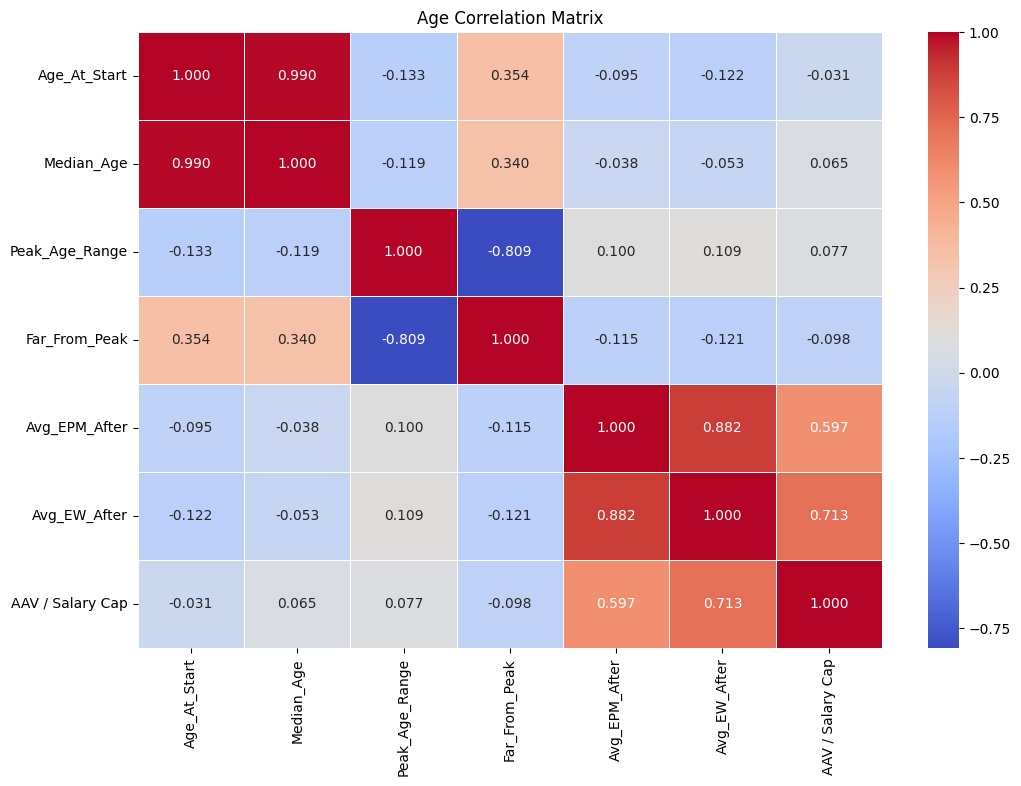

In [ ]:
# NEW AGE COLUMNS CORRELATION MATRIX

# Specify columns for correlation
age_columns = [
    'Age_At_Start', 'Median_Age', 'Peak_Age_Range', 'Far_From_Peak',
    'Avg_EPM_After', 'Avg_EW_After', 'AAV / Salary Cap'
]

# Calculate correlation matrix
correlation_matrix = NBA_FVC_filtered[age_columns].corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title('Age Correlation Matrix')
plt.show()

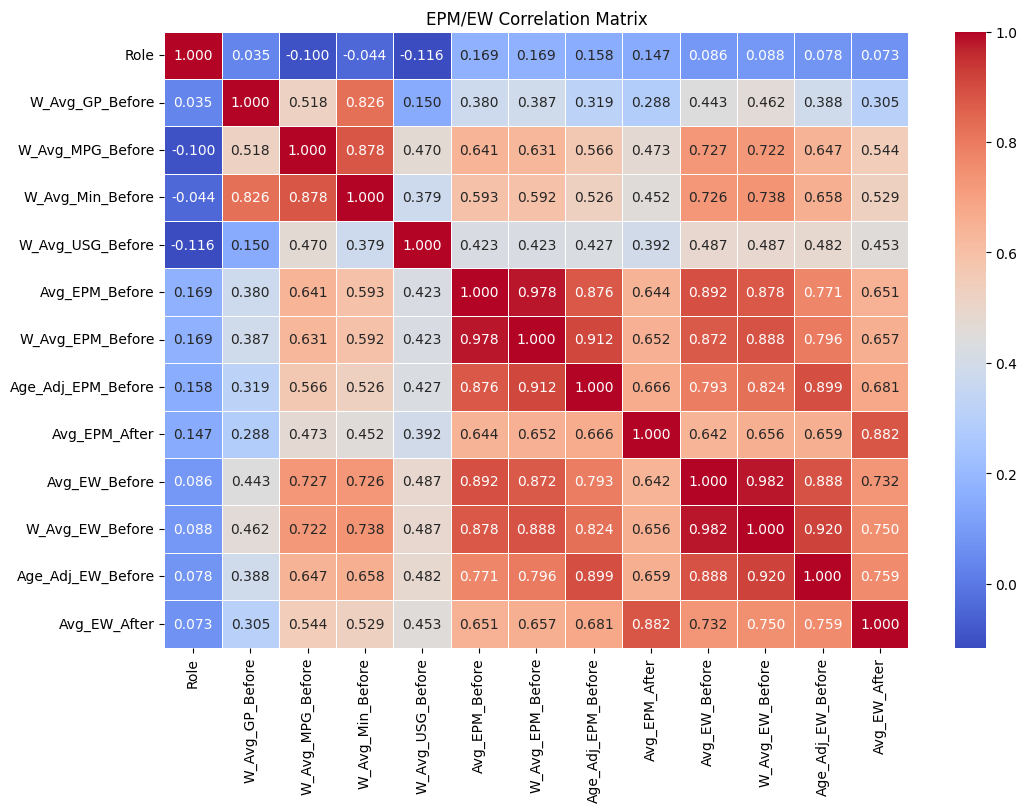

In [ ]:
# Specify columns for correlation
production_columns = [
    'Role', 'W_Avg_GP_Before', 'W_Avg_MPG_Before', 'W_Avg_Min_Before', 'W_Avg_USG_Before',
    'Avg_EPM_Before', 'W_Avg_EPM_Before', 'Age_Adj_EPM_Before', 'Avg_EPM_After',
    'Avg_EW_Before', 'W_Avg_EW_Before', 'Age_Adj_EW_Before', 'Avg_EW_After'
]

# Calculate correlation matrix
correlation_matrix = NBA_FVC_filtered[production_columns].corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title('EPM/EW Correlation Matrix')
plt.show()

In [ ]:
# # Specify columns for correlation
# new_ft_columns = [
#     'Median_Age', 'Avg_GP_Before', 'W_Avg_GP_Before', 'Avg_MPG_Before', 'W_Avg_MPG_Before', 'W_Avg_Min_Before', 'Avg_USG_Before', 'W_Avg_USG_Before',
#     'W_Avg_EPM_Before', 'Age Adj. EPM Before', 'Avg_EPM_After', 'W_Avg_EW_Before', 'Age Adj. EW Before', 'Avg_EW_After', 'AAV / Salary Cap',
# ]

# # Calculate correlation matrix
# correlation_matrix = NBA_FVC_filtered[new_ft_columns].corr()

# # Plot heatmap
# plt.figure(figsize=(12, 8))
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
# plt.title('GP / MPG / USG Correlation Matrix')
# plt.show()

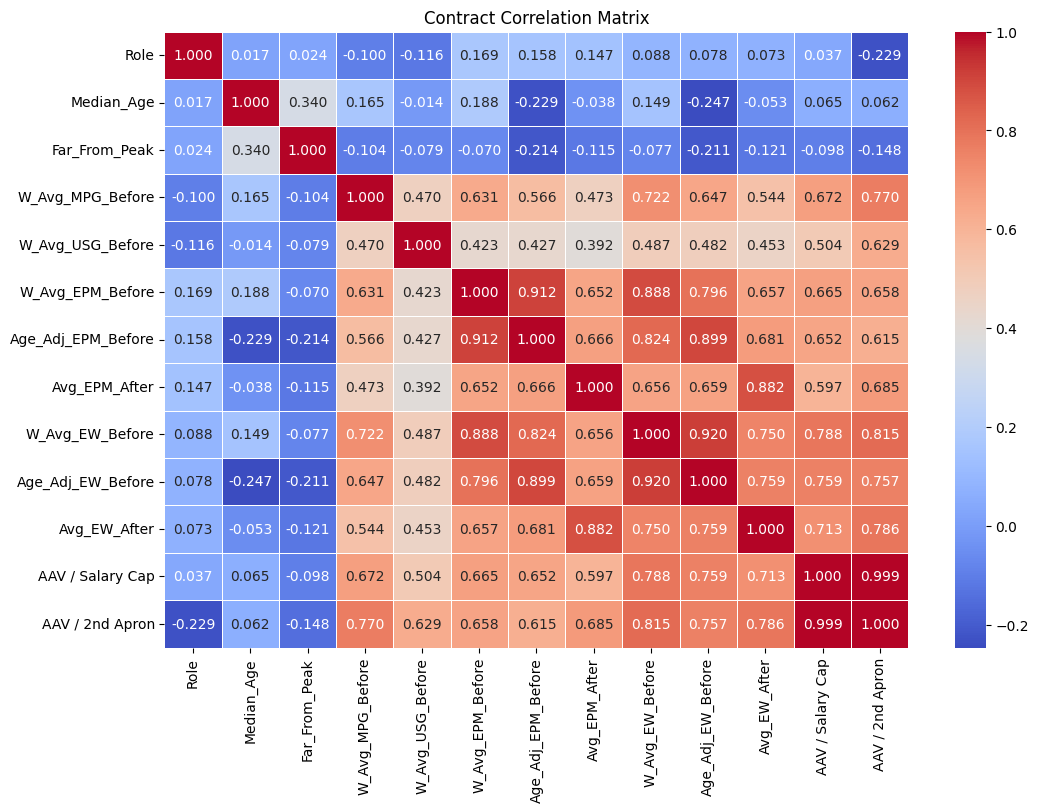

In [ ]:
# Specify columns for correlation
contract_columns = [
    'Role', 'Median_Age', 'Far_From_Peak',
    'W_Avg_MPG_Before', 'W_Avg_USG_Before',
    'W_Avg_EPM_Before', 'Age_Adj_EPM_Before', 'Avg_EPM_After',
    'W_Avg_EW_Before', 'Age_Adj_EW_Before', 'Avg_EW_After',
    'AAV / Salary Cap', 'AAV / 2nd Apron'
]

# Calculate correlation matrix
correlation_matrix = NBA_FVC_filtered[contract_columns].corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title('Contract Correlation Matrix')
plt.show()

In [ ]:
# Summary Statistics for Key Variables ".describe()"

summary_stats = NBA_FVC_filtered[contract_columns].describe()
summary_stats

,Role,Median_Age,Far_From_Peak,W_Avg_MPG_Before,W_Avg_USG_Before,W_Avg_EPM_Before,Age_Adj_EPM_Before,Avg_EPM_After,W_Avg_EW_Before,Age_Adj_EW_Before,Avg_EW_After,AAV / Salary Cap,AAV / 2nd Apron
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,131.000000
mean,1.771373,29.302745,3.205490,21.326244,0.181405,-0.801188,0.008154,-1.324084,2.559484,0.001981,1.972342,0.064473,0.053527
std,0.753644,3.933627,2.298242,7.430309,0.045920,2.243258,0.981130,2.411736,3.197683,1.035412,2.927863,0.073208,0.052400
min,1.000000,20.500000,0.000000,3.785710,0.062020,-6.721380,-3.516043,-7.932920,-1.653090,-2.255491,-2.331170,0.000100,0.009400
25%,1.000000,26.500000,1.500000,15.971587,0.148115,-2.350814,-0.658171,-2.953238,0.372225,-0.619388,0.016704,0.017300,0.015800
50%,2.000000,29.000000,3.000000,20.804900,0.177040,-0.974442,-0.087375,-1.533730,1.619238,-0.226666,0.972834,0.030800,0.033800
75%,2.000000,32.000000,4.500000,26.925512,0.209405,0.503949,0.594173,0.140918,3.707485,0.364787,2.997034,0.084300,0.071100
max,3.000000,43.000000,14.000000,38.660300,0.385630,9.649615,4.279125,8.238440,24.154000,6.510297,20.738550,0.378400,0.207800


In [ ]:
# Create scatter plot for 'Age_At_Start' vs 'Avg_EPM_After'
fig_age_signing = px.scatter(
    NBA_FVC_filtered,
    x='Age_At_Start',
    y='Avg_EPM_After',
    hover_name='Player',  # Hover will show player name
    hover_data={'Age_At_Start': True, 'Avg_EPM_After': True},  # Hover to show these fields
    title='Age At Start vs Average EPM After',
    trendline='ols'  # linear trendline (Ordinary Least Squares)
)

fig_age_signing.show()

In [ ]:
# Create scatter plot for 'Median Age' vs 'Avg_EPM_After'
fig_median_age = px.scatter(
    NBA_FVC_filtered,
    x='Median_Age',
    y='Avg_EPM_After',
    hover_name='Player',  # Hover will show player name
    hover_data={'Median_Age': True, 'Avg_EPM_After': True},  # Hover to show these fields
    title='Median Age vs Average EPM After',
    trendline='ols'  # linear trendline (Ordinary Least Squares)
)

fig_median_age.show()

In [ ]:
# Create scatter plot for 'Far_From_Peak' vs 'Avg_EPM_After'
fig_distance_peak = px.scatter(
    NBA_FVC_filtered,
    x='Far_From_Peak',
    y='Avg_EPM_After',
    hover_name='Player',  # Hover will show player name
    hover_data={'Far_From_Peak': True, 'Avg_EPM_After': True},  # Hover to show these fields
    title='Distance From Peak vs Average EPM After',
    trendline='ols'  # linear trendline (Ordinary Least Squares)
)

fig_distance_peak.show()

In [ ]:
# # List of column pairs you want to compare
# column_pairs = [('W_Avg_EPM_Before', 'EPM_1Y_After'),
#                 ('W_Avg_EW_Before', 'EW_1Y_After'),
#                 ('Age At Signing', 'AAV'),
#                 ('AAV', 'Start'),
#                 ('AAV / Salary Cap','EPM_1Y_After')]  # Replace with actual column names

# # Create scatter plots for the specified column pairs
# for col1, col2 in column_pairs:
#     plt.figure()
#     plt.scatter(NBA_FVC_filtered[col1], NBA_FVC_filtered[col2])
#     plt.xlabel(col1)
#     plt.ylabel(col2)
#     plt.title(f'Scatter plot of {col1} vs. {col2}')
#     plt.show()

In [ ]:
contract_changes = NBA_FVC_initial_filter.copy()

# Group by 'Start' year and calculate the average 'AAV / Salary Cap'
avg_aav_by_year = contract_changes.groupby('Start')['AAV / Salary Cap'].mean().reset_index()

# Create the Plotly bar graph
fig = px.bar(avg_aav_by_year,
             x='Start',
             y='AAV / Salary Cap',
             title='Average AAV / Salary Cap by Year',
             labels={'Start': 'Year', 'AAV / Salary Cap': 'Avg. AAV / Salary Cap'},
             text='AAV / Salary Cap')

# Customize the layout
fig.update_traces(texttemplate='%{text:.2%}', textposition='outside')
fig.update_layout(
    xaxis_title='Year',
    yaxis_title='Average AAV / Salary Cap',
    yaxis_tickformat='.2%',
    xaxis=dict(tickmode='linear', dtick=1)  # Ensure all years are shown on x-axis
)

# Show the plot
fig.show()

# Find the year with the highest average AAV / Salary Cap
max_year = avg_aav_by_year.loc[avg_aav_by_year['AAV / Salary Cap'].idxmax(), 'Start']
max_value = avg_aav_by_year['AAV / Salary Cap'].max()

print(f"Year with highest Avg. AAV / Salary Cap: {max_year} ({max_value:.2%})")

# Calculate year-over-year changes
avg_aav_by_year['YoY_Change'] = avg_aav_by_year['AAV / Salary Cap'].pct_change()

print("\nYear-over-Year Changes:")
print(avg_aav_by_year[['Start', 'YoY_Change']].to_string(index=False))

Year with highest Avg. AAV / Salary Cap: 2019 (8.68%)

Year-over-Year Changes:
 Start  YoY_Change
  2014         NaN
  2015    0.138630
  2016    0.251292
  2017   -0.134505
  2018   -0.143185
  2019    0.433842
  2020   -0.194467
  2021    0.098028
  2022   -0.059917
  2023    0.094542
  2024    0.081142


# EPM & EW Models

## EPM

In [ ]:
from sklearn.model_selection import train_test_split

# 80/20 TRAIN/TEST SPLIT
NBA_FVC_training_set, NBA_FVC_test_set = train_test_split(NBA_FVC_filtered, test_size=0.2, random_state=42)

# Check the sizes of each set
print(f"Training set size: {len(NBA_FVC_training_set)}")
print(f"Test set size: {len(NBA_FVC_test_set)}\n")

# NBA_FVC_training_set = NBA_FVC_filtered[(NBA_FVC_filtered['Start'] >= 2014) & (NBA_FVC_filtered['Start'] <= 2022)]
# NBA_FVC_test_set = NBA_FVC_filtered[NBA_FVC_filtered['Start'] == 2023].copy()

# FILTER FOR 2024/25 DATA (DEPLOYMENT SET)
NBA_FVC_2024 = NBA_FVC_initial_filter[NBA_FVC_initial_filter['Start'] == 2024]

# BASELINE MODELS
from sklearn.metrics import mean_squared_error
NBA_FVC_mean_epm = NBA_FVC_filtered['Avg_EPM_After'].mean()
NBA_FVC_test_set['Predicted_Avg_EPM'] = NBA_FVC_mean_epm
NBA_FVC_baseline_rmse = np.sqrt(mean_squared_error(NBA_FVC_test_set['Avg_EPM_After'], NBA_FVC_test_set['Predicted_Avg_EPM']))
print("Baseline RMSE:", NBA_FVC_baseline_rmse.round(4), "Mean:", NBA_FVC_mean_epm.round(4))

Training set size: 1020
Test set size: 255

Baseline RMSE: 2.3005 Mean: -1.3241


In [ ]:
## Checking for NaN predictor values
# NBA_FVC_training_set[['Player', 'Role', 'Age At Signing', 'W_Avg_Min_Before', 'W_Avg_USG_Before', 'W_Avg_EPM_Before', 'Avg_EPM_After']]

In [ ]:
# PRE-PROCESS (NORMALIZE) PREDICTOR DATA INTO Z-SCORES

from sklearn.preprocessing import StandardScaler

# Define numerical predictors (excluding the binary variable 'Peak_Age_Range' from standardization)
# numerical_predictors = ['Far_From_Peak', 'W_Avg_MPG_Before', 'W_Avg_USG_Before', 'Age_Adj_EPM_Before']
numerical_predictors = ['W_Avg_MPG_Before', 'W_Avg_USG_Before', 'Age_Adj_EPM_Before']

# Standardize only the numerical predictors
scaler = StandardScaler()

NBA_FVC_training_set[numerical_predictors] = scaler.fit_transform(NBA_FVC_training_set[numerical_predictors])
NBA_FVC_test_set[numerical_predictors] = scaler.transform(NBA_FVC_test_set[numerical_predictors])

NBA_FVC_2024[numerical_predictors] = scaler.transform(NBA_FVC_2024[numerical_predictors])
# NBA_FVC_Sandbox[numerical_predictors] = scaler.transform(NBA_FVC_Sandbox[numerical_predictors])

# Include 'Peak_Age_Range' in the full set of predictors
NBA_FVC_EPM_predictors = numerical_predictors + ['Peak_Age_Range']
# NBA_FVC_EPM_predictors = numerical_predictors

<ipython-input-30-c1a68b8a1323>:15: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



### Individual Models

In [ ]:
# LASSO EPM MODEL

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

NBA_FVC_EPM_target = 'Avg_EPM_After'

# Create and train the Lasso model (increase alpha to encourage feature selection)
alpha_value = 0.1
NBA_FVC_EPM_lasso_model = Lasso(alpha=alpha_value)
NBA_FVC_EPM_lasso_model.fit(NBA_FVC_training_set[NBA_FVC_EPM_predictors], NBA_FVC_training_set[NBA_FVC_EPM_target])

# Make predictions on the test set
NBA_FVC_test_set['Lasso_Predicted_Avg_EPM'] = NBA_FVC_EPM_lasso_model.predict(NBA_FVC_test_set[NBA_FVC_EPM_predictors])

# # Adjust predictions for players older than 29
# age_adjustment_factor = -0.7612  # The discovered coefficient
# NBA_FVC_test_set['Age_Adjustment'] = NBA_FVC_test_set.apply(
#     lambda row: 0.05 * (age_adjustment_factor * (row['Median_Age'] - 29)) if row['Median_Age'] > 29 else 0, axis=1) # modify multiplier as needed

# NBA_FVC_test_set['Lasso_Predicted_Avg_EPM'] = NBA_FVC_test_set['Lasso_Predicted_Avg_EPM'] + NBA_FVC_test_set['Age_Adjustment']

# Calculate RMSE and R-squared
NBA_FVC_EPM_rmse_lasso = np.sqrt(mean_squared_error(NBA_FVC_test_set['Avg_EPM_After'], NBA_FVC_test_set['Lasso_Predicted_Avg_EPM']))
print("Lasso RMSE:", round(NBA_FVC_EPM_rmse_lasso, 4))

NBA_FVC_EPM_r2_lasso = NBA_FVC_EPM_lasso_model.score(NBA_FVC_test_set[NBA_FVC_EPM_predictors], NBA_FVC_test_set[NBA_FVC_EPM_target])
print("Lasso R-squared:", round(NBA_FVC_EPM_r2_lasso, 4))

# Get the coefficients and identify which predictors are kept
lasso_coefficients = pd.Series(NBA_FVC_EPM_lasso_model.coef_, index=NBA_FVC_EPM_predictors)
print()
print("Lasso Coefficients:")
print(lasso_coefficients)

# Add a residual column to the test set (Residual = Predicted - Actual)
NBA_FVC_test_set['Residual'] = NBA_FVC_test_set['Lasso_Predicted_Avg_EPM'] - NBA_FVC_test_set['Avg_EPM_After']

# Display the selected columns with residuals
NBA_FVC_test_set[['Player', 'Role', 'Median_Age', 'Far_From_Peak', 'Peak_Age_Range', 'W_Avg_MPG_Before', 'W_Avg_USG_Before', 'Age_Adj_EPM_Before', 'Lasso_Predicted_Avg_EPM', 'Avg_EPM_After', 'Residual']]

Lasso RMSE: 1.7155
Lasso R-squared: 0.4437

Lasso Coefficients:
W_Avg_MPG_Before      0.242595
W_Avg_USG_Before      0.155249
Age_Adj_EPM_Before    1.329746
Peak_Age_Range        0.000000
dtype: float64


,Player,Role,Median_Age,Far_From_Peak,Peak_Age_Range,W_Avg_MPG_Before,W_Avg_USG_Before,Age_Adj_EPM_Before,Lasso_Predicted_Avg_EPM,Avg_EPM_After,Residual
1674,Josh Richardson,1.0,28.0,1.0,1.0,0.634551,-0.179129,0.220618,-0.893448,-1.433520,0.540072
483,Luol Deng,2.0,32.5,3.5,0.0,1.531079,-0.178692,0.377079,-0.467833,-0.663450,0.195618
961,Robert Covington,2.0,29.5,0.5,1.0,1.392381,-0.190492,1.778371,1.360051,0.754831,0.605220
1120,Jodie Meeks,1.0,31.0,2.0,1.0,-0.721659,0.041565,-1.002830,-2.815071,-2.457080,-0.357991
1154,Thaddeus Young,2.0,32.0,3.0,1.0,1.318257,-0.082985,0.849067,0.123020,0.323928,-0.200907
...,...,...,...,...,...,...,...,...,...,...,...
1020,Pat Connaughton,1.0,25.5,3.5,0.0,-0.774143,-1.156082,0.095315,-1.553482,-2.786650,1.233168
1548,Tony Bradley,3.0,24.5,4.5,0.0,-0.850679,-0.629694,1.151765,-0.085518,0.243300,-0.328818
574,Kevin Seraphin,2.5,27.5,1.5,1.0,-1.246768,0.740793,-1.045774,-2.891011,-2.549670,-0.341341
1340,Dario Saric,2.0,28.0,1.0,1.0,0.464643,-0.140890,0.242830,-0.899194,-1.220365,0.321172


In [ ]:
# RIDGE EPM MODEL

from sklearn.linear_model import Ridge

# Create and train the Ridge model (alpha controls regularization strength)
alpha_value = 0.1
NBA_FVC_EPM_ridge_model = Ridge(alpha=alpha_value)
NBA_FVC_EPM_ridge_model.fit(NBA_FVC_training_set[NBA_FVC_EPM_predictors], NBA_FVC_training_set[NBA_FVC_EPM_target])

# Make predictions on the test set
NBA_FVC_test_set['Ridge_Predicted_Avg_EPM'] = NBA_FVC_EPM_ridge_model.predict(NBA_FVC_test_set[NBA_FVC_EPM_predictors])

# Calculate RMSE and R-squared
NBA_FVC_EPM_rmse_ridge = np.sqrt(mean_squared_error(NBA_FVC_test_set['Avg_EPM_After'], NBA_FVC_test_set['Ridge_Predicted_Avg_EPM']))
print("Ridge RMSE:", round(NBA_FVC_EPM_rmse_ridge, 4))

NBA_FVC_EPM_r2_ridge = NBA_FVC_EPM_ridge_model.score(NBA_FVC_test_set[NBA_FVC_EPM_predictors], NBA_FVC_test_set[NBA_FVC_EPM_target])
print("Ridge R-squared:", round(NBA_FVC_EPM_r2_ridge, 4))

# Get the coefficients and display them
ridge_coefficients = pd.Series(NBA_FVC_EPM_ridge_model.coef_, index=NBA_FVC_EPM_predictors)
print("Ridge Coefficients:")
print(ridge_coefficients)

# Add a residual column to the test set (Residual = Predicted - Actual)
NBA_FVC_test_set['Residual'] = NBA_FVC_test_set['Ridge_Predicted_Avg_EPM'] - NBA_FVC_test_set['Avg_EPM_After']

# Display the selected columns with residuals
NBA_FVC_test_set[['Player', 'Start', 'Median_Age', 'W_Avg_MPG_Before', 'W_Avg_USG_Before', 'Age_Adj_EPM_Before', 'Ridge_Predicted_Avg_EPM', 'Avg_EPM_After', 'Residual']]

Ridge RMSE: 1.7229
Ridge R-squared: 0.4389
Ridge Coefficients:
W_Avg_MPG_Before      0.288334
W_Avg_USG_Before      0.211768
Age_Adj_EPM_Before    1.374326
Peak_Age_Range        0.069943
dtype: float64


,Player,Start,Median_Age,W_Avg_MPG_Before,W_Avg_USG_Before,Age_Adj_EPM_Before,Ridge_Predicted_Avg_EPM,Avg_EPM_After,Residual
1674,Josh Richardson,2022,28.0,0.634551,-0.179129,0.220618,-0.834405,-1.433520,0.599115
483,Luol Deng,2016,32.5,1.531079,-0.178692,0.377079,-0.430727,-0.663450,0.232724
961,Robert Covington,2018,29.5,1.392381,-0.190492,1.778371,1.522557,0.754831,0.767726
1120,Jodie Meeks,2018,31.0,-0.721659,0.041565,-1.002830,-2.860126,-2.457080,-0.403046
1154,Thaddeus Young,2019,32.0,1.318257,-0.082985,0.849067,0.246785,0.323928,-0.077143
...,...,...,...,...,...,...,...,...,...
1020,Pat Connaughton,2018,25.5,-0.774143,-1.156082,0.095315,-1.689617,-2.786650,1.097033
1548,Tony Bradley,2021,24.5,-0.850679,-0.629694,1.151765,-0.148307,0.243300,-0.391607
574,Kevin Seraphin,2016,27.5,-1.246768,0.740793,-1.045774,-2.922479,-2.549670,-0.372809
1340,Dario Saric,2020,28.0,0.464643,-0.140890,0.242830,-0.844771,-1.220365,0.375595


In [ ]:
# RANDOM FOREST EPM MODEL

from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor
NBA_FVC_EPM_rf_model = RandomForestRegressor(random_state=42, n_estimators=100)

# Fit the model to the training data
NBA_FVC_EPM_rf_model.fit(NBA_FVC_training_set[NBA_FVC_EPM_predictors], NBA_FVC_training_set[NBA_FVC_EPM_target])

# Make predictions on the test set
NBA_FVC_test_set['RF_Predicted_Avg_EPM'] = NBA_FVC_EPM_rf_model.predict(NBA_FVC_test_set[NBA_FVC_EPM_predictors])

# RMSE & R^2
NBA_FVC_EPM_rmse_rf = np.sqrt(mean_squared_error(NBA_FVC_test_set['Avg_EPM_After'], NBA_FVC_test_set['RF_Predicted_Avg_EPM']))
print("RF RMSE:", round(NBA_FVC_EPM_rmse_rf, 4))

NBA_FVC_EPM_r2_rf = NBA_FVC_EPM_rf_model.score(NBA_FVC_test_set[NBA_FVC_EPM_predictors], NBA_FVC_test_set[NBA_FVC_EPM_target])
print("RF R-squared:", round(NBA_FVC_EPM_r2_rf, 4))

# Add a residual column to the test set (Residual = Predicted - Actual)
NBA_FVC_test_set['Residual'] = NBA_FVC_test_set['RF_Predicted_Avg_EPM'] - NBA_FVC_test_set['Avg_EPM_After']

# Display the relevant columns
NBA_FVC_test_set[['Player', 'Role', 'Median_Age', 'W_Avg_MPG_Before', 'W_Avg_USG_Before', 'Age_Adj_EPM_Before', 'RF_Predicted_Avg_EPM', 'Avg_EPM_After', 'Residual']]

RF RMSE: 1.8462
RF R-squared: 0.3557


,Player,Role,Median_Age,W_Avg_MPG_Before,W_Avg_USG_Before,Age_Adj_EPM_Before,RF_Predicted_Avg_EPM,Avg_EPM_After,Residual
1674,Josh Richardson,1.0,28.0,0.634551,-0.179129,0.220618,-1.051880,-1.433520,0.381640
483,Luol Deng,2.0,32.5,1.531079,-0.178692,0.377079,-0.720755,-0.663450,-0.057305
961,Robert Covington,2.0,29.5,1.392381,-0.190492,1.778371,2.312826,0.754831,1.557995
1120,Jodie Meeks,1.0,31.0,-0.721659,0.041565,-1.002830,-2.476415,-2.457080,-0.019335
1154,Thaddeus Young,2.0,32.0,1.318257,-0.082985,0.849067,0.632937,0.323928,0.309009
...,...,...,...,...,...,...,...,...,...
1020,Pat Connaughton,1.0,25.5,-0.774143,-1.156082,0.095315,-1.919846,-2.786650,0.866804
1548,Tony Bradley,3.0,24.5,-0.850679,-0.629694,1.151765,0.773792,0.243300,0.530492
574,Kevin Seraphin,2.5,27.5,-1.246768,0.740793,-1.045774,-2.379604,-2.549670,0.170066
1340,Dario Saric,2.0,28.0,0.464643,-0.140890,0.242830,-0.497856,-1.220365,0.722509


In [ ]:
# SIMPLE LINEAR EPM MODEL

from sklearn.linear_model import LinearRegression

# Create and train the linear model
NBA_FVC_EPM_linear_model = LinearRegression()
NBA_FVC_EPM_linear_model.fit(NBA_FVC_training_set[NBA_FVC_EPM_predictors], NBA_FVC_training_set[NBA_FVC_EPM_target])

# Make predictions on the test set
NBA_FVC_test_set['Linear_Predicted_Avg_EPM'] = NBA_FVC_EPM_linear_model.predict(NBA_FVC_test_set[NBA_FVC_EPM_predictors])

# Calculate RMSE and R-squared
NBA_FVC_EPM_rmse_lm = np.sqrt(mean_squared_error(NBA_FVC_test_set['Avg_EPM_After'], NBA_FVC_test_set['Linear_Predicted_Avg_EPM']))
print("LM RMSE:", round(NBA_FVC_EPM_rmse_lm, 4))

NBA_FVC_EPM_r2_lm = NBA_FVC_EPM_linear_model.score(NBA_FVC_test_set[NBA_FVC_EPM_predictors], NBA_FVC_test_set[NBA_FVC_EPM_target])
print("LM R-squared:", round(NBA_FVC_EPM_r2_lm, 4))

# Add a residual column to the test set (Residual = Predicted - Actual)
NBA_FVC_test_set['Residual'] = NBA_FVC_test_set['Linear_Predicted_Avg_EPM'] - NBA_FVC_test_set['Avg_EPM_After']

# Display the selected columns with residuals
NBA_FVC_test_set[['Player', 'Start', 'Median_Age', 'W_Avg_MPG_Before', 'W_Avg_USG_Before', 'Age_Adj_EPM_Before', 'Linear_Predicted_Avg_EPM', 'Avg_EPM_After', 'Residual']]

LM RMSE: 1.7229
LM R-squared: 0.4389


,Player,Start,Median_Age,W_Avg_MPG_Before,W_Avg_USG_Before,Age_Adj_EPM_Before,Linear_Predicted_Avg_EPM,Avg_EPM_After,Residual
1674,Josh Richardson,2022,28.0,0.634551,-0.179129,0.220618,-0.834400,-1.433520,0.599120
483,Luol Deng,2016,32.5,1.531079,-0.178692,0.377079,-0.430736,-0.663450,0.232714
961,Robert Covington,2018,29.5,1.392381,-0.190492,1.778371,1.522802,0.754831,0.767971
1120,Jodie Meeks,2018,31.0,-0.721659,0.041565,-1.002830,-2.860272,-2.457080,-0.403192
1154,Thaddeus Young,2019,32.0,1.318257,-0.082985,0.849067,0.246862,0.323928,-0.077066
...,...,...,...,...,...,...,...,...,...
1020,Pat Connaughton,2018,25.5,-0.774143,-1.156082,0.095315,-1.689513,-2.786650,1.097137
1548,Tony Bradley,2021,24.5,-0.850679,-0.629694,1.151765,-0.148023,0.243300,-0.391323
574,Kevin Seraphin,2016,27.5,-1.246768,0.740793,-1.045774,-2.922624,-2.549670,-0.372954
1340,Dario Saric,2020,28.0,0.464643,-0.140890,0.242830,-0.844753,-1.220365,0.375612


In [ ]:
# K-NEAREST NEIGHBORS (kNN) EPM MODEL

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score

# Initialize the kNN Regressor (you can set k using the 'n_neighbors' parameter)
NBA_FVC_EPM_knn_model = KNeighborsRegressor(n_neighbors=15) # k=5 by default
                                                            # "optimal k" code from before wasn't working correctly (likely showing optimal k on training set, rather than test set)
# Fit the model to the training data
NBA_FVC_EPM_knn_model.fit(NBA_FVC_training_set[NBA_FVC_EPM_predictors], NBA_FVC_training_set[NBA_FVC_EPM_target])

# Make predictions on the test set
NBA_FVC_test_set['kNN_Predicted_Avg_EPM'] = NBA_FVC_EPM_knn_model.predict(NBA_FVC_test_set[NBA_FVC_EPM_predictors])

# RMSE & R^2
NBA_FVC_EPM_rmse_kNN = np.sqrt(mean_squared_error(NBA_FVC_test_set['Avg_EPM_After'], NBA_FVC_test_set['kNN_Predicted_Avg_EPM']))
print("kNN RMSE:", round(NBA_FVC_EPM_rmse_kNN, 4))

NBA_FVC_EPM_r2_kNN = NBA_FVC_EPM_knn_model.score(NBA_FVC_test_set[NBA_FVC_EPM_predictors], NBA_FVC_test_set[NBA_FVC_EPM_target])
print("kNN R-squared:", round(NBA_FVC_EPM_r2_kNN, 4))

# Add a residual column to the test set (Residual = Predicted - Actual)
NBA_FVC_test_set['Residual'] = NBA_FVC_test_set['kNN_Predicted_Avg_EPM'] - NBA_FVC_test_set['Avg_EPM_After']

# Display the relevant columns
NBA_FVC_test_set[['Player', 'Role', 'Median_Age', 'W_Avg_MPG_Before', 'W_Avg_USG_Before', 'Age_Adj_EPM_Before', 'kNN_Predicted_Avg_EPM', 'Avg_EPM_After', 'Residual']]

kNN RMSE: 1.725
kNN R-squared: 0.4375


,Player,Role,Median_Age,W_Avg_MPG_Before,W_Avg_USG_Before,Age_Adj_EPM_Before,kNN_Predicted_Avg_EPM,Avg_EPM_After,Residual
1674,Josh Richardson,1.0,28.0,0.634551,-0.179129,0.220618,-0.505081,-1.433520,0.928439
483,Luol Deng,2.0,32.5,1.531079,-0.178692,0.377079,-0.903048,-0.663450,-0.239597
961,Robert Covington,2.0,29.5,1.392381,-0.190492,1.778371,1.748923,0.754831,0.994092
1120,Jodie Meeks,1.0,31.0,-0.721659,0.041565,-1.002830,-3.128117,-2.457080,-0.671037
1154,Thaddeus Young,2.0,32.0,1.318257,-0.082985,0.849067,0.073251,0.323928,-0.250677
...,...,...,...,...,...,...,...,...,...
1020,Pat Connaughton,1.0,25.5,-0.774143,-1.156082,0.095315,-1.454134,-2.786650,1.332516
1548,Tony Bradley,3.0,24.5,-0.850679,-0.629694,1.151765,0.043629,0.243300,-0.199671
574,Kevin Seraphin,2.5,27.5,-1.246768,0.740793,-1.045774,-2.479291,-2.549670,0.070379
1340,Dario Saric,2.0,28.0,0.464643,-0.140890,0.242830,-0.633619,-1.220365,0.586746


In [ ]:
# GRADIENT BOOSTING EPM MODEL

from sklearn.ensemble import GradientBoostingRegressor

# Initialize the Gradient Boosting Regressor model
NBA_FVC_EPM_gbm = GradientBoostingRegressor()

NBA_FVC_EPM_gbm.fit(NBA_FVC_training_set[NBA_FVC_EPM_predictors], NBA_FVC_training_set[NBA_FVC_EPM_target])

NBA_FVC_test_set['GB_Predicted_Avg_EPM'] = NBA_FVC_EPM_gbm.predict(NBA_FVC_test_set[NBA_FVC_EPM_predictors])

NBA_FVC_EPM_rmse_gbm = np.sqrt(mean_squared_error(NBA_FVC_test_set['Avg_EPM_After'], NBA_FVC_test_set['GB_Predicted_Avg_EPM']))
print("GB RMSE:", round(NBA_FVC_EPM_rmse_gbm, 4))

NBA_FVC_EPM_r2_gbm = NBA_FVC_EPM_gbm.score(NBA_FVC_test_set[NBA_FVC_EPM_predictors], NBA_FVC_test_set[NBA_FVC_EPM_target])
print("GB R-squared:", round(NBA_FVC_EPM_r2_gbm, 4))

# Add a residual column to the test set (Residual = Predicted - Actual)
NBA_FVC_test_set['Residual'] = NBA_FVC_test_set['GB_Predicted_Avg_EPM'] - NBA_FVC_test_set['Avg_EPM_After']

# Display relevant columns
NBA_FVC_test_set[['Player', 'Role', 'Median_Age', 'W_Avg_MPG_Before', 'W_Avg_USG_Before', 'Age_Adj_EPM_Before',
                  'GB_Predicted_Avg_EPM', 'Avg_EPM_After', 'Residual']]

GB RMSE: 1.7662
GB R-squared: 0.4103


,Player,Role,Median_Age,W_Avg_MPG_Before,W_Avg_USG_Before,Age_Adj_EPM_Before,GB_Predicted_Avg_EPM,Avg_EPM_After,Residual
1674,Josh Richardson,1.0,28.0,0.634551,-0.179129,0.220618,-1.037187,-1.433520,0.396333
483,Luol Deng,2.0,32.5,1.531079,-0.178692,0.377079,-0.077321,-0.663450,0.586129
961,Robert Covington,2.0,29.5,1.392381,-0.190492,1.778371,2.104125,0.754831,1.349295
1120,Jodie Meeks,1.0,31.0,-0.721659,0.041565,-1.002830,-2.288374,-2.457080,0.168706
1154,Thaddeus Young,2.0,32.0,1.318257,-0.082985,0.849067,0.209123,0.323928,-0.114804
...,...,...,...,...,...,...,...,...,...
1020,Pat Connaughton,1.0,25.5,-0.774143,-1.156082,0.095315,-1.942075,-2.786650,0.844575
1548,Tony Bradley,3.0,24.5,-0.850679,-0.629694,1.151765,-0.132990,0.243300,-0.376290
574,Kevin Seraphin,2.5,27.5,-1.246768,0.740793,-1.045774,-1.889897,-2.549670,0.659773
1340,Dario Saric,2.0,28.0,0.464643,-0.140890,0.242830,-0.301780,-1.220365,0.918585


In [ ]:
# XGBoost EPM MODEL

from xgboost import XGBRegressor

NBA_FVC_EPM_xgb = XGBRegressor()
NBA_FVC_EPM_xgb.fit(NBA_FVC_training_set[NBA_FVC_EPM_predictors], NBA_FVC_training_set[NBA_FVC_EPM_target])
NBA_FVC_test_set['XGB_Predicted_Avg_EPM'] = NBA_FVC_EPM_xgb.predict(NBA_FVC_test_set[NBA_FVC_EPM_predictors])

NBA_FVC_EPM_rmse_xgb = np.sqrt(mean_squared_error(NBA_FVC_test_set['Avg_EPM_After'], NBA_FVC_test_set['XGB_Predicted_Avg_EPM']))
print("XGB RMSE:", round(NBA_FVC_EPM_rmse_xgb, 4))

NBA_FVC_EPM_r2_xgb = NBA_FVC_EPM_xgb.score(NBA_FVC_test_set[NBA_FVC_EPM_predictors], NBA_FVC_test_set[NBA_FVC_EPM_target])
print("XGB R-squared:", round(NBA_FVC_EPM_r2_xgb, 4))

# Add a residual column to the test set (Residual = Predicted - Actual)
NBA_FVC_test_set['Residual'] = NBA_FVC_test_set['XGB_Predicted_Avg_EPM'] - NBA_FVC_test_set['Avg_EPM_After']

# Display relevant columns
NBA_FVC_test_set[['Player', 'Role', 'Median_Age', 'W_Avg_MPG_Before', 'W_Avg_USG_Before', 'Age_Adj_EPM_Before',
                  'XGB_Predicted_Avg_EPM', 'Avg_EPM_After', 'Residual']]

XGB RMSE: 1.9823
XGB R-squared: 0.2572


,Player,Role,Median_Age,W_Avg_MPG_Before,W_Avg_USG_Before,Age_Adj_EPM_Before,XGB_Predicted_Avg_EPM,Avg_EPM_After,Residual
1674,Josh Richardson,1.0,28.0,0.634551,-0.179129,0.220618,-0.930552,-1.433520,0.502968
483,Luol Deng,2.0,32.5,1.531079,-0.178692,0.377079,-0.048122,-0.663450,0.615328
961,Robert Covington,2.0,29.5,1.392381,-0.190492,1.778371,1.850374,0.754831,1.095544
1120,Jodie Meeks,1.0,31.0,-0.721659,0.041565,-1.002830,-2.676996,-2.457080,-0.219916
1154,Thaddeus Young,2.0,32.0,1.318257,-0.082985,0.849067,1.605192,0.323928,1.281264
...,...,...,...,...,...,...,...,...,...
1020,Pat Connaughton,1.0,25.5,-0.774143,-1.156082,0.095315,-2.210351,-2.786650,0.576299
1548,Tony Bradley,3.0,24.5,-0.850679,-0.629694,1.151765,0.047424,0.243300,-0.195876
574,Kevin Seraphin,2.5,27.5,-1.246768,0.740793,-1.045774,-1.487931,-2.549670,1.061739
1340,Dario Saric,2.0,28.0,0.464643,-0.140890,0.242830,-0.055597,-1.220365,1.164769


In [ ]:
# # NEURAL NETWORK EPM MODEL

# from sklearn.metrics import r2_score
# from sklearn.preprocessing import StandardScaler
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense

# # Define predictors and target
# NBA_FVC_EPM_predictors = ['Role', 'Median Age', 'W_Avg_Min_Before', 'W_Avg_USG_Before', 'Age Adj. EPM Before']
# NBA_FVC_EPM_target = 'Avg_EPM_After'

# # Standardize the data (important for neural networks)
# scaler = StandardScaler()
# NBA_FVC_training_scaled = scaler.fit_transform(NBA_FVC_training_set[NBA_FVC_EPM_predictors])
# NBA_FVC_test_scaled = scaler.transform(NBA_FVC_test_set[NBA_FVC_EPM_predictors])

# # Define the neural network model
# model = Sequential()

# # Add layers to the model (input layer + 2 hidden layers + output layer)
# model.add(Dense(64, input_dim=len(NBA_FVC_EPM_predictors), activation='relu'))  # Input layer and 1st hidden layer
# model.add(Dense(32, activation='relu'))  # 2nd hidden layer
# model.add(Dense(1, activation='linear'))  # Output layer (linear activation for regression)

# # Compile the model
# model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_squared_error'])

# # Train the model
# model.fit(NBA_FVC_training_scaled, NBA_FVC_training_set[NBA_FVC_EPM_target], epochs=100, batch_size=32, verbose=1)

# # Make predictions on the test set
# NBA_FVC_test_set['NN_Predicted_Avg_EPM'] = model.predict(NBA_FVC_test_scaled)

# # Calculate RMSE and R-squared
# NBA_FVC_EPM_rmse_nn = np.sqrt(mean_squared_error(NBA_FVC_test_set['Avg_EPM_After'], NBA_FVC_test_set['NN_Predicted_Avg_EPM']))
# NBA_FVC_EPM_r2_nn = r2_score(NBA_FVC_test_set['Avg_EPM_After'], NBA_FVC_test_set['NN_Predicted_Avg_EPM'])

# print("NN RMSE:", round(NBA_FVC_EPM_rmse_nn, 4))
# print("NN R-squared:", round(NBA_FVC_EPM_r2_nn, 4))

# # Add a residual column to the test set (Residual = Predicted - Actual)
# NBA_FVC_test_set['NN_Residual'] = NBA_FVC_test_set['NN_Predicted_Avg_EPM'] - NBA_FVC_test_set['Avg_EPM_After']

# # Display the selected columns with residuals
# NBA_FVC_test_set[['Player', 'Role', 'Median Age', 'W_Avg_MPG_Before', 'W_Avg_USG_Before', 'Age_Adj_EPM_Before', 'NN_Predicted_Avg_EPM', 'Avg_EPM_After', 'NN_Residual']]

### Ensemble

In [ ]:
# ENSEMBLE EPM MODEL

from sklearn.metrics import r2_score

NBA_FVC_test_set['Ensemble_Pred_Avg_EPM'] = (NBA_FVC_test_set['Lasso_Predicted_Avg_EPM'] +
                                             NBA_FVC_test_set['Linear_Predicted_Avg_EPM'] +
                                             NBA_FVC_test_set['kNN_Predicted_Avg_EPM']) / 3  # Dividing by the total number of models

# Calculate RMSE and R-squared
NBA_FVC_EPM_rmse_ensemble = np.sqrt(mean_squared_error(NBA_FVC_test_set['Avg_EPM_After'], NBA_FVC_test_set['Ensemble_Pred_Avg_EPM']))
print("Ensemble RMSE:", round(NBA_FVC_EPM_rmse_ensemble, 4))

NBA_FVC_EPM_r2_ensemble = r2_score(NBA_FVC_test_set['Avg_EPM_After'], NBA_FVC_test_set['Ensemble_Pred_Avg_EPM'])
print("Ensemble R-squared:", round(NBA_FVC_EPM_r2_ensemble, 4))

# Add a residual column to the test set (Residual = Predicted - Actual)
NBA_FVC_test_set['EPM_Residual'] = NBA_FVC_test_set['Ensemble_Pred_Avg_EPM'] - NBA_FVC_test_set['Avg_EPM_After']

# Display the selected columns with residuals
NBA_FVC_test_set[['Player', 'Start', 'Median_Age', 'W_Avg_MPG_Before', 'W_Avg_USG_Before', 'Age_Adj_EPM_Before', 'Ensemble_Pred_Avg_EPM', 'Avg_EPM_After', 'EPM_Residual']]

Ensemble RMSE: 1.6952
Ensemble R-squared: 0.4568


,Player,Start,Median_Age,W_Avg_MPG_Before,W_Avg_USG_Before,Age_Adj_EPM_Before,Ensemble_Pred_Avg_EPM,Avg_EPM_After,EPM_Residual
1674,Josh Richardson,2022,28.0,0.634551,-0.179129,0.220618,-0.744310,-1.433520,0.689210
483,Luol Deng,2016,32.5,1.531079,-0.178692,0.377079,-0.600539,-0.663450,0.062912
961,Robert Covington,2018,29.5,1.392381,-0.190492,1.778371,1.543925,0.754831,0.789094
1120,Jodie Meeks,2018,31.0,-0.721659,0.041565,-1.002830,-2.934487,-2.457080,-0.477407
1154,Thaddeus Young,2019,32.0,1.318257,-0.082985,0.849067,0.147711,0.323928,-0.176217
...,...,...,...,...,...,...,...,...,...
1020,Pat Connaughton,2018,25.5,-0.774143,-1.156082,0.095315,-1.565709,-2.786650,1.220941
1548,Tony Bradley,2021,24.5,-0.850679,-0.629694,1.151765,-0.063304,0.243300,-0.306604
574,Kevin Seraphin,2016,27.5,-1.246768,0.740793,-1.045774,-2.764308,-2.549670,-0.214638
1340,Dario Saric,2020,28.0,0.464643,-0.140890,0.242830,-0.792522,-1.220365,0.427843


## EW

In [ ]:
# BASELINE MODELS

NBA_FVC_mean_ew = NBA_FVC_filtered['Avg_EW_After'].mean()
NBA_FVC_test_set['Predicted_Avg_EW'] = NBA_FVC_mean_ew
NBA_FVC_baseline_rmse = np.sqrt(mean_squared_error(NBA_FVC_test_set['Avg_EW_After'], NBA_FVC_test_set['Predicted_Avg_EW']))
print("Baseline RMSE:", NBA_FVC_baseline_rmse.round(4), "Mean:", NBA_FVC_mean_ew.round(4))

Baseline RMSE: 2.9794 Mean: 1.9723


In [ ]:
# DEFINE PREDICTORS FOR EW MODELS

scaler = StandardScaler()

# Standardize 'Age_Adj_EW_Before' & 'W_Avg_Min_Before'
NBA_FVC_training_set['Age_Adj_EW_Before'] = scaler.fit_transform(NBA_FVC_training_set[['Age_Adj_EW_Before']])
NBA_FVC_test_set['Age_Adj_EW_Before'] = scaler.transform(NBA_FVC_test_set[['Age_Adj_EW_Before']])

NBA_FVC_2024['Age_Adj_EW_Before'] = scaler.transform(NBA_FVC_2024[['Age_Adj_EW_Before']])

# NBA_FVC_training_set['W_Avg_Min_Before'] = scaler.fit_transform(NBA_FVC_training_set[['W_Avg_Min_Before']])
# NBA_FVC_test_set['W_Avg_Min_Before'] = scaler.transform(NBA_FVC_test_set[['W_Avg_Min_Before']])

# Define the EW predictors
# NBA_FVC_EW_predictors = ['Peak_Age_Range', 'Far_From_Peak', 'W_Avg_Min_Before', 'W_Avg_USG_Before', 'Age_Adj_EW_Before']
NBA_FVC_EW_predictors = ['W_Avg_MPG_Before', 'W_Avg_USG_Before', 'Age_Adj_EW_Before']

<ipython-input-41-884b44f42df3>:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



### Individual Models

In [ ]:
# LASSO EW MODEL

NBA_FVC_EW_target = 'Avg_EW_After'

# Create and train the Lasso model (increase alpha to encourage feature selection)
alpha_value = 0.1
NBA_FVC_EW_lasso_model = Lasso(alpha=alpha_value)
NBA_FVC_EW_lasso_model.fit(NBA_FVC_training_set[NBA_FVC_EW_predictors], NBA_FVC_training_set[NBA_FVC_EW_target])

# Make predictions on the test set
NBA_FVC_test_set['Lasso_Predicted_Avg_EW'] = NBA_FVC_EW_lasso_model.predict(NBA_FVC_test_set[NBA_FVC_EW_predictors])

# # Adjust predictions for players older than 29
# age_adjustment_factor = -0.7738  # The discovered coefficient
# NBA_FVC_test_set['Age_Adjustment'] = NBA_FVC_test_set.apply(
#     lambda row: 0.05 * (age_adjustment_factor * (row['Median_Age'] - 29)) if row['Median_Age'] > 29 else 0, axis=1) # modify multiplier as needed

# NBA_FVC_test_set['Lasso_Predicted_Avg_EW'] = NBA_FVC_test_set['Lasso_Predicted_Avg_EW'] + NBA_FVC_test_set['Age_Adjustment']

# Calculate RMSE and R-squared
NBA_FVC_EW_rmse_lasso = np.sqrt(mean_squared_error(NBA_FVC_test_set['Avg_EW_After'], NBA_FVC_test_set['Lasso_Predicted_Avg_EW']))
print("Lasso RMSE:", round(NBA_FVC_EW_rmse_lasso, 4))

NBA_FVC_EW_r2_lasso = NBA_FVC_EW_lasso_model.score(NBA_FVC_test_set[NBA_FVC_EW_predictors], NBA_FVC_test_set[NBA_FVC_EW_target])
print("Lasso R-squared:", round(NBA_FVC_EW_r2_lasso, 4))

# Get the coefficients and identify which predictors are kept
lasso_coefficients = pd.Series(NBA_FVC_EW_lasso_model.coef_, index=NBA_FVC_EW_predictors)
print()
print("Lasso Coefficients:")
print(lasso_coefficients)

# Add a residual column to the test set (Residual = Predicted - Actual)
NBA_FVC_test_set['Residual'] = NBA_FVC_test_set['Lasso_Predicted_Avg_EW'] - NBA_FVC_test_set['Avg_EW_After']

# Display the selected columns with residuals
NBA_FVC_test_set[['Player', 'Role', 'Median_Age', 'Far_From_Peak', 'Peak_Age_Range', 'W_Avg_MPG_Before', 'W_Avg_USG_Before', 'Age_Adj_EW_Before', 'Lasso_Predicted_Avg_EW', 'Avg_EW_After', 'Residual']]

Lasso RMSE: 1.9249
Lasso R-squared: 0.5824

Lasso Coefficients:
W_Avg_MPG_Before     0.200117
W_Avg_USG_Before     0.199916
Age_Adj_EW_Before    1.883890
dtype: float64


,Player,Role,Median_Age,Far_From_Peak,Peak_Age_Range,W_Avg_MPG_Before,W_Avg_USG_Before,Age_Adj_EW_Before,Lasso_Predicted_Avg_EW,Avg_EW_After,Residual
1674,Josh Richardson,1.0,28.0,1.0,1.0,0.634551,-0.179129,0.161216,2.382595,1.553870,0.828725
483,Luol Deng,2.0,32.5,3.5,0.0,1.531079,-0.178692,0.776447,3.721122,1.286902,2.434220
961,Robert Covington,2.0,29.5,0.5,1.0,1.392381,-0.190492,2.369613,6.692356,4.541768,2.150589
1120,Jodie Meeks,1.0,31.0,2.0,1.0,-0.721659,0.041565,-0.941426,0.078061,0.035177,0.042884
1154,Thaddeus Young,2.0,32.0,3.0,1.0,1.318257,-0.082985,1.425581,4.920562,3.241130,1.679432
...,...,...,...,...,...,...,...,...,...,...,...
1020,Pat Connaughton,1.0,25.5,3.5,0.0,-0.774143,-1.156082,0.021437,1.642056,0.146533,1.495523
1548,Tony Bradley,3.0,24.5,4.5,0.0,-0.850679,-0.629694,0.213966,2.094676,1.202780,0.891896
574,Kevin Seraphin,2.5,27.5,1.5,1.0,-1.246768,0.740793,-0.693354,0.580103,0.153598,0.426505
1340,Dario Saric,2.0,28.0,1.0,1.0,0.464643,-0.140890,0.218663,2.464463,1.012711,1.451752


In [ ]:
# RIDGE EW MODEL

# Create and train the Ridge model (alpha controls regularization strength)
alpha_value = 1.0
NBA_FVC_EW_ridge_model = Ridge(alpha=alpha_value)
NBA_FVC_EW_ridge_model.fit(NBA_FVC_training_set[NBA_FVC_EW_predictors], NBA_FVC_training_set[NBA_FVC_EW_target])

# Make predictions on the test set
NBA_FVC_test_set['Ridge_Predicted_Avg_EW'] = NBA_FVC_EW_ridge_model.predict(NBA_FVC_test_set[NBA_FVC_EW_predictors])

# Calculate RMSE and R-squared
NBA_FVC_EW_rmse_ridge = np.sqrt(mean_squared_error(NBA_FVC_test_set['Avg_EW_After'], NBA_FVC_test_set['Ridge_Predicted_Avg_EW']))
print("Ridge RMSE:", round(NBA_FVC_EW_rmse_ridge, 4))

NBA_FVC_EW_r2_ridge = NBA_FVC_EW_ridge_model.score(NBA_FVC_test_set[NBA_FVC_EW_predictors], NBA_FVC_test_set[NBA_FVC_EW_target])
print("Ridge R-squared:", round(NBA_FVC_EW_r2_ridge, 4))

# Get the coefficients and display them
ridge_coefficients = pd.Series(NBA_FVC_EW_ridge_model.coef_, index=NBA_FVC_EW_predictors)
print("Ridge Coefficients:")
print(ridge_coefficients)

# Add a residual column to the test set (Residual = Predicted - Actual)
NBA_FVC_test_set['Residual'] = NBA_FVC_test_set['Ridge_Predicted_Avg_EW'] - NBA_FVC_test_set['Avg_EW_After']

# Display the selected columns with residuals
NBA_FVC_test_set[['Player', 'Start', 'Peak_Age_Range', 'Far_From_Peak', 'W_Avg_MPG_Before', 'W_Avg_USG_Before', 'Age_Adj_EW_Before', 'Ridge_Predicted_Avg_EW', 'Avg_EW_After', 'Residual']]

Ridge RMSE: 1.9235
Ridge R-squared: 0.583
Ridge Coefficients:
W_Avg_MPG_Before     0.248014
W_Avg_USG_Before     0.258359
Age_Adj_EW_Before    1.922339
dtype: float64


,Player,Start,Peak_Age_Range,Far_From_Peak,W_Avg_MPG_Before,W_Avg_USG_Before,Age_Adj_EW_Before,Ridge_Predicted_Avg_EW,Avg_EW_After,Residual
1674,Josh Richardson,2022,1.0,1.0,0.634551,-0.179129,0.161216,2.408718,1.553870,0.854848
483,Luol Deng,2016,0.0,3.5,1.531079,-0.178692,0.776447,3.813866,1.286902,2.526964
961,Robert Covington,2018,1.0,0.5,1.392381,-0.190492,2.369613,6.839023,4.541768,2.297256
1120,Jodie Meeks,2018,1.0,2.0,-0.721659,0.041565,-0.941426,0.009728,0.035177,-0.025449
1154,Thaddeus Young,2019,1.0,3.0,1.318257,-0.082985,1.425581,5.033665,3.241130,1.792535
...,...,...,...,...,...,...,...,...,...,...
1020,Pat Connaughton,2018,0.0,3.5,-0.774143,-1.156082,0.021437,1.538237,0.146533,1.391704
1548,Tony Bradley,2021,0.0,4.5,-0.850679,-0.629694,0.213966,2.025358,1.202780,0.822578
574,Kevin Seraphin,2016,1.0,1.5,-1.246768,0.740793,-0.693354,0.537022,0.153598,0.383424
1340,Dario Saric,2020,1.0,1.0,0.464643,-0.140890,0.218663,2.486892,1.012711,1.474180


In [ ]:
# SIMPLE LINEAR EW MODEL

NBA_FVC_EW_linear_model = LinearRegression()
NBA_FVC_EW_linear_model.fit(NBA_FVC_training_set[NBA_FVC_EW_predictors], NBA_FVC_training_set[NBA_FVC_EW_target])
NBA_FVC_test_set['Linear_Predicted_Avg_EW'] = NBA_FVC_EW_linear_model.predict(NBA_FVC_test_set[NBA_FVC_EW_predictors])

NBA_FVC_EW_rmse_lm = np.sqrt(mean_squared_error(NBA_FVC_test_set['Avg_EW_After'], NBA_FVC_test_set['Linear_Predicted_Avg_EW']))
print("LM RMSE:", round(NBA_FVC_EW_rmse_lm, 4))

NBA_FVC_EW_r2_lm = NBA_FVC_EW_linear_model.score(NBA_FVC_test_set[NBA_FVC_EW_predictors], NBA_FVC_test_set[NBA_FVC_EW_target])
print("LM R-squared:", round(NBA_FVC_EW_r2_lm, 4))

# Add a residual column to the test set (Residual = Predicted - Actual)
NBA_FVC_test_set['Residual'] = NBA_FVC_test_set['Linear_Predicted_Avg_EW'] - NBA_FVC_test_set['Avg_EW_After']

NBA_FVC_test_set[['Player', 'Start', 'Median_Age', 'W_Avg_MPG_Before', 'W_Avg_USG_Before', 'Age_Adj_EW_Before', 'Linear_Predicted_Avg_EW', 'Avg_EW_After', 'Residual']]

LM RMSE: 1.9235
LM R-squared: 0.583


,Player,Start,Median_Age,W_Avg_MPG_Before,W_Avg_USG_Before,Age_Adj_EW_Before,Linear_Predicted_Avg_EW,Avg_EW_After,Residual
1674,Josh Richardson,2022,28.0,0.634551,-0.179129,0.161216,2.408387,1.553870,0.854517
483,Luol Deng,2016,32.5,1.531079,-0.178692,0.776447,3.814131,1.286902,2.527229
961,Robert Covington,2018,29.5,1.392381,-0.190492,2.369613,6.844508,4.541768,2.302740
1120,Jodie Meeks,2018,31.0,-0.721659,0.041565,-0.941426,0.007821,0.035177,-0.027356
1154,Thaddeus Young,2019,32.0,1.318257,-0.082985,1.425581,5.036229,3.241130,1.795099
...,...,...,...,...,...,...,...,...,...
1020,Pat Connaughton,2018,25.5,-0.774143,-1.156082,0.021437,1.540160,0.146533,1.393627
1548,Tony Bradley,2021,24.5,-0.850679,-0.629694,0.213966,2.027680,1.202780,0.824900
574,Kevin Seraphin,2016,27.5,-1.246768,0.740793,-0.693354,0.536253,0.153598,0.382655
1340,Dario Saric,2020,28.0,0.464643,-0.140890,0.218663,2.486971,1.012711,1.474260


In [ ]:
# RANDOM FOREST EW MODEL

# Initialize the Random Forest Regressor
NBA_FVC_EW_rf_model = RandomForestRegressor(random_state=42, n_estimators=100)

# Fit the model to the training data
NBA_FVC_EW_rf_model.fit(NBA_FVC_training_set[NBA_FVC_EW_predictors], NBA_FVC_training_set[NBA_FVC_EW_target])

# Make predictions on the test set
NBA_FVC_test_set['RF_Predicted_Avg_EW'] = NBA_FVC_EW_rf_model.predict(NBA_FVC_test_set[NBA_FVC_EW_predictors])

# RMSE & R^2
NBA_FVC_EW_rmse_rf = np.sqrt(mean_squared_error(NBA_FVC_test_set['Avg_EW_After'], NBA_FVC_test_set['RF_Predicted_Avg_EW']))
print("RF RMSE:", round(NBA_FVC_EW_rmse_rf, 4))

NBA_FVC_EW_r2_rf = NBA_FVC_EW_rf_model.score(NBA_FVC_test_set[NBA_FVC_EW_predictors], NBA_FVC_test_set[NBA_FVC_EW_target])
print("RF R-squared:", round(NBA_FVC_EW_r2_rf, 4))

# Add a residual column to the test set (Residual = Predicted - Actual)
NBA_FVC_test_set['Residual'] = NBA_FVC_test_set['RF_Predicted_Avg_EW'] - NBA_FVC_test_set['Avg_EW_After']

# Display the relevant columns
NBA_FVC_test_set[['Player', 'Start', 'Median_Age', 'W_Avg_MPG_Before', 'W_Avg_USG_Before', 'Age_Adj_EW_Before', 'RF_Predicted_Avg_EW', 'Avg_EW_After', 'Residual']]

RF RMSE: 1.8946
RF R-squared: 0.5954


,Player,Start,Median_Age,W_Avg_MPG_Before,W_Avg_USG_Before,Age_Adj_EW_Before,RF_Predicted_Avg_EW,Avg_EW_After,Residual
1674,Josh Richardson,2022,28.0,0.634551,-0.179129,0.161216,2.802668,1.553870,1.248798
483,Luol Deng,2016,32.5,1.531079,-0.178692,0.776447,4.524297,1.286902,3.237395
961,Robert Covington,2018,29.5,1.392381,-0.190492,2.369613,6.593930,4.541768,2.052163
1120,Jodie Meeks,2018,31.0,-0.721659,0.041565,-0.941426,0.699879,0.035177,0.664702
1154,Thaddeus Young,2019,32.0,1.318257,-0.082985,1.425581,3.999469,3.241130,0.758339
...,...,...,...,...,...,...,...,...,...
1020,Pat Connaughton,2018,25.5,-0.774143,-1.156082,0.021437,1.681735,0.146533,1.535203
1548,Tony Bradley,2021,24.5,-0.850679,-0.629694,0.213966,2.486609,1.202780,1.283829
574,Kevin Seraphin,2016,27.5,-1.246768,0.740793,-0.693354,1.211395,0.153598,1.057797
1340,Dario Saric,2020,28.0,0.464643,-0.140890,0.218663,2.535032,1.012711,1.522320


In [ ]:
# K-NEAREST NEIGHBORS (kNN) EW MODEL

# Initialize the kNN Regressor (you can set k using the 'n_neighbors' parameter)
NBA_FVC_EW_knn_model = KNeighborsRegressor(n_neighbors=15) # k=5 by default
                                                            # "optimal k" code from before wasn't working correctly (likely showing optimal k on training set, rather than test set)
# Fit the model to the training data
NBA_FVC_EW_knn_model.fit(NBA_FVC_training_set[NBA_FVC_EW_predictors], NBA_FVC_training_set[NBA_FVC_EW_target])

# Make predictions on the test set
NBA_FVC_test_set['kNN_Predicted_Avg_EW'] = NBA_FVC_EW_knn_model.predict(NBA_FVC_test_set[NBA_FVC_EW_predictors])

# RMSE & R^2
NBA_FVC_EW_rmse_kNN = np.sqrt(mean_squared_error(NBA_FVC_test_set['Avg_EW_After'], NBA_FVC_test_set['kNN_Predicted_Avg_EW']))
print("kNN RMSE:", round(NBA_FVC_EW_rmse_kNN, 4))

NBA_FVC_EW_r2_kNN = NBA_FVC_EW_knn_model.score(NBA_FVC_test_set[NBA_FVC_EW_predictors], NBA_FVC_test_set[NBA_FVC_EW_target])
print("kNN R-squared:", round(NBA_FVC_EW_r2_kNN, 4))

# Add a residual column to the test set (Residual = Predicted - Actual)
NBA_FVC_test_set['Residual'] = NBA_FVC_test_set['kNN_Predicted_Avg_EW'] - NBA_FVC_test_set['Avg_EW_After']

# Display the relevant columns
NBA_FVC_test_set[['Player', 'Role', 'Median_Age', 'W_Avg_MPG_Before', 'W_Avg_USG_Before', 'Age_Adj_EW_Before', 'kNN_Predicted_Avg_EW', 'Avg_EW_After', 'Residual']]

kNN RMSE: 1.8798
kNN R-squared: 0.6017


,Player,Role,Median_Age,W_Avg_MPG_Before,W_Avg_USG_Before,Age_Adj_EW_Before,kNN_Predicted_Avg_EW,Avg_EW_After,Residual
1674,Josh Richardson,1.0,28.0,0.634551,-0.179129,0.161216,2.496612,1.553870,0.942742
483,Luol Deng,2.0,32.5,1.531079,-0.178692,0.776447,3.789341,1.286902,2.502439
961,Robert Covington,2.0,29.5,1.392381,-0.190492,2.369613,5.695320,4.541768,1.153553
1120,Jodie Meeks,1.0,31.0,-0.721659,0.041565,-0.941426,0.385927,0.035177,0.350750
1154,Thaddeus Young,2.0,32.0,1.318257,-0.082985,1.425581,4.453678,3.241130,1.212548
...,...,...,...,...,...,...,...,...,...
1020,Pat Connaughton,1.0,25.5,-0.774143,-1.156082,0.021437,1.056647,0.146533,0.910115
1548,Tony Bradley,3.0,24.5,-0.850679,-0.629694,0.213966,0.913481,1.202780,-0.289299
574,Kevin Seraphin,2.5,27.5,-1.246768,0.740793,-0.693354,0.936776,0.153598,0.783178
1340,Dario Saric,2.0,28.0,0.464643,-0.140890,0.218663,2.097095,1.012711,1.084384


### Ensemble

In [ ]:
# ENSEMBLE EW MODEL

NBA_FVC_test_set['Ensemble_Pred_Avg_EW'] = (NBA_FVC_test_set['Ridge_Predicted_Avg_EW'] +
                                            NBA_FVC_test_set['RF_Predicted_Avg_EW'] +
                                            NBA_FVC_test_set['kNN_Predicted_Avg_EW']) / 3  # Dividing by the total number of models

# Calculate RMSE and R-squared
NBA_FVC_EW_rmse_ensemble = np.sqrt(mean_squared_error(NBA_FVC_test_set['Avg_EW_After'], NBA_FVC_test_set['Ensemble_Pred_Avg_EW']))
print("Ensemble RMSE:", round(NBA_FVC_EW_rmse_ensemble, 4))

NBA_FVC_EW_r2_ensemble = r2_score(NBA_FVC_test_set['Avg_EW_After'], NBA_FVC_test_set['Ensemble_Pred_Avg_EW'])
print("Ensemble R-squared:", round(NBA_FVC_EW_r2_ensemble, 4))

# Add a residual column to the test set (Residual = Predicted - Actual)
NBA_FVC_test_set['EW_Residual'] = NBA_FVC_test_set['Ensemble_Pred_Avg_EW'] - NBA_FVC_test_set['Avg_EW_After']

# Display the selected columns with residuals
NBA_FVC_test_set[['Player', 'Start', 'Median_Age', 'W_Avg_MPG_Before', 'W_Avg_USG_Before', 'Age_Adj_EW_Before', 'Ensemble_Pred_Avg_EW', 'Avg_EW_After', 'EW_Residual']]

Ensemble RMSE: 1.8476
Ensemble R-squared: 0.6153


,Player,Start,Median_Age,W_Avg_MPG_Before,W_Avg_USG_Before,Age_Adj_EW_Before,Ensemble_Pred_Avg_EW,Avg_EW_After,EW_Residual
1674,Josh Richardson,2022,28.0,0.634551,-0.179129,0.161216,2.569333,1.553870,1.015463
483,Luol Deng,2016,32.5,1.531079,-0.178692,0.776447,4.042501,1.286902,2.755599
961,Robert Covington,2018,29.5,1.392381,-0.190492,2.369613,6.376091,4.541768,1.834324
1120,Jodie Meeks,2018,31.0,-0.721659,0.041565,-0.941426,0.365178,0.035177,0.330001
1154,Thaddeus Young,2019,32.0,1.318257,-0.082985,1.425581,4.495604,3.241130,1.254474
...,...,...,...,...,...,...,...,...,...
1020,Pat Connaughton,2018,25.5,-0.774143,-1.156082,0.021437,1.425540,0.146533,1.279007
1548,Tony Bradley,2021,24.5,-0.850679,-0.629694,0.213966,1.808483,1.202780,0.605703
574,Kevin Seraphin,2016,27.5,-1.246768,0.740793,-0.693354,0.895065,0.153598,0.741467
1340,Dario Saric,2020,28.0,0.464643,-0.140890,0.218663,2.373006,1.012711,1.360295


# Fair Value Calculation

## 2024/25 Contracts

In [ ]:
NBA_FVC_2024.describe()

,Role,Guard,Wing,Big,Age_At_Signing,Age_At_Start,Age_At_End,Median_Age,Peak_Age_Range,Far_From_Peak,...,Age_Adj_EW_Before,Change_EW_Before,EW_1Y_After,EW_2Y_After,EW_3Y_After,EW_4Y_After,EW_5Y_After,Max Contract Indicator Upgrade,Avg_EPM_After,Avg_EW_After
count,130.000000,62.000000,45.000000,33.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,...,130.000000,120.000000,0.0,0.0,0.0,0.0,0.0,130.000000,0.0,0.0
mean,1.776923,0.959677,0.888889,0.924242,28.000000,28.938462,30.492308,29.715385,0.553846,3.430769,...,0.005859,-0.816271,NaN,NaN,NaN,NaN,NaN,0.076923,NaN,NaN
std,0.792556,0.137256,0.210219,0.182055,4.473869,4.433407,4.037126,4.186513,0.499015,2.486205,...,0.918298,2.192434,NaN,NaN,NaN,NaN,NaN,0.267500,NaN,NaN
min,1.000000,0.500000,0.500000,0.500000,21.000000,21.000000,24.000000,22.500000,0.000000,0.000000,...,-1.919026,-7.191830,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,1.000000,1.000000,1.000000,1.000000,25.000000,25.000000,27.000000,26.125000,0.000000,1.500000,...,-0.586522,-1.924122,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
50%,2.000000,1.000000,1.000000,1.000000,27.000000,28.000000,30.000000,29.000000,1.000000,3.000000,...,-0.188921,-0.791663,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
75%,2.375000,1.000000,1.000000,1.000000,31.000000,32.000000,33.000000,32.500000,1.000000,4.500000,...,0.412056,0.524087,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
max,3.000000,1.000000,1.000000,1.000000,39.000000,40.000000,41.000000,40.500000,1.000000,11.500000,...,2.983038,5.162050,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN


In [ ]:
# PREDICT FUTURE EPM
## NBA_FVC_EPM_predictors = numerical_predictors + ['Peak_Age_Range']

NBA_FVC_2024.loc[:, 'Lasso_Predicted_Avg_EPM'] = NBA_FVC_EPM_lasso_model.predict(NBA_FVC_2024[NBA_FVC_EPM_predictors])
NBA_FVC_2024.loc[:, 'Linear_Predicted_Avg_EPM'] = NBA_FVC_EPM_linear_model.predict(NBA_FVC_2024[NBA_FVC_EPM_predictors])
NBA_FVC_2024.loc[:, 'kNN_Predicted_Avg_EPM'] = NBA_FVC_EPM_knn_model.predict(NBA_FVC_2024[NBA_FVC_EPM_predictors])

NBA_FVC_2024.loc[:, 'Avg_EPM_After'] = (NBA_FVC_2024['Lasso_Predicted_Avg_EPM'] +
                                        NBA_FVC_2024['Linear_Predicted_Avg_EPM'] +
                                        NBA_FVC_2024['kNN_Predicted_Avg_EPM']) / 3

# PREDICT FUTURE EW
## NBA_FVC_EW_predictors = ['W_Avg_MPG_Before', 'W_Avg_USG_Before', 'Age_Adj_EW_Before']

NBA_FVC_2024.loc[:, 'Ridge_Predicted_Avg_EW'] = NBA_FVC_EW_ridge_model.predict(NBA_FVC_2024[NBA_FVC_EW_predictors])
NBA_FVC_2024.loc[:, 'RF_Predicted_Avg_EW'] = NBA_FVC_EW_rf_model.predict(NBA_FVC_2024[NBA_FVC_EW_predictors])
NBA_FVC_2024.loc[:, 'kNN_Predicted_Avg_EW'] = NBA_FVC_EW_knn_model.predict(NBA_FVC_2024[NBA_FVC_EW_predictors])

NBA_FVC_2024.loc[:, 'Avg_EW_After'] = (NBA_FVC_2024['Ridge_Predicted_Avg_EW'] +
                                       NBA_FVC_2024['RF_Predicted_Avg_EW'] +
                                       NBA_FVC_2024['kNN_Predicted_Avg_EW']) / 3

# DISPLAY
NBA_FVC_2024[['Player', 'Start', 'Median_Age', 'W_Avg_MPG_Before', 'W_Avg_USG_Before', 'Age_Adj_EPM_Before', 'Age_Adj_EW_Before', 'Avg_EPM_After', 'Avg_EW_After']]

<ipython-input-49-f0cdade0103e>:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-49-f0cdade0103e>:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-49-f0cdade0103e>:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-49-f0cdade

,Player,Start,Median_Age,W_Avg_MPG_Before,W_Avg_USG_Before,Age_Adj_EPM_Before,Age_Adj_EW_Before,Avg_EPM_After,Avg_EW_After
1907,Jaylen Brown,2024,30.0,1.717049,2.276472,1.751931,1.778824,2.236503,7.694396
1908,Devin Booker,2024,29.5,1.912595,2.531472,2.460042,2.103798,3.393291,7.804196
1909,Karl-Anthony Towns,2024,30.5,1.557313,1.822848,1.368364,1.136710,1.541114,5.189090
1910,Paul George,2024,35.5,1.732288,1.946524,1.894180,1.708670,2.315195,6.670892
1911,LeBron James,2024,40.5,1.867888,2.488425,1.604770,1.569389,2.155719,6.867541
...,...,...,...,...,...,...,...,...,...
2032,Luka Garza,2024,26.5,-1.713376,1.374905,1.704226,-0.228941,0.614802,0.934540
2033,Keon Johnson,2024,23.5,-1.242804,0.952965,-0.627216,-0.255770,-2.415396,1.439179
2034,Charles Bassey,2024,24.0,-1.301739,-1.336133,0.051225,-0.203082,-1.885234,0.700162
2035,Sandro Mamukelashvili,2024,25.0,-1.721874,-0.451828,-0.308912,-0.393320,-2.581825,0.468756


In [ ]:
# PRE-PROCESSING DATA FOR FVC

# Standardize the original features for NBA_FVC_filtered (training set)
original_scaler = StandardScaler()

NBA_FVC_filtered[['W_Avg_EPM_Before_Std', 'W_Avg_EW_Before_Std', 'Avg_EPM_After_Std', 'Avg_EW_After_Std']] = original_scaler.fit_transform(
    NBA_FVC_filtered[['W_Avg_EPM_Before', 'W_Avg_EW_Before', 'Avg_EPM_After', 'Avg_EW_After']])

# Create new combined features for NBA_FVC_filtered
NBA_FVC_filtered['EPM_Plus_EW_Before'] = NBA_FVC_filtered['W_Avg_EPM_Before_Std'] + NBA_FVC_filtered['W_Avg_EW_Before_Std']
NBA_FVC_filtered['EPM_Plus_EW_After'] = NBA_FVC_filtered['Avg_EPM_After_Std'] + NBA_FVC_filtered['Avg_EW_After_Std']

# Standardize the new combined features for NBA_FVC_filtered
combined_scaler = StandardScaler()

NBA_FVC_filtered[['EPM_Plus_EW_Before_Std', 'EPM_Plus_EW_After_Std']] = combined_scaler.fit_transform(
    NBA_FVC_filtered[['EPM_Plus_EW_Before', 'EPM_Plus_EW_After']])

# Apply the original scaler to NBA_FVC_2024 (test set) to standardize the original features
NBA_FVC_2024[['W_Avg_EPM_Before_Std', 'W_Avg_EW_Before_Std', 'Avg_EPM_After_Std', 'Avg_EW_After_Std']] = original_scaler.transform(
    NBA_FVC_2024[['W_Avg_EPM_Before', 'W_Avg_EW_Before', 'Avg_EPM_After', 'Avg_EW_After']])

# Create new combined features for NBA_FVC_2024 (test set)
NBA_FVC_2024['EPM_Plus_EW_Before'] = NBA_FVC_2024['W_Avg_EPM_Before_Std'] + NBA_FVC_2024['W_Avg_EW_Before_Std']
NBA_FVC_2024['EPM_Plus_EW_After'] = NBA_FVC_2024['Avg_EPM_After_Std'] + NBA_FVC_2024['Avg_EW_After_Std']

# Apply the combined scaler to NBA_FVC_2024 to standardize the new combined features
NBA_FVC_2024[['EPM_Plus_EW_Before_Std', 'EPM_Plus_EW_After_Std']] = combined_scaler.transform(
    NBA_FVC_2024[['EPM_Plus_EW_Before', 'EPM_Plus_EW_After']])

<ipython-input-50-87b926d7cd4b>:20: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-50-87b926d7cd4b>:20: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-50-87b926d7cd4b>:20: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-50-87b9

In [ ]:
# EQUATE PREDICTED EPM/EW TO EXPECTED AAV (first as proportion of salary cap + maybe 2nd apron, then as $ amount)

# Define predictors and target
FVC_features = ['EPM_Plus_EW_Before_Std', 'EPM_Plus_EW_After_Std']
X_train = NBA_FVC_filtered[FVC_features]
y_train = NBA_FVC_filtered['AAV / Salary Cap']

# Initialize and train the linear model
linear_model_AAV = LinearRegression()
linear_model_AAV.fit(X_train, y_train)

# Check the model coefficients and R-squared
print(f"Model Coefficients: {linear_model_AAV.coef_}")
print(f"Model Intercept: {linear_model_AAV.intercept_}")
print(f"R-squared on training data: {linear_model_AAV.score(X_train, y_train)}")

# Define the predictors for NBA_FVC_2024 (with matching feature names and order)
X_test = NBA_FVC_2024[FVC_features]

print("Training features:", X_train.columns.tolist())
print("Testing features:", X_test.columns.tolist())

# Predict AAV / Salary Cap
NBA_FVC_2024['Pred_AAV/Salary Cap'] = linear_model_AAV.predict(X_test)

# Calculate AAV ($) by multiplying by Avg_Salary_Cap
NBA_FVC_2024['Expected_AAV'] = NBA_FVC_2024['Pred_AAV/Salary Cap'] * NBA_FVC_2024['Avg_Salary_Cap']

# Rename the NBA_FVC_2024 predicted value columns
NBA_FVC_2024 = NBA_FVC_2024.rename(columns={'Avg_EPM_After': 'Ensemble_Pred_Avg_EPM',
                                            'Avg_EW_After': 'Ensemble_Pred_Avg_EW'})

# Add a residual column to the test set (Residual = Predicted - Actual)
NBA_FVC_2024['FVC_Residual'] = NBA_FVC_2024['Expected_AAV'] - NBA_FVC_2024['AAV']
NBA_FVC_2024['AAV/Salary Cap_Residual'] = NBA_FVC_2024['Pred_AAV/Salary Cap'] - NBA_FVC_2024['AAV / Salary Cap']

Model Coefficients: [0.03978956 0.02074416]
Model Intercept: 0.06447301960784313
R-squared on training data: 0.597890203521596
Training features: ['EPM_Plus_EW_Before_Std', 'EPM_Plus_EW_After_Std']
Testing features: ['EPM_Plus_EW_Before_Std', 'EPM_Plus_EW_After_Std']


<ipython-input-51-2b77620e7147>:24: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-51-2b77620e7147>:27: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
NBA_FVC_2024[['Player', 'Start', 'End', 'Median_Age', 'W_Avg_EPM_Before', 'Ensemble_Pred_Avg_EPM', 'W_Avg_EW_Before', 'Ensemble_Pred_Avg_EW', 'Pred_AAV/Salary Cap', 'AAV / Salary Cap', 'AAV/Salary Cap_Residual', 'Expected_AAV', 'AAV', 'FVC_Residual', 'Avg_Salary_Cap']]

,Player,Start,End,Median_Age,W_Avg_EPM_Before,Ensemble_Pred_Avg_EPM,W_Avg_EW_Before,Ensemble_Pred_Avg_EW,Pred_AAV/Salary Cap,AAV / Salary Cap,AAV/Salary Cap_Residual,Expected_AAV,AAV,FVC_Residual,Avg_Salary_Cap
1907,Jaylen Brown,2024,2028,30.0,3.093945,2.236503,8.260165,7.694396,0.173246,0.3325,-0.159254,2.973954e+07,57078728.0,-2.733919e+07,171661000.0
1908,Devin Booker,2024,2027,29.5,4.733693,3.393291,9.345980,7.804196,0.200704,0.3379,-0.137196,3.273830e+07,55110496.0,-2.237220e+07,163117500.0
1909,Karl-Anthony Towns,2024,2027,30.5,2.443647,1.541114,6.440423,5.189090,0.143416,0.3379,-0.194484,2.339370e+07,55110496.0,-3.171679e+07,163117500.0
1910,Paul George,2024,2027,35.5,4.850850,2.315195,9.980030,6.670892,0.196914,0.3243,-0.127386,3.212005e+07,52896235.0,-2.077618e+07,163117500.0
1911,LeBron James,2024,2025,40.5,5.608178,2.155719,11.468925,6.867541,0.213376,0.3433,-0.129924,3.149808e+07,50677999.0,-1.917992e+07,147617500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2032,Luka Garza,2024,2025,26.5,2.507640,0.614802,0.900326,0.934540,0.088864,0.0153,0.073564,1.311795e+07,2256092.0,1.086186e+07,147617500.0
2033,Keon Johnson,2024,2025,23.5,-3.604953,-2.415396,-0.166451,1.439179,0.014625,0.0153,-0.000675,2.158946e+06,2256092.0,-9.714622e+04,147617500.0
2034,Charles Bassey,2024,2024,24.0,-1.795994,-1.885234,0.335304,0.700162,0.034007,0.0154,0.018607,4.781038e+06,2162606.0,2.618432e+06,140588000.0
2035,Sandro Mamukelashvili,2024,2024,25.0,-2.392033,-2.581825,0.025383,0.468756,0.022646,0.0154,0.007246,3.183694e+06,2162606.0,1.021088e+06,140588000.0


In [ ]:
# Save DataFrame to a CSV file
NBA_FVC_2024.to_csv('NBA_FVC_2024.csv', index=False, mode='w')

## Past Contracts

In [ ]:
# PRE-PROCESSING DATA FOR HISTORIC FVC

NBA_FVC_2014_2023 = NBA_FVC_initial_filter[(NBA_FVC_initial_filter['Start'] >= 2014) & (NBA_FVC_initial_filter['Start'] <= 2023)]

# Apply the original scaler to NBA_FVC_2014_2023 (test set) to standardize the original features
NBA_FVC_2014_2023[['W_Avg_EPM_Before_Std', 'W_Avg_EW_Before_Std', 'Avg_EPM_After_Std', 'Avg_EW_After_Std']] = original_scaler.transform(
    NBA_FVC_2014_2023[['W_Avg_EPM_Before', 'W_Avg_EW_Before', 'Avg_EPM_After', 'Avg_EW_After']])

# Create new combined features for NBA_FVC_2014_2023 (test set)
NBA_FVC_2014_2023['EPM_Plus_EW_Before'] = NBA_FVC_2014_2023['W_Avg_EPM_Before_Std'] + NBA_FVC_2014_2023['W_Avg_EW_Before_Std']
NBA_FVC_2014_2023['EPM_Plus_EW_After'] = NBA_FVC_2014_2023['Avg_EPM_After_Std'] + NBA_FVC_2014_2023['Avg_EW_After_Std']

# Apply the combined scaler to NBA_FVC_2014_2023 to standardize the new combined features
NBA_FVC_2014_2023[['EPM_Plus_EW_Before_Std', 'EPM_Plus_EW_After_Std']] = combined_scaler.transform(
    NBA_FVC_2014_2023[['EPM_Plus_EW_Before', 'EPM_Plus_EW_After']])

<ipython-input-54-b0a4e75206aa>:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-54-b0a4e75206aa>:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-54-b0a4e75206aa>:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-54-b0a4e75

In [ ]:
# FOR PAST CONTRACTS (almost every player in dataset)
## equate EPM/EW before & EPM/EW after to expected value; compare vs real value (largest residuals) + determine which AAV's were least correlated with 'After' performance
### trained on only completed contracts (initial_filter), but apply predictions to all pre-24/25 entries

# Define predictors and target
FVC_features = ['EPM_Plus_EW_Before_Std', 'EPM_Plus_EW_After_Std']
X_train = NBA_FVC_filtered[FVC_features]
y_train = NBA_FVC_filtered['AAV / Salary Cap']

# Initialize and train the linear model
historic_linear_model_AAV = LinearRegression()
historic_linear_model_AAV.fit(X_train, y_train)

# Check the model coefficients and R-squared
print(f"Model Coefficients: {historic_linear_model_AAV.coef_}")
print(f"Model Intercept: {historic_linear_model_AAV.intercept_}")
print(f"R-squared on training data: {historic_linear_model_AAV.score(X_train, y_train)}")

# Define the predictors for NBA_FVC_2014_2023 (with matching feature names and order)
X_test = NBA_FVC_2014_2023[FVC_features]

print("Training features:", X_train.columns.tolist())
print("Testing features:", X_test.columns.tolist())

# Predict AAV / Salary Cap
NBA_FVC_2014_2023['Pred_AAV/Salary Cap I'] = historic_linear_model_AAV.predict(X_test)

# Calculate AAV ($) by multiplying by Avg_Salary_Cap
NBA_FVC_2014_2023['Expected_AAV I'] = NBA_FVC_2014_2023['Pred_AAV/Salary Cap I'] * NBA_FVC_2014_2023['Avg_Salary_Cap']

# Add a residual column to the test set (Residual = Predicted - Actual)
NBA_FVC_2014_2023['AAV_Residual I'] = NBA_FVC_2014_2023['Expected_AAV I'] - NBA_FVC_2014_2023['AAV']
NBA_FVC_2014_2023['AAV/Salary Cap_Residual I'] = NBA_FVC_2014_2023['Pred_AAV/Salary Cap I'] - NBA_FVC_2014_2023['AAV / Salary Cap']

NBA_FVC_2014_2023[['Player', 'Start', 'End', 'Median_Age', 'W_Avg_EPM_Before', 'Avg_EPM_After', 'W_Avg_EW_Before', 'Avg_EW_After', 'Pred_AAV/Salary Cap I', 'AAV / Salary Cap', 'AAV/Salary Cap_Residual I', 'Expected_AAV I', 'AAV', 'AAV_Residual I', 'Avg_Salary_Cap']]

Model Coefficients: [0.03978956 0.02074416]
Model Intercept: 0.06447301960784313
R-squared on training data: 0.597890203521596
Training features: ['EPM_Plus_EW_Before_Std', 'EPM_Plus_EW_After_Std']
Testing features: ['EPM_Plus_EW_Before_Std', 'EPM_Plus_EW_After_Std']


<ipython-input-55-54628d59094e>:26: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-55-54628d59094e>:29: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-55-54628d59094e>:32: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-55-5462

,Player,Start,End,Median_Age,W_Avg_EPM_Before,Avg_EPM_After,W_Avg_EW_Before,Avg_EW_After,Pred_AAV/Salary Cap I,AAV / Salary Cap,AAV/Salary Cap_Residual I,Expected_AAV I,AAV,AAV_Residual I,Avg_Salary_Cap
0,Carmelo Anthony,2014,2018,32.0,3.225233,-0.240588,11.391825,4.201548,0.170759,0.2898,-0.119041,1.462275e+07,24812936.0,-1.019018e+07,85634000.0
1,Chris Bosh,2014,2018,32.0,2.961568,1.784540,9.601900,5.460455,0.170466,0.2772,-0.106734,1.459771e+07,23741060.0,-9.143353e+06,85634000.0
2,Paul George,2014,2018,26.0,3.877603,2.884566,12.642625,10.941395,0.223207,0.2139,0.009307,1.911415e+07,18314532.0,7.996152e+05,85634000.0
3,John Wall,2014,2018,26.0,2.660147,3.087904,9.232900,9.517178,0.185950,0.1980,-0.012050,1.592365e+07,16957900.0,-1.034245e+06,85634000.0
4,Eric Bledsoe,2014,2018,27.0,2.204890,3.166274,4.876417,8.879198,0.151906,0.1635,-0.011594,1.300830e+07,14000000.0,-9.917008e+05,85634000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1898,Bol Bol,2023,2023,24.0,-3.337782,0.566898,-0.131101,0.691579,0.027786,0.0159,0.011886,3.779483e+06,2165000.0,1.614483e+06,136021000.0
1900,Moses Brown,2023,2023,24.0,-0.701187,-3.915850,0.407774,-0.073281,0.032637,0.0159,0.016737,4.439312e+06,2165000.0,2.274312e+06,136021000.0
1903,Lamar Stevens,2023,2023,27.0,-2.804603,-2.240640,0.109290,0.168651,0.019833,0.0154,0.004433,2.697680e+06,2092354.0,6.053259e+05,136021000.0
1904,Sandro Mamukelashvili,2023,2023,25.0,-4.090808,-1.931640,-0.415877,0.153730,0.006041,0.0148,-0.008759,8.217129e+05,2019706.0,-1.197993e+06,136021000.0


In [ ]:
# Define predictors and target
FVC_after_features = ['EPM_Plus_EW_After_Std']
X_train = NBA_FVC_filtered[FVC_after_features]
y_train = NBA_FVC_filtered['AAV / Salary Cap']

# Initialize and train the linear model
historic_after_linear_model_AAV = LinearRegression()
historic_after_linear_model_AAV.fit(X_train, y_train)

# Check the model coefficients and R-squared
print(f"Model Coefficients: {historic_after_linear_model_AAV.coef_}")
print(f"Model Intercept: {historic_after_linear_model_AAV.intercept_}")
print(f"R-squared on training data: {historic_after_linear_model_AAV.score(X_train, y_train)}")

# Define the predictors for NBA_FVC_2014_2023 (with matching feature names and order)
X_test = NBA_FVC_2014_2023[FVC_after_features]

print("Training features:", X_train.columns.tolist())
print("Testing features:", X_test.columns.tolist())

# Predict AAV / Salary Cap
NBA_FVC_2014_2023['Pred_AAV/Salary Cap II'] = historic_after_linear_model_AAV.predict(X_test)

# Calculate AAV ($) by multiplying by Avg_Salary_Cap
NBA_FVC_2014_2023['Expected_AAV II'] = NBA_FVC_2014_2023['Pred_AAV/Salary Cap II'] * NBA_FVC_2014_2023['Avg_Salary_Cap']

# Add a residual column to the test set (Residual = Predicted - Actual)
NBA_FVC_2014_2023['AAV_Residual II'] = NBA_FVC_2014_2023['Expected_AAV II'] - NBA_FVC_2014_2023['AAV']
NBA_FVC_2014_2023['AAV/Salary Cap_Residual II'] = NBA_FVC_2014_2023['Pred_AAV/Salary Cap II'] - NBA_FVC_2014_2023['AAV / Salary Cap']

NBA_FVC_2014_2023[['Player', 'Start', 'End', 'Median_Age', 'Avg_EPM_After', 'Avg_EW_After', 'Pred_AAV/Salary Cap II', 'AAV / Salary Cap', 'AAV/Salary Cap_Residual II', 'Expected_AAV II', 'AAV', 'AAV_Residual II', 'Avg_Salary_Cap']]

Model Coefficients: [0.04938608]
Model Intercept: 0.06447301960784313
R-squared on training data: 0.45544059517559243
Training features: ['EPM_Plus_EW_After_Std']
Testing features: ['EPM_Plus_EW_After_Std']


<ipython-input-56-81d0a043c080>:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-56-81d0a043c080>:25: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-56-81d0a043c080>:28: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-56-81d0

,Player,Start,End,Median_Age,Avg_EPM_After,Avg_EW_After,Pred_AAV/Salary Cap II,AAV / Salary Cap,AAV/Salary Cap_Residual II,Expected_AAV II,AAV,AAV_Residual II,Avg_Salary_Cap
0,Carmelo Anthony,2014,2018,32.0,-0.240588,4.201548,0.095300,0.2898,-0.194500,8.160903e+06,24812936.0,-1.665203e+07,85634000.0
1,Chris Bosh,2014,2018,32.0,1.784540,5.460455,0.127630,0.2772,-0.149570,1.092945e+07,23741060.0,-1.281161e+07,85634000.0
2,Paul George,2014,2018,26.0,2.884566,10.941395,0.186911,0.2139,-0.026989,1.600594e+07,18314532.0,-2.308587e+06,85634000.0
3,John Wall,2014,2018,26.0,3.087904,9.517178,0.176672,0.1980,-0.021328,1.512910e+07,16957900.0,-1.828795e+06,85634000.0
4,Eric Bledsoe,2014,2018,27.0,3.166274,8.879198,0.171951,0.1635,0.008451,1.472483e+07,14000000.0,7.248258e+05,85634000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1898,Bol Bol,2023,2023,24.0,0.566898,0.691579,0.073300,0.0159,0.057400,9.970272e+06,2165000.0,7.805272e+06,136021000.0
1900,Moses Brown,2023,2023,24.0,-3.915850,-0.073281,0.019318,0.0159,0.003418,2.627710e+06,2165000.0,4.627105e+05,136021000.0
1903,Lamar Stevens,2023,2023,27.0,-2.240640,0.168651,0.039109,0.0154,0.023709,5.319709e+06,2092354.0,3.227355e+06,136021000.0
1904,Sandro Mamukelashvili,2023,2023,25.0,-1.931640,0.153730,0.042242,0.0148,0.027442,5.745819e+06,2019706.0,3.726113e+06,136021000.0


In [ ]:
# Save DataFrame to a CSV file
NBA_FVC_2014_2023.to_csv('NBA_FVC_2014_2023.csv', index=False, mode='w')

# Copy of Frontend Code

In [ ]:
from shiny import App, render, ui, reactive
import pandas as pd
import statsmodels.api as sm
import io
import numpy as np
import plotly.express as px
import tempfile
import os
import rsconnect

# REGRESSION IMPORTS
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# MAIN CSV PRE-PROCESSING
df = pd.read_csv('NBA_FVC - NBA_FVC_2.0.csv')
df1 = pd.read_csv('NBA_FVC - FVC_2014_2023.csv')
df2 = pd.read_csv('NBA_FVC - FVC_2024.csv')
df = df.iloc[0:]
df1 = df1.iloc[0:]
df2 = df2.iloc[0:]

# OTHER DATA FRAMES /////////////////////////////////////////////////////////////////
playerlist = df1["Player"].unique().tolist()
df_2024 = df[df["Start"] == 2024]
teamlist_abbr_2024 = df_2024["Team_Signed_With"].unique().tolist()
# ///////////////////////////////////////////////////////////////////////////////////

# TEAM INFO //////////////////////////////////////////////////////////////////////////
team_abbr_to_name = {
    'ATL': 'Atlanta Hawks',
    'BOS': 'Boston Celtics',
    'BKN': 'Brooklyn Nets',
    'CHA': 'Charlotte Hornets',
    'CHI': 'Chicago Bulls',
    'CLE': 'Cleveland Cavaliers',
    'DAL': 'Dallas Mavericks',
    'DEN': 'Denver Nuggets',
    'DET': 'Detroit Pistons',
    'GSW': 'Golden State Warriors',
    'HOU': 'Houston Rockets',
    'IND': 'Indiana Pacers',
    'LAC': 'Los Angeles Clippers',
    'LAL': 'Los Angeles Lakers',
    'MEM': 'Memphis Grizzlies',
    'MIA': 'Miami Heat',
    'MIL': 'Milwaukee Bucks',
    'MIN': 'Minnesota Timberwolves',
    'NOP': 'New Orleans Pelicans',
    'NYK': 'New York Knicks',
    'OKC': 'Oklahoma City Thunder',
    'ORL': 'Orlando Magic',
    'PHI': 'Philadelphia 76ers',
    'PHX': 'Phoenix Suns',
    'POR': 'Portland Trail Blazers',
    'SAC': 'Sacramento Kings',
    'SAS': 'San Antonio Spurs',
    'TOR': 'Toronto Raptors',
    'UTA': 'Utah Jazz',
    'WAS': 'Washington Wizards',
}

def get_full_team_name(abbr):
    return team_abbr_to_name.get(abbr, abbr)

teamlist_full_2024 = [get_full_team_name(abbr) for abbr in teamlist_abbr_2024]
#////////////////////////////////////////////////////////////////////////////////////

# REGRESSIONS

custom_css = """
    <style>
    .scrollable-table {
        overflow-x: auto;
        white-space: nowrap;
        max-height: 500px;
    }

    .scrollable-table table {
        border-collapse: collapse;
        width: 100%;
    }

    .scrollable-table th, .scrollable-table td {
        padding: 8px;
        border: 1px solid #ddd;
    }

    /* Make the first column (Player) sticky */
    .scrollable-table th:first-child, .scrollable-table td:first-child {
        position: sticky;
        left: 0;
        background-color: #343a40; /* Matches other headers */
        color: white; /* Matches other headers' font color */
        z-index: 1;
    }

    .scrollable-table th {
        background-color: #343a40; /* Dark background for all headers */
        color: white; /* White font for all headers */
        text-align: center;
    }

    /* Center numeric values in table cells */
    .scrollable-table td {
        text-align: center;
    }

    /* Center align all the headers as well */
    .scrollable-table th {
        text-align: center;
    }
    </style>
"""

table_headers = """
    <table>
        <thead>
            <tr>
                <th title='Predicted Average Annual Value Divided by Salary Cap'>Pred. AAV / S. Cap I</th>
            </tr>
        </thead>
        <tbody>
            <!-- Table body goes here -->
        </tbody>
    </table>
"""


# UI
def app_ui(request=None):
    return ui.page_fluid(
        ui.h1("NBA Fair Value Calculator"),
        ui.head_content(ui.HTML(custom_css)),
        ui.navset_card_pill(
            # FIRST PAGE - Description
            ui.nav_panel(
                "NBA FVC (BETA) Description",
                ui.p(
                    ui.HTML(
                        "<strong style='font-size: 25px;'>What is the NBA FVC?</strong>"
                        "<br><br>"

                        "<span style='font-weight: bold;'>The NBA Fair Value Calculator (FVC) is our attempt to apply intrinsic value calculators – commonly used to evaluate whether stocks are over or undervalued – to NBA contracts.</span>"
                        "<br>"

                        "eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum."
                        "<br><br>"

                        "<strong style='font-size: 25px;'>Model Summary</strong>"
                        "<br>"

                        "<strong style='font-size: 15px;'>2014-2023 Contracts:</strong>"
                        "<br>"

                        "eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum."
                        "<br>"

                        "<strong style='font-size: 15px;'>2024 Contracts:</strong>"
                        "<br>"

                        "eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum."
                        "<br><br>"

                        "<strong style='font-size: 25px;'>Further Improvements</strong>"
                        "<br>"
                        "Our next step to achieve a fully interactive front-end is by creating a “Sandbox,” where users input values we can use to engineer our predictor variables. Hence, visitors can use the Sandbox to generate theoretical estimates, or simple estimates based on future contracts that will begin after the 2024-25 season."
                    ),
                    style="font-size: 12px; font-family: Arial, sans-serif; color: #333;"
                )
            ),

            # SECOND PAGE - 2014-2023 Contracts
            ui.nav_panel(
                "2014 - 2023 Contracts",
                ui.div(
                    ui.div(
                        ui.row(
                            # First column: "Search By" dropdown
                            ui.column(
                                6,
                                ui.input_select("search_type", "Search By:", choices=["Player", "Year"], selected="Player"),
                                style="margin-top: 20px;"
                            ),

                            # Second column: Legend, aligned to the right
                            ui.column(
                                6,
                                ui.HTML(
                                    "<div style='font-size: 12px; text-align: right;'>"
                                    "  <span><strong> I =</strong> based on combination of performance data before & after contract signing</span><br>"
                                    "  <span><strong> II =</strong> based solely on performance data after signing</span>"
                                    "</div>"
                                ),
                                style="margin-top: 40px;"
                            )
                        )
                    ),

                    # UI Output that will render either player search or year search
                    ui.output_ui("player_search_ui", style="margin-top: 20px;"),
                    ui.output_ui("year_search_ui", style="margin-top: 20px;"),

                    # Scrollable div for the table (using scrollable-table class)
                    ui.div(
                        ui.div(ui.output_table("filtered_results"), class_="scrollable-table"),
                        style="margin-top: 20px;"
                    )
                )
            ),

            # THIRD PAGE - 2024 Contracts
            ui.nav_panel(
                "2024 Contracts",
                ui.div(
                    # Player filter input field
                    ui.input_text("player_input_2024", "Filter by Player:", ""),

                    # Scrollable div for the table (for current players only)
                    ui.div(
                        ui.div(ui.output_table("filtered_results_2024"), class_="scrollable-table"),
                        style="margin-top: 20px;"
                    )
                )
            ),

            # FOURTH PAGE - Sandbox
            # ui.nav_panel(
            #     "Sandbox",
            #     ui.div(
            #         # Player filter input field
            #         ui.input_text("player_input_mpg2", "MPG 2 Years Before:", ""),
            #         ui.input_text("player_input_mpg1", "MPG 1 Year Before:", ""),
            #         ui.input_text("player_input_usg2", "USG% 2 Years Before:", ""),
            #         ui.input_text("player_input_usg1", "USG% 1 Year Before:", ""),
            #         ui.input_text("player_input_epm2", "EPM 2 Years Before:", ""),
            #         ui.input_text("player_input_epm1", "EPM 1 Year Before:", ""),
            #         ui.input_text("player_input_ew1", "EW 2 Years Before:", ""), #NA
            #         ui.input_text("player_input_ew2", "EW 1 Years Before:", ""),
            #         ui.input_text("player_input_startage", "Start Age:", ""),
            #         ui.input_text("player_input_startyear", "Start Year:", ""),
            #         ui.input_text("player_input_contractlength", "Contract Length:", ""),
            #     )
            # )
        ),
        theme="https://stackpath.bootstrapcdn.com/bootswatch/4.5.2/lux/bootstrap.min.css"
    )


# SERVER LOGIC
def server(input, output, session):
    # Reactive function to filter historical players based on user input (for df1)
    @reactive.Calc
    def players_filtered():
        typed_text = input.player_input().lower() if input.player_input() else ""
        if typed_text == "":
            return []
        return [player for player in playerlist if typed_text in player.lower()]

    # Reactive function to filter current players for 2024 based on user input (for df2)
    @reactive.Calc
    def players_filtered_2024():
        typed_text = input.player_input_2024().lower() if input.player_input_2024() else ""
        return typed_text

    # UI output for player search input (only show when "Player" is selected) for historical players
    @output
    @render.ui
    def player_search_ui():
        if input.search_type() == "Player":
            return ui.div(
                ui.input_text("player_input", "Player:", ""),
                ui.output_ui("player_autocomplete", style="margin-top: 0px;"),
                class_="sidebar-like"
            )
        return ui.div()  # Empty div if "Year" is selected

    # Autocomplete dropdown for player search (historical players)
    @output
    @render.ui
    def player_autocomplete():
        options = players_filtered()
        if options:
            return ui.div(
                [
                    ui.div(player, style="cursor: pointer; font-size: 13px;",
                           onclick=f"Shiny.setInputValue('player_input', '{player}')")
                    for player in options
                ],
                class_="autocomplete-box"
            )
        return ui.div("", style="font-size: 12px;")

    # UI output for year search input (only show when "Year" is selected) for historical players
    @output
    @render.ui
    def year_search_ui():
        if input.search_type() == "Year":
            years = df1['Start'].unique().tolist()
            return ui.input_select("year_input", "Select Year:", choices=years)
        return ui.div()  # Empty div if "Player" is selected

    # Output function to render the filtered data (for both player and year search - historical)
    @output
    @render.table
    def filtered_results():
        # If searching by player
        if input.search_type() == "Player":
            if not input.player_input():
                return pd.DataFrame()  # Return empty table if no player is input
            player_data = df1[df1['Player'] == input.player_input()]
            if player_data.empty:
                return pd.DataFrame()
            return player_data  # Display only the player's data

        # If searching by year
        elif input.search_type() == "Year":
            if not input.year_input():
                return pd.DataFrame()  # Return empty table if no year is input
            year_data = df1[df1['Start'] == int(input.year_input())]  # Ensure matching year

            if year_data.empty:
                return pd.DataFrame()
            return year_data.sort_values(by="Player")

    # Output function to render all current players - 2024 by default and filtered by player input
    @output
    @render.table
    def filtered_results_2024():
        # Start by displaying all players
        player_data = df2.copy()

        # If there's a filter applied, apply it
        if input.player_input_2024():
            filter_text = input.player_input_2024().lower()
            player_data = player_data[player_data['Player'].str.lower().str.contains(filter_text)]

    # Make sure to return a DataFrame for proper rendering
        return player_data

# Create and run the app
FVC = App(app_ui, server)

if __name__ == "__main__":
    FVC.run()

In [ ]:
# Filter the data based on the new conditions
initial_filter_data = []
omitted_data = []

# DATA FILTERING //////////////////////////////////////////////////////////////////////////////////////////////////////////
for index, row in df.iterrows():
    # Condition to check for omitting data
    omit_condition_1 = (pd.isna(row['EPM_2Y_Before']) and pd.isna(row['EPM_1Y_Before']))
    omit_condition_2 = (pd.isna(row['EPM_1Y_After']) and pd.isna(row['EPM_2Y_After']) and
                        pd.isna(row['EPM_3Y_After']) and pd.isna(row['EPM_4Y_After']) and
                        pd.isna(row['EPM_5Y_After']) and row['Start'] != 2024)

    if omit_condition_1 or omit_condition_2:
        omitted_data.append(row)
    else:
        initial_filter_data.append(row)

# Create DataFrames for filtered and omitted data
NBA_FVC_initial_filter = pd.DataFrame(initial_filter_data)
NBA_FVC_omitted = pd.DataFrame(omitted_data)

# Convert dollar columns to decimals
NBA_FVC_initial_filter['Avg_Salary_Cap'] = NBA_FVC_initial_filter['Avg_Salary_Cap'].replace({'\$': '', ',': '', '%': ''}, regex=True).astype(float)
NBA_FVC_initial_filter['Avg_Luxury_Tax'] = pd.to_numeric(NBA_FVC_initial_filter['Avg_Luxury_Tax'].replace('[\$,]', '', regex=True), errors='coerce')
NBA_FVC_initial_filter['Avg_1st_Apron'] = pd.to_numeric(NBA_FVC_initial_filter['Avg_1st_Apron'].replace('[\$,]', '', regex=True), errors='coerce')
NBA_FVC_initial_filter['Avg_2nd_Apron'] = pd.to_numeric(NBA_FVC_initial_filter['Avg_2nd_Apron'].replace('[\$,]', '', regex=True), errors='coerce')
NBA_FVC_initial_filter['AAV'] = NBA_FVC_initial_filter['AAV'].replace({'\$': '', ',': ''}, regex=True).astype(float)
NBA_FVC_initial_filter['Value'] = NBA_FVC_initial_filter['Value'].replace({'\$': '', ',': ''}, regex=True).astype(float)

# Convert percentage columns to decimals
NBA_FVC_initial_filter['AAV / Salary Cap'] = NBA_FVC_initial_filter['AAV / Salary Cap'].replace({'%': ''}, regex=True).astype(float) / 100
NBA_FVC_initial_filter['AAV / Luxury Tax'] = NBA_FVC_initial_filter['AAV / Luxury Tax'].replace({'%': ''}, regex=True).astype(float) / 100
NBA_FVC_initial_filter['AAV / 1st Apron'] = NBA_FVC_initial_filter['AAV / 1st Apron'].replace({'%': ''}, regex=True).astype(float) / 100
NBA_FVC_initial_filter['AAV / 2nd Apron'] = NBA_FVC_initial_filter['AAV / 2nd Apron'].replace({'%': ''}, regex=True).astype(float) / 100

NBA_FVC_initial_filter['USG_2Y_Before'] = NBA_FVC_initial_filter['USG_2Y_Before'].replace({'%': ''}, regex=True).astype(float) / 100
NBA_FVC_initial_filter['USG_1Y_Before'] = NBA_FVC_initial_filter['USG_1Y_Before'].replace({'%': ''}, regex=True).astype(float) / 100
NBA_FVC_initial_filter['Avg_USG_Before'] = NBA_FVC_initial_filter['Avg_USG_Before'].replace({'%': ''}, regex=True).astype(float) / 100
NBA_FVC_initial_filter['W_Avg_USG_Before'] = NBA_FVC_initial_filter['W_Avg_USG_Before'].replace({'%': ''}, regex=True).astype(float) / 100

# Create a new column 'AAV vs Cap Space' that shows 1 if 'AAV' is >= 25% of 'Average Cap Space', otherwise 0
NBA_FVC_initial_filter['Max Contract Indicator Upgrade'] = NBA_FVC_initial_filter.apply(lambda row: 1 if row['AAV'] >= (0.25 * row['Avg_Salary_Cap']) else 0, axis=1)

# Convert EPM & EW 'After' to Averages (only consider applicable years)
ew_after_columns = ['EW_1Y_After', 'EW_2Y_After', 'EW_3Y_After', 'EW_4Y_After', 'EW_5Y_After']
epm_after_columns = ['EPM_1Y_After', 'EPM_2Y_After', 'EPM_3Y_After', 'EPM_4Y_After', 'EPM_5Y_After']


def calculate_average_after(row, columns):
    valid_values = row[columns].dropna()  # Drop null values
    if len(valid_values) > 0:
        return valid_values.mean()  # Calculate the average of non-null values
    else:
        return np.nan  # Return NaN if no valid values

NBA_FVC_initial_filter['Avg_EPM_After'] = NBA_FVC_initial_filter.apply(lambda row: calculate_average_after(row, epm_after_columns), axis=1)
NBA_FVC_initial_filter['Avg_EW_After'] = NBA_FVC_initial_filter.apply(lambda row: calculate_average_after(row, ew_after_columns), axis=1)

# FILTERING OUT UNFINISHED CONTRACTS
NBA_FVC_filtered = NBA_FVC_initial_filter[NBA_FVC_initial_filter['C_Over'] == 1].copy()

# /////////////////////////////////////////////////////////////////////////////////////////////////////////////////

#TRAINING AND MODELING ////////////////////////////////////////////////////////////////////////////////////////////
# 80/20 TRAIN/TEST SPLIT
NBA_FVC_training_set, NBA_FVC_test_set = train_test_split(NBA_FVC_filtered, test_size=0.2, random_state=42)

# FILTER FOR 2024/25 DATA (DEPLOYMENT SET)
NBA_FVC_2024 = NBA_FVC_initial_filter[NBA_FVC_initial_filter['Start'] == 2024]

numerical_predictors = ['W_Avg_MPG_Before', 'W_Avg_USG_Before', 'Age_Adj_EPM_Before']

NBA_FVC_training_set[numerical_predictors] = scaler.fit_transform(NBA_FVC_training_set[numerical_predictors])
NBA_FVC_test_set[numerical_predictors] = scaler.transform(NBA_FVC_test_set[numerical_predictors])

NBA_FVC_2024[numerical_predictors] = scaler.transform(NBA_FVC_2024[numerical_predictors])

#EPM
# Include 'Peak_Age_Range' in the full set of predictors
NBA_FVC_EPM_predictors = numerical_predictors + ['Peak_Age_Range']

numerical_predictors = ['W_Avg_MPG_Before', 'W_Avg_USG_Before', 'Age_Adj_EPM_Before']

NBA_FVC_training_set[numerical_predictors] = scaler.fit_transform(NBA_FVC_training_set[numerical_predictors])
NBA_FVC_test_set[numerical_predictors] = scaler.transform(NBA_FVC_test_set[numerical_predictors])

NBA_FVC_2024[numerical_predictors] = scaler.transform(NBA_FVC_2024[numerical_predictors])

# Include 'Peak_Age_Range' in the full set of predictors
NBA_FVC_EPM_predictors = numerical_predictors + ['Peak_Age_Range']

NBA_FVC_EPM_target = 'Avg_EPM_After'

# Create and train the Lasso model (increase alpha to encourage feature selection)
NBA_FVC_EPM_lasso_model = Lasso(alpha=alpha_value)
NBA_FVC_EPM_lasso_model.fit(NBA_FVC_training_set[NBA_FVC_EPM_predictors], NBA_FVC_training_set[NBA_FVC_EPM_target])

# Make predictions on the test set
NBA_FVC_test_set['Lasso_Predicted_Avg_EPM'] = NBA_FVC_EPM_lasso_model.predict(NBA_FVC_test_set[NBA_FVC_EPM_predictors])
lasso_coefficients = pd.Series(NBA_FVC_EPM_lasso_model.coef_, index=NBA_FVC_EPM_predictors)
NBA_FVC_test_set['Residual'] = NBA_FVC_test_set['Lasso_Predicted_Avg_EPM'] - NBA_FVC_test_set['Avg_EPM_After']

# Create and train the linear model
NBA_FVC_EPM_linear_model = LinearRegression()
NBA_FVC_EPM_linear_model.fit(NBA_FVC_training_set[NBA_FVC_EPM_predictors], NBA_FVC_training_set[NBA_FVC_EPM_target])

# Make predictions on the test set
NBA_FVC_test_set['Linear_Predicted_Avg_EPM'] = NBA_FVC_EPM_linear_model.predict(NBA_FVC_test_set[NBA_FVC_EPM_predictors])

# Calculate RMSE and R-squared
NBA_FVC_EPM_rmse_lm = np.sqrt(mean_squared_error(NBA_FVC_test_set['Avg_EPM_After'], NBA_FVC_test_set['Linear_Predicted_Avg_EPM']))

NBA_FVC_EPM_r2_lm = NBA_FVC_EPM_linear_model.score(NBA_FVC_test_set[NBA_FVC_EPM_predictors], NBA_FVC_test_set[NBA_FVC_EPM_target])

# Add a residual column to the test set (Residual = Predicted - Actual)
NBA_FVC_test_set['Residual'] = NBA_FVC_test_set['Linear_Predicted_Avg_EPM'] - NBA_FVC_test_set['Avg_EPM_After']

# Initialize the kNN Regressor (you can set k using the 'n_neighbors' parameter)
NBA_FVC_EPM_knn_model = KNeighborsRegressor(n_neighbors=15) # k=5 by default
                                                            # "optimal k" code from before wasn't working correctly (likely showing optimal k on training set, rather than test set)
# Fit the model to the training data
NBA_FVC_EPM_knn_model.fit(NBA_FVC_training_set[NBA_FVC_EPM_predictors], NBA_FVC_training_set[NBA_FVC_EPM_target])

# Make predictions on the test set
NBA_FVC_test_set['kNN_Predicted_Avg_EPM'] = NBA_FVC_EPM_knn_model.predict(NBA_FVC_test_set[NBA_FVC_EPM_predictors])

# RMSE & R^2
NBA_FVC_EPM_rmse_kNN = np.sqrt(mean_squared_error(NBA_FVC_test_set['Avg_EPM_After'], NBA_FVC_test_set['kNN_Predicted_Avg_EPM']))

NBA_FVC_EPM_r2_kNN = NBA_FVC_EPM_knn_model.score(NBA_FVC_test_set[NBA_FVC_EPM_predictors], NBA_FVC_test_set[NBA_FVC_EPM_target])

# Add a residual column to the test set (Residual = Predicted - Actual)
NBA_FVC_test_set['Residual'] = NBA_FVC_test_set['kNN_Predicted_Avg_EPM'] - NBA_FVC_test_set['Avg_EPM_After']

# EW ////////////////////////////////////////////////////////////////////////////////
NBA_FVC_mean_ew = NBA_FVC_filtered['Avg_EW_After'].mean()
NBA_FVC_test_set['Predicted_Avg_EW'] = NBA_FVC_mean_ew
NBA_FVC_baseline_rmse = np.sqrt(mean_squared_error(NBA_FVC_test_set['Avg_EW_After'], NBA_FVC_test_set['Predicted_Avg_EW']))

# Standardize 'Age_Adj_EW_Before' & 'W_Avg_Min_Before'
NBA_FVC_training_set['Age_Adj_EW_Before'] = scaler.fit_transform(NBA_FVC_training_set[['Age_Adj_EW_Before']])
NBA_FVC_test_set['Age_Adj_EW_Before'] = scaler.transform(NBA_FVC_test_set[['Age_Adj_EW_Before']])
NBA_FVC_EW_predictors = ['W_Avg_MPG_Before', 'W_Avg_USG_Before', 'Age_Adj_EW_Before']

# LASSO EW MODEL
NBA_FVC_EW_target = 'Avg_EW_After'

# Create and train the Lasso model (increase alpha to encourage feature selection)
NBA_FVC_EW_lasso_model = Lasso(alpha=alpha_value)
NBA_FVC_EW_lasso_model.fit(NBA_FVC_training_set[NBA_FVC_EW_predictors], NBA_FVC_training_set[NBA_FVC_EW_target])

# Make predictions on the test set
NBA_FVC_test_set['Lasso_Predicted_Avg_EW'] = NBA_FVC_EW_lasso_model.predict(NBA_FVC_test_set[NBA_FVC_EW_predictors])

# Calculate RMSE and R-squared
NBA_FVC_EW_rmse_lasso = np.sqrt(mean_squared_error(NBA_FVC_test_set['Avg_EW_After'], NBA_FVC_test_set['Lasso_Predicted_Avg_EW']))

NBA_FVC_EW_r2_lasso = NBA_FVC_EW_lasso_model.score(NBA_FVC_test_set[NBA_FVC_EW_predictors], NBA_FVC_test_set[NBA_FVC_EW_target])

# Get the coefficients and identify which predictors are kept
lasso_coefficients = pd.Series(NBA_FVC_EW_lasso_model.coef_, index=NBA_FVC_EW_predictors)

# Add a residual column to the test set (Residual = Predicted - Actual)
NBA_FVC_test_set['Residual'] = NBA_FVC_test_set['Lasso_Predicted_Avg_EW'] - NBA_FVC_test_set['Avg_EW_After']

# RIDGE EW MODEL
# Create and train the Ridge model (alpha controls regularization strength)
NBA_FVC_EW_ridge_model = Ridge(alpha=alpha_value)
NBA_FVC_EW_ridge_model.fit(NBA_FVC_training_set[NBA_FVC_EW_predictors], NBA_FVC_training_set[NBA_FVC_EW_target])

# Make predictions on the test set
NBA_FVC_test_set['Ridge_Predicted_Avg_EW'] = NBA_FVC_EW_ridge_model.predict(NBA_FVC_test_set[NBA_FVC_EW_predictors])

# Calculate RMSE and R-squared
NBA_FVC_EW_rmse_ridge = np.sqrt(mean_squared_error(NBA_FVC_test_set['Avg_EW_After'], NBA_FVC_test_set['Ridge_Predicted_Avg_EW']))

NBA_FVC_EW_r2_ridge = NBA_FVC_EW_ridge_model.score(NBA_FVC_test_set[NBA_FVC_EW_predictors], NBA_FVC_test_set[NBA_FVC_EW_target])

# Get the coefficients and display them
ridge_coefficients = pd.Series(NBA_FVC_EW_ridge_model.coef_, index=NBA_FVC_EW_predictors)

# Add a residual column to the test set (Residual = Predicted - Actual)
NBA_FVC_test_set['Residual'] = NBA_FVC_test_set['Ridge_Predicted_Avg_EW'] - NBA_FVC_test_set['Avg_EW_After']

# RANDOM FOREST EW MODEL

# Initialize the Random Forest Regressor
NBA_FVC_EW_rf_model = RandomForestRegressor(random_state=42, n_estimators=100)

# Fit the model to the training data
NBA_FVC_EW_rf_model.fit(NBA_FVC_training_set[NBA_FVC_EW_predictors], NBA_FVC_training_set[NBA_FVC_EW_target])

# Make predictions on the test set
NBA_FVC_test_set['RF_Predicted_Avg_EW'] = NBA_FVC_EW_rf_model.predict(NBA_FVC_test_set[NBA_FVC_EW_predictors])

# RMSE & R^2
NBA_FVC_EW_rmse_rf = np.sqrt(mean_squared_error(NBA_FVC_test_set['Avg_EW_After'], NBA_FVC_test_set['RF_Predicted_Avg_EW']))

NBA_FVC_EW_r2_rf = NBA_FVC_EW_rf_model.score(NBA_FVC_test_set[NBA_FVC_EW_predictors], NBA_FVC_test_set[NBA_FVC_EW_target])

# Add a residual column to the test set (Residual = Predicted - Actual)
NBA_FVC_test_set['Residual'] = NBA_FVC_test_set['RF_Predicted_Avg_EW'] - NBA_FVC_test_set['Avg_EW_After']

# K-NEAREST NEIGHBORS (kNN) EW MODEL

# Initialize the kNN Regressor (you can set k using the 'n_neighbors' parameter)
NBA_FVC_EW_knn_model = KNeighborsRegressor(n_neighbors=15) # k=5 by default
                                                            # "optimal k" code from before wasn't working correctly (likely showing optimal k on training set, rather than test set)
# Fit the model to the training data
NBA_FVC_EW_knn_model.fit(NBA_FVC_training_set[NBA_FVC_EW_predictors], NBA_FVC_training_set[NBA_FVC_EW_target])

# Make predictions on the test set
NBA_FVC_test_set['kNN_Predicted_Avg_EW'] = NBA_FVC_EW_knn_model.predict(NBA_FVC_test_set[NBA_FVC_EW_predictors])

# RMSE & R^2
NBA_FVC_EW_rmse_kNN = np.sqrt(mean_squared_error(NBA_FVC_test_set['Avg_EW_After'], NBA_FVC_test_set['kNN_Predicted_Avg_EW']))

NBA_FVC_EW_r2_kNN = NBA_FVC_EW_knn_model.score(NBA_FVC_test_set[NBA_FVC_EW_predictors], NBA_FVC_test_set[NBA_FVC_EW_target])

# Add a residual column to the test set (Residual = Predicted - Actual)
NBA_FVC_test_set['Residual'] = NBA_FVC_test_set['kNN_Predicted_Avg_EW'] - NBA_FVC_test_set['Avg_EW_After']


#ENSEMBLES
# PREDICT FUTURE EPM
## NBA_FVC_EPM_predictors = numerical_predictors + ['Peak_Age_Range']

NBA_FVC_2024.loc[:, 'Lasso_Predicted_Avg_EPM'] = NBA_FVC_EPM_lasso_model.predict(NBA_FVC_2024[NBA_FVC_EPM_predictors])
NBA_FVC_2024.loc[:, 'Linear_Predicted_Avg_EPM'] = NBA_FVC_EPM_linear_model.predict(NBA_FVC_2024[NBA_FVC_EPM_predictors])
NBA_FVC_2024.loc[:, 'kNN_Predicted_Avg_EPM'] = NBA_FVC_EPM_knn_model.predict(NBA_FVC_2024[NBA_FVC_EPM_predictors])

NBA_FVC_2024.loc[:, 'Avg_EPM_After'] = (NBA_FVC_2024['Lasso_Predicted_Avg_EPM'] +
                                                 NBA_FVC_2024['Linear_Predicted_Avg_EPM'] +
                                                 NBA_FVC_2024['kNN_Predicted_Avg_EPM']) / 3

# PREDICT FUTURE EW
## NBA_FVC_EW_predictors = ['W_Avg_MPG_Before', 'W_Avg_USG_Before', 'Age_Adj_EW_Before']

NBA_FVC_2024.loc[:, 'Ridge_Predicted_Avg_EW'] = NBA_FVC_EW_ridge_model.predict(NBA_FVC_2024[NBA_FVC_EW_predictors])
NBA_FVC_2024.loc[:, 'RF_Predicted_Avg_EW'] = NBA_FVC_EW_rf_model.predict(NBA_FVC_2024[NBA_FVC_EW_predictors])
NBA_FVC_2024.loc[:, 'kNN_Predicted_Avg_EW'] = NBA_FVC_EW_knn_model.predict(NBA_FVC_2024[NBA_FVC_EW_predictors])

NBA_FVC_2024.loc[:, 'Avg_EW_After'] = (NBA_FVC_2024['Ridge_Predicted_Avg_EW'] +
                                                NBA_FVC_2024['RF_Predicted_Avg_EW'] +
                                                NBA_FVC_2024['kNN_Predicted_Avg_EW']) / 3

#PRE-PROCESSING FOR FVC
NBA_FVC_filtered[['W_Avg_EPM_Before_Std', 'W_Avg_EW_Before_Std', 'Avg_EPM_After_Std', 'Avg_EW_After_Std']] = original_scaler.fit_transform(
    NBA_FVC_filtered[['W_Avg_EPM_Before', 'W_Avg_EW_Before', 'Avg_EPM_After', 'Avg_EW_After']])

# Create new combined features for NBA_FVC_filtered
NBA_FVC_filtered['EPM_Plus_EW_Before'] = NBA_FVC_filtered['W_Avg_EPM_Before_Std'] + NBA_FVC_filtered['W_Avg_EW_Before_Std']
NBA_FVC_filtered['EPM_Plus_EW_After'] = NBA_FVC_filtered['Avg_EPM_After_Std'] + NBA_FVC_filtered['Avg_EW_After_Std']

# Standardize the new combined features for NBA_FVC_filtered
combined_scaler = StandardScaler()

NBA_FVC_filtered[['EPM_Plus_EW_Before_Std', 'EPM_Plus_EW_After_Std']] = combined_scaler.fit_transform(
    NBA_FVC_filtered[['EPM_Plus_EW_Before', 'EPM_Plus_EW_After']])

# Apply the original scaler to NBA_FVC_2024 (test set) to standardize the original features
NBA_FVC_2024[['W_Avg_EPM_Before_Std', 'W_Avg_EW_Before_Std', 'Avg_EPM_After_Std', 'Avg_EW_After_Std']] = original_scaler.transform(
    NBA_FVC_2024[['W_Avg_EPM_Before', 'W_Avg_EW_Before', 'Avg_EPM_After', 'Avg_EW_After']])

# Create new combined features for NBA_FVC_2024 (test set)
NBA_FVC_2024['EPM_Plus_EW_Before'] = NBA_FVC_2024['W_Avg_EPM_Before_Std'] + NBA_FVC_2024['W_Avg_EW_Before_Std']
NBA_FVC_2024['EPM_Plus_EW_After'] = NBA_FVC_2024['Avg_EPM_After_Std'] + NBA_FVC_2024['Avg_EW_After_Std']

# Apply the combined scaler to NBA_FVC_2024 to standardize the new combined features
NBA_FVC_2024[['EPM_Plus_EW_Before_Std', 'EPM_Plus_EW_After_Std']] = combined_scaler.transform(
    NBA_FVC_2024[['EPM_Plus_EW_Before', 'EPM_Plus_EW_After']])

# EQUATE PREDICTED EPM/EW TO EXPECTED AAV (first as proportion of salary cap + maybe 2nd apron, then as $ amount)

# Define predictors and target
FVC_features = ['EPM_Plus_EW_Before_Std', 'EPM_Plus_EW_After_Std']
X_train = NBA_FVC_filtered[FVC_features]
y_train = NBA_FVC_filtered['AAV / Salary Cap']

# Initialize and train the linear model
linear_model_AAV = LinearRegression()
linear_model_AAV.fit(X_train, y_train)

# Define the predictors for NBA_FVC_2024 (with matching feature names and order)
X_test = NBA_FVC_2024[FVC_features]

# Predict AAV / Salary Cap
NBA_FVC_2024['Pred_AAV/Salary Cap'] = linear_model_AAV.predict(X_test)

# Calculate AAV ($) by multiplying by Avg_Salary_Cap
NBA_FVC_2024['Expected_AAV'] = NBA_FVC_2024['Pred_AAV/Salary Cap'] * NBA_FVC_2024['Avg_Salary_Cap']

# Rename the NBA_FVC_2024 predicted value columns
NBA_FVC_2024 = NBA_FVC_2024.rename(columns={'Avg_EPM_After': 'Ensemble_Pred_Avg_EPM',
                                            'Avg_EW_After': 'Ensemble_Pred_Avg_EW'})

# Add a residual column to the test set (Residual = Predicted - Actual)
NBA_FVC_2024['FVC_Residual'] = NBA_FVC_2024['Expected_AAV'] - NBA_FVC_2024['AAV']
NBA_FVC_2024['AAV/Salary Cap_Residual'] = NBA_FVC_2024['Pred_AAV/Salary Cap'] - NBA_FVC_2024['AAV / Salary Cap']

#PAST CONTRACTS
# PRE-PROCESSING DATA FOR HISTORIC FVC

NBA_FVC_2014_2023 = NBA_FVC_filtered[(NBA_FVC_filtered['Start'] >= 2014) & (NBA_FVC_filtered['Start'] <= 2023)]

# Apply the original scaler to NBA_FVC_2014_2023 (test set) to standardize the original features
NBA_FVC_2014_2023[['W_Avg_EPM_Before_Std', 'W_Avg_EW_Before_Std', 'Avg_EPM_After_Std', 'Avg_EW_After_Std']] = original_scaler.transform(
    NBA_FVC_2014_2023[['W_Avg_EPM_Before', 'W_Avg_EW_Before', 'Avg_EPM_After', 'Avg_EW_After']])

# Create new combined features for NBA_FVC_2014_2023 (test set)
NBA_FVC_2014_2023['EPM_Plus_EW_Before'] = NBA_FVC_2014_2023['W_Avg_EPM_Before_Std'] + NBA_FVC_2014_2023['W_Avg_EW_Before_Std']
NBA_FVC_2014_2023['EPM_Plus_EW_After'] = NBA_FVC_2014_2023['Avg_EPM_After_Std'] + NBA_FVC_2014_2023['Avg_EW_After_Std']

# Apply the combined scaler to NBA_FVC_2014_2023 to standardize the new combined features
NBA_FVC_2014_2023[['EPM_Plus_EW_Before_Std', 'EPM_Plus_EW_After_Std']] = combined_scaler.transform(
    NBA_FVC_2014_2023[['EPM_Plus_EW_Before', 'EPM_Plus_EW_After']])

# FOR PAST CONTRACTS (almost every player in dataset)
## equate EPM/EW before & EPM/EW after to expected value; compare vs real value (largest residuals) + determine which AAV's were least correlated with 'After' performance
### trained on only completed contracts (initial_filter), but apply predictions to all pre-24/25 entries

# Define predictors and target
FVC_features = ['EPM_Plus_EW_Before_Std', 'EPM_Plus_EW_After_Std']
X_train = NBA_FVC_filtered[FVC_features]
y_train = NBA_FVC_filtered['AAV / Salary Cap']

# Initialize and train the linear model
historic_linear_model_AAV = LinearRegression()
historic_linear_model_AAV.fit(X_train, y_train)

# Define the predictors for NBA_FVC_2014_2023 (with matching feature names and order)
X_test = NBA_FVC_2014_2023[FVC_features]

# Predict AAV / Salary Cap
NBA_FVC_2014_2023['Pred_AAV/Salary Cap I'] = historic_linear_model_AAV.predict(X_test)

# Calculate AAV ($) by multiplying by Avg_Salary_Cap
NBA_FVC_2014_2023['Expected_AAV I'] = NBA_FVC_2014_2023['Pred_AAV/Salary Cap I'] * NBA_FVC_2014_2023['Avg_Salary_Cap']

# Add a residual column to the test set (Residual = Predicted - Actual)
NBA_FVC_2014_2023['AAV_Residual I'] = NBA_FVC_2014_2023['Expected_AAV I'] - NBA_FVC_2014_2023['AAV']
NBA_FVC_2014_2023['AAV/Salary Cap_Residual I'] = NBA_FVC_2014_2023['Pred_AAV/Salary Cap I'] - NBA_FVC_2014_2023['AAV / Salary Cap']

# Define predictors and target
FVC_after_features = ['EPM_Plus_EW_After_Std']
X_train = NBA_FVC_filtered[FVC_after_features]
y_train = NBA_FVC_filtered['AAV / Salary Cap']

# Initialize and train the linear model
historic_after_linear_model_AAV = LinearRegression()
historic_after_linear_model_AAV.fit(X_train, y_train)

# Define the predictors for NBA_FVC_2014_2023 (with matching feature names and order)
X_test = NBA_FVC_2014_2023[FVC_after_features]

# Predict AAV / Salary Cap
NBA_FVC_2014_2023['Pred_AAV/Salary Cap II'] = historic_after_linear_model_AAV.predict(X_test)

# Calculate AAV ($) by multiplying by Avg_Salary_Cap
NBA_FVC_2014_2023['Expected_AAV II'] = NBA_FVC_2014_2023['Pred_AAV/Salary Cap II'] * NBA_FVC_2014_2023['Avg_Salary_Cap']

# Add a residual column to the test set (Residual = Predicted - Actual)
NBA_FVC_2014_2023['AAV_Residual II'] = NBA_FVC_2014_2023['Expected_AAV II'] - NBA_FVC_2014_2023['AAV']
NBA_FVC_2014_2023['AAV/Salary Cap_Residual II'] = NBA_FVC_2014_2023['Pred_AAV/Salary Cap II'] - NBA_FVC_2014_2023['AAV / Salary Cap']